# 🚀 完整DMPC框架: Flow Matching + CBF +MLP intercation





# 🔧 修正版 DMPC + Flow Matching 框架

---

## 📋 主要修改

本notebook是修正版,解决了原版本中的关键问题:

### ❌ 原版本问题
1. **Flow Matching预测了50步,但只使用了第2个点** - 浪费了预测信息
2. **缺少reward函数和value function** - 无法评估轨迹质量
3. **单步优化而非MPC** - 实际上是贪心算法

### ✅ 修正版改进
1. **完整利用Flow Matching预测** - 评估整条未来轨迹(50步)
2. **添加reward和value function** - 正确评估轨迹代价
3. **真正的MPC优化** - 基于未来N步做当前决策

---

## 🎯 核心架构

每一步DMPC循环:

```
1. 预测: Flow Matching预测未来50步 → [x₀, x₁, ..., x₄₉]
2. 评估: 计算总代价 J = Σ(reward₀→₄₈) + V(x₄₉)
3. 选择: 提取最优轨迹的第一步控制 u₀
4. 执行: 应用CBF确保安全,更新状态
5. 循环: 用新状态重新预测(滚动优化)
```

---

## 📝 新增函数

- `compute_stage_reward(x, u, goal, obstacles)` - 计算单步奖励
- `compute_terminal_value(x_terminal, goal, obstacles)` - 计算终端价值
- `evaluate_trajectory_cost(trajectory, ...)` - 评估整条轨迹
- `dmpc_step_corrected(...)` - 修正的DMPC单步优化
- `dmpc_rollout_corrected(...)` - 修正的完整滚动循环

---

## ⚙️ 关键参数

调用`dmpc_rollout_corrected`时的重要参数:

- `horizon=50` - 预测视野(每次预测多少步)
- `n_samples=3` - 采样数量(每次尝试几条候选轨迹)
- `dt=0.02` - 时间步长

---

## 🚀 运行说明

1. 按顺序运行所有cell
2. 观察输出中的`MPC_cost`值 - 这表示轨迹的总代价
3. `MPC_cost`应该随着接近目标而增加(变得不那么负)

---

**修正时间**: 2024-11-16  
**修正要点**: Flow Matching作为动态模型 + MPC优化框架 + CBF安全保证


In [2]:
# ===============================================================
# 导入库和环境设置
# ===============================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import cvxpy as cp
import os

# 检查设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  使用设备: {device}")
print(f"📦 PyTorch版本: {torch.__version__}")
print(f"📦 CVXPY版本: {cp.__version__}")
print()

# 设置matplotlib
plt.rcParams['figure.figsize'] = (12, 10)
plt.rcParams['font.size'] = 10

print("✅ 环境设置完成")

🖥️  使用设备: cuda
📦 PyTorch版本: 2.9.1+cu128
📦 CVXPY版本: 1.7.3

✅ 环境设置完成


In [3]:
# ===============================================================
# Flow Matching 基础组件（简化版：FM + ODE + CBF）
# ===============================================================

import torch
import torch.nn as nn

# ---------- 1. 如果没有 fmtorch，就用简化的 CondOTScheduler / AffinePath ----------
try:
    from fmtorch.scheduler import CondOTScheduler
    from fmtorch.path import AffinePath
    from fmtorch.models.simple1d_unet import SimpleUNet1D
    FMTORCH_AVAILABLE = True
    print("✅ fmtorch 可用：CondOTScheduler / AffinePath / SimpleUNet1D")
except ImportError:
    FMTORCH_AVAILABLE = False
    print("⚠️ fmtorch 未安装：CondOTScheduler / AffinePath / SimpleUNet1D 都将使用简化版（只用于训练）")
    
    class CondOTScheduler:
        def sigma_t(self, t):
            # 这里只是占位实现，保证训练代码能跑
            return 1e-5 * torch.ones_like(t)

    class AffinePath:
        def __init__(self, scheduler):
            self.scheduler = scheduler
        
        def sample(self, x_0, x_1, t):
            """
            简单线性插值路径:
                x_t = (1 - t) * x_0 + t * x_1
                dx_t = x_1 - x_0
            """
            if t.dim() == 1:
                t = t.view(-1, 1, 1)  # (B,1,1)
            x_t = (1 - t) * x_0 + t * x_1
            dx_t = x_1 - x_0

            class PathSample:
                pass
            sample = PathSample()
            sample.x_t = x_t
            sample.dx_t = dx_t
            sample.t = t
            return sample

    # ModelWrapper removed; use SimpleUNet1D directly


# ---------- 2. 椭圆障碍物的 h(x) 和 ∇h(x)（世界坐标下） ----------
def ellipse_h_grad_batch(x_world_2N: torch.Tensor, ellipse: dict):
    """
    x_world_2N: (2, N)
    ellipse: {"center": np.array([cx,cy]), "a": a, "b": b}

    h(x) = (a*(x-cx))^2 + (b*(y-cy))^2 - 1
    grad = [2*a^2*(x-cx), 2*b^2*(y-cy)]

    Backward compat: if ellipse has "radius", use a=b=1/radius.
    """
    if not torch.is_tensor(x_world_2N):
        x_world_2N = torch.as_tensor(x_world_2N, dtype=torch.float32)

    center = ellipse["center"]
    if not torch.is_tensor(center):
        center = torch.as_tensor(center, dtype=x_world_2N.dtype, device=x_world_2N.device)

    if "a" in ellipse or "b" in ellipse:
        a = float(ellipse.get("a", 1.0))
        b = float(ellipse.get("b", 1.0))
    elif "radius" in ellipse:
        r = float(ellipse["radius"])
        a = 1.0 / max(r, 1e-9)
        b = a
    else:
        raise KeyError("ellipse must have keys {'center','a','b'} or {'center','radius'}")

    x_N2 = x_world_2N.transpose(0, 1)   # (N,2)
    delta = x_N2 - center.view(1, 2)    # (N,2)

    ax = float(a) * delta[:, 0]
    by = float(b) * delta[:, 1]
    h_e = ax * ax + by * by - 1.0

    grad_w = torch.stack([
        2.0 * (float(a) ** 2) * delta[:, 0],
        2.0 * (float(b) ** 2) * delta[:, 1],
    ], dim=1)  # (N,2)
    return h_e, grad_w


# ---------- 3. CBF 速度投影：直接在世界坐标里修 v ----------
@torch.no_grad()
def cbf_project_velocity_world(
    x_1x2N: torch.Tensor,
    v_nom_1x2N: torch.Tensor,
    ellipses,
    extra_margin: float = 0.5,
    max_corr_norm: float = 2.0,
    passes: int = 5,
    # ★ 新增：两车互相避障相关
    other_agent_traj: torch.Tensor = None,   # (1,2,N) or None
    agent_safe_radius: float = 0.5,
    # ★ 新增：压强 + α(h) 参数
    gamma_min: float = 1.0,
    w_p: float = 5.0,
    press_k: float = 1.0,
    press_n: float = 2.0,
):
    """
    CBF 投影（世界坐标）：
      - 对静态椭圆障碍 + 另一辆车，都加 CBF 约束
      - α(h) = γ(x) * h，其中 γ(x) = γ_min + w_p * P(x)，压强 P(x)=k/d^n

    输入:
      - x_1x2N:      (1,2,N) 当前整条轨迹
      - v_nom_1x2N:  (1,2,N) 名义速度场（FM 输出）
      - ellipses:    障碍物 [{"center": np.array, "radius": r}, ...] 或 []
      - other_agent_traj: (1,2,N)，另一辆车的整条轨迹（两车对开场景）
    """
    has_ellipses = (ellipses is not None) and (len(ellipses) > 0)
    has_other = other_agent_traj is not None

    # 如果既没有障碍又没有对车，那就不用 CBF
    if (not has_ellipses) and (not has_other):
        return v_nom_1x2N

    B, D, N = x_1x2N.shape  # (1,2,N)
    assert B == 1 and D == 2

    x_world_2N = x_1x2N.squeeze(0)  # (2,N)
    v_now = v_nom_1x2N.squeeze(0)   # (2,N)

    # ============================================================
    # 1) 计算两车之间的压强 P(x)
    # ============================================================
    if has_other:
        x_other_2N = other_agent_traj.squeeze(0)  # (2,N)
        delta_agent = x_world_2N.transpose(0, 1) - x_other_2N.transpose(0, 1)  # (N,2)
        dist = torch.norm(delta_agent, dim=1).clamp_min(1e-3)  # (N,)
        P = press_k / dist.pow(press_n)                        # (N,)
    else:
        P = torch.zeros(N, device=x_world_2N.device)

    # γ(x) = γ_min + w_p * P
    gamma_x = gamma_min + w_p * P  # (N,)

    # ============================================================
    # 2) CBF 投影主循环
    # ============================================================
    for _ in range(max(1, passes)):
        all_s = []
        all_a = []

        v_T = v_now.transpose(0, 1)  # (N,2)

        # ---------- (a) 静态椭圆障碍 CBF ----------
        if has_ellipses:
            for e in ellipses:
                h_e, grad_w = ellipse_h_grad_batch(x_world_2N, e)  # h: (N,), grad: (N,2)
                h_eff = h_e - float(extra_margin)                  # 安全 margin

                # α(h) = γ(x) * h
                alpha_h = gamma_x * h_eff                          # (N,)

                # CBF: ∇h·v + α(h) ≥ 0
                s_e = (grad_w * v_T).sum(dim=1) + alpha_h          # (N,)

                all_s.append(s_e)
                all_a.append(grad_w)

        # ---------- (b) 两车之间的 CBF ----------
        if has_other:
            # h_agent(x) = ||x - x_other||^2 - R_safe^2
            h_agent = dist**2 - agent_safe_radius**2              # (N,)
            grad_agent = 2.0 * delta_agent                        # (N,2)

            alpha_h_agent = gamma_x * h_agent                     # (N,)
            s_agent = (grad_agent * v_T).sum(dim=1) + alpha_h_agent

            all_s.append(s_agent)
            all_a.append(grad_agent)

        if len(all_s) == 0:
            # 没有任何约束
            break

        S_cat = torch.stack(all_s, dim=0)          # (E,N)
        s_min, idx_min = torch.min(S_cat, dim=0)   # (N,)

        A_cat = torch.stack(all_a, dim=0)          # (E,N,2)
        a_pick = A_cat.gather(
            0,
            idx_min.view(1, -1, 1).expand(1, S_cat.size(1), 2)
        ).squeeze(0)  # (N,2)

        # ---------- 只修正违反约束的点 ----------
        mask = (s_min < 0.0)
        if mask.any():
            a_sq = (a_pick ** 2).sum(dim=1).clamp_min(1e-12)
            coef = torch.zeros_like(s_min)
            coef[mask] = -s_min[mask] / a_sq[mask]     # λ = -s / ||a||^2

            delta = (coef.view(1, -1) * a_pick.transpose(0, 1))  # (2,N)

            if max_corr_norm > 0:
                dnorm = delta.norm(dim=0).clamp_min(1e-12)
                scale = torch.clamp(max_corr_norm / dnorm, max=1.0)
                delta = delta * scale

            v_now = v_now + delta

    return v_now.unsqueeze(0)  # (1,2,N)


# ---------- 4. CBF control projection (u = [a, delta_rate]) ----------
@torch.no_grad()
def cbf_project_control_step_bicycle(
    state5: np.ndarray,
    u_nom: np.ndarray,
    *,
    dt: float,
    L: float,
    delta_max: float,
    a_max: float,
    delta_rate_max: float,
    v_min: float = 0.0,
    v_max: float = 1.4,
    ellipses=None,
    extra_margin: float = 0.12,
    max_corr_norm: float = 10.0,
    gamma_min: float = 6.0,
    device: str = "cpu",
):
    """Project nominal control u=[a,delta_rate] using CBF on the induced center velocity.

    Steps:
      1) Apply u_nom to get nominal (v, delta, theta) and v_nom_xy.
      2) Project v_nom_xy with cbf_project_velocity_world.
      3) Convert v_safe_xy to a safe control (a_safe, delta_rate_safe).
    """
    s = np.asarray(state5, dtype=np.float64).reshape(5)
    x, y, th, v, delta = [float(z) for z in s]
    a_nom, d_rate_nom = float(u_nom[0]), float(u_nom[1])

    # nominal next v/delta/theta (used only to build v_nom_xy)
    v_nom = float(np.clip(v + float(dt) * a_nom, float(v_min), float(v_max)))
    delta_nom = float(np.clip(delta + float(dt) * d_rate_nom, -float(delta_max), float(delta_max)))
    th_nom = float((th + float(dt) * (v_nom / float(L)) * np.tan(delta_nom) + np.pi) % (2 * np.pi) - np.pi)

    v_nom_xy = np.array([v_nom * np.cos(th_nom), v_nom * np.sin(th_nom)], dtype=np.float64)

    # CBF projection on velocity
    x_now_2 = torch.as_tensor(np.array([x, y], dtype=np.float64), dtype=torch.float32, device=torch.device(device))
    v_nom_2 = torch.as_tensor(v_nom_xy, dtype=torch.float32, device=torch.device(device))

    if ellipses is None:
        ellipses = []

    v_safe_2 = cbf_project_velocity_world(
        x_now_2.view(1, 2, 1),
        v_nom_2.view(1, 2, 1),
        ellipses=ellipses,
        extra_margin=float(extra_margin),
        max_corr_norm=float(max_corr_norm),
        passes=5,
        other_agent_traj=None,
        agent_safe_radius=0.5,
        gamma_min=float(gamma_min),
        w_p=0.0,
        press_k=1.0,
        press_n=2.0,
    )
    v_safe_xy = v_safe_2.squeeze(0).squeeze(-1).detach().cpu().numpy().astype(np.float64)

    v_safe = float(np.linalg.norm(v_safe_xy))
    if v_safe < 1e-6:
        a_safe = float(np.clip((0.0 - v) / max(float(dt), 1e-6), -float(a_max), float(a_max)))
        d_rate_safe = 0.0
        return np.array([a_safe, d_rate_safe], dtype=np.float64)

    heading_safe = float(np.arctan2(v_safe_xy[1], v_safe_xy[0]))
    yaw_rate_des = float((heading_safe - th + np.pi) % (2 * np.pi) - np.pi) / max(float(dt), 1e-6)
    v_turn = max(float(v), 1e-3)
    delta_des = float(np.arctan((float(L) * yaw_rate_des) / v_turn))
    delta_des = float(np.clip(delta_des, -float(delta_max), float(delta_max)))

    d_rate_safe = float(np.clip((delta_des - delta) / max(float(dt), 1e-6), -float(delta_rate_max), float(delta_rate_max)))
    a_safe = float(np.clip((v_safe - v) / max(float(dt), 1e-6), -float(a_max), float(a_max)))

    return np.array([a_safe, d_rate_safe], dtype=np.float64)


✅ fmtorch 可用：CondOTScheduler / AffinePath / SimpleUNet1D


In [ ]:
import torch 
import torch.nn as nn
import numpy as np

try:
    import torchdiffeq
    HAS_TORCHDIFFEQ = True
    print("✅ 已找到 torchdiffeq，将使用 dopri5 ODE 求解器")
except ImportError:
    HAS_TORCHDIFFEQ = False
    print("⚠️ 未安装 torchdiffeq，将退化为简单 Euler 积分")


class ODESolver:
    """
    Flow Matching control-ODE:
      - state is a whole control sequence x ∈ R^{1×2×T}
      - dx/dt = v_theta(x,t,cond)
      - (optional) CBF projection is only for XY trajectories; for control sequences keep use_cbf=False
    """
    def __init__(self,
                 model,
                 traj_len=100,
                 T_final=1.0,
                 use_cbf=False,
                 ellipses=None,
                 cbf_passes=1,
                 cbf_margin=0.05,
                 cbf_max_corr_norm=0.5,
                 solver_method="dopri5",
                 solver_tolerance=1e-5,
                 # ★ 条件向量 (e.g., initial state)
                 cond_vec: torch.Tensor = None,
                 # ★ 保留：两车 / 压强 CBF 所需参数（控制序列场景默认不使用）
                 other_agent_traj: torch.Tensor = None,
                 agent_safe_radius: float = 0.5,
                 gamma_min: float = 1.0,
                 w_p: float = 5.0,
                 press_k: float = 1.0,
                 press_n: float = 2.0,
                 ):
        self.model = model
        self.traj_len = traj_len
        self.T_final = T_final
        self.use_cbf = use_cbf
        self.ellipses = ellipses or []
        self.cbf_passes = cbf_passes
        self.cbf_margin = cbf_margin
        self.cbf_max_corr_norm = cbf_max_corr_norm
        self.solver_method = solver_method
        self.solver_tolerance = solver_tolerance

        # 条件向量（例如 (cosθ, sinθ)）
        if cond_vec is not None:
            # 统一成 (1, cond_dim)
            self.cond_vec = cond_vec.detach().clone().view(1, -1)
        else:
            self.cond_vec = None

        # CBF 参数
        self.other_agent_traj = other_agent_traj
        self.agent_safe_radius = agent_safe_radius
        self.gamma_min = gamma_min
        self.w_p = w_p
        self.press_k = press_k
        self.press_n = press_n

    def _fm_ode_func(self, t, x_flat):
        """
        t: 标量时间 (torch scalar)
        x_flat: flattened control sequence (2*T,)
        returns: flattened velocity field (2*T,)
        """
        B, D, T = 1, 2, self.traj_len
        device = next(self.model.parameters()).device

        # reshape to (1,2,T)
        x = x_flat.reshape(B, D, T).to(device).float()

        # 时间张量 (1,)
        t_val = float(t.item()) if isinstance(t, torch.Tensor) else float(t)
        t_tensor = torch.tensor([t_val], device=device, dtype=torch.float32)  # (1,)

        # 条件向量 (1, cond_dim) or None
        if self.cond_vec is not None:
            cond = self.cond_vec.to(device)  # (1,cond_dim)
        else:
            cond = None

        # -------- 1) Flow Matching velocity field on control sequence --------
        # 这里一般是 inference 场景，用 no_grad 就够了
        with torch.no_grad():
            v_nom = self.model(x, t_tensor, cond=cond)   # (1,2,T)

        # 控制序列的 ODE 不做 CBF：避障应在 rollout 每步用 cbf_project_control_step_bicycle
        return v_nom.reshape(-1)

    def sample(self, x_init_1x2T, T_span=None):
        """
        从初始噪声控制序列 x_init_1x2T 出发，沿着 FM ODE 积分到 T_final，
        返回 t = T_final 时刻的控制序列 (1,2,T)。
        """
        B, D, T = x_init_1x2T.shape
        assert T == self.traj_len, f"traj_len={self.traj_len}, but x_init has T={T}"

        device = next(self.model.parameters()).device
        x_init = x_init_1x2T.to(device).float()

        # 时间网格
        if T_span is None:
            T_span = torch.linspace(
                0.0, self.T_final, steps=50,
                device=device, dtype=torch.float32
            )

        x0_flat = x_init.reshape(-1)

        if HAS_TORCHDIFFEQ:
            sol = torchdiffeq.odeint(
                self._fm_ode_func,
                x0_flat,
                T_span,
                atol=self.solver_tolerance,
                rtol=self.solver_tolerance,
                method=self.solver_method,
            )
            x_T = sol[-1].reshape(1, 2, T)
        else:
            # 简单 Euler 退化版
            x = x0_flat
            dt_list = (T_span[1:] - T_span[:-1]).tolist()
            t_list = T_span[:-1].tolist()
            for t_val, dt in zip(t_list, dt_list):
                v_flat = self._fm_ode_func(torch.tensor(t_val, device=device), x)
                x = x + dt * v_flat
            x_T = x.reshape(1, 2, T)

        return x_T


✅ 已找到 torchdiffeq，将使用 dopri5 ODE 求解器


Generating tracking optimal-control ring dataset ...
10% (10/100) done. last success=True
20% (20/100) done. last success=True
30% (30/100) done. last success=True
40% (40/100) done. last success=True
50% (50/100) done. last success=True
60% (60/100) done. last success=True
70% (70/100) done. last success=True
80% (80/100) done. last success=True
90% (90/100) done. last success=True
100% (100/100) done. last success=True
Saved: car_ring_track_oc_dataset_v1_v0rand.npy


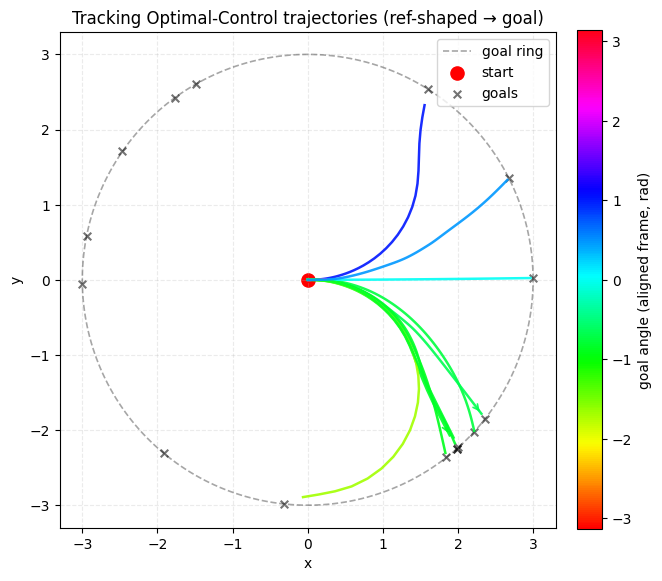

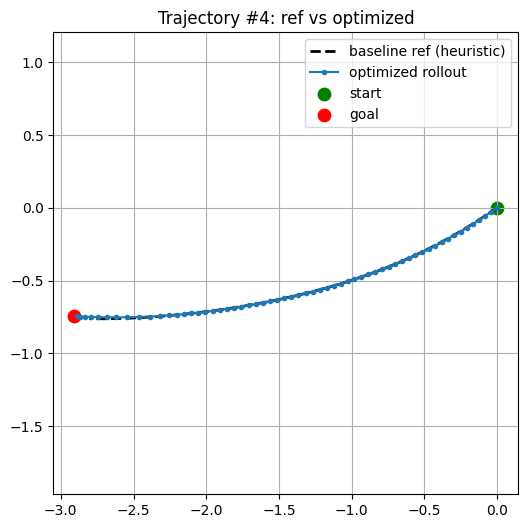

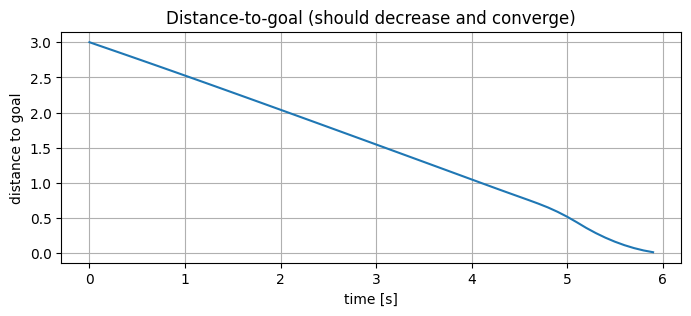

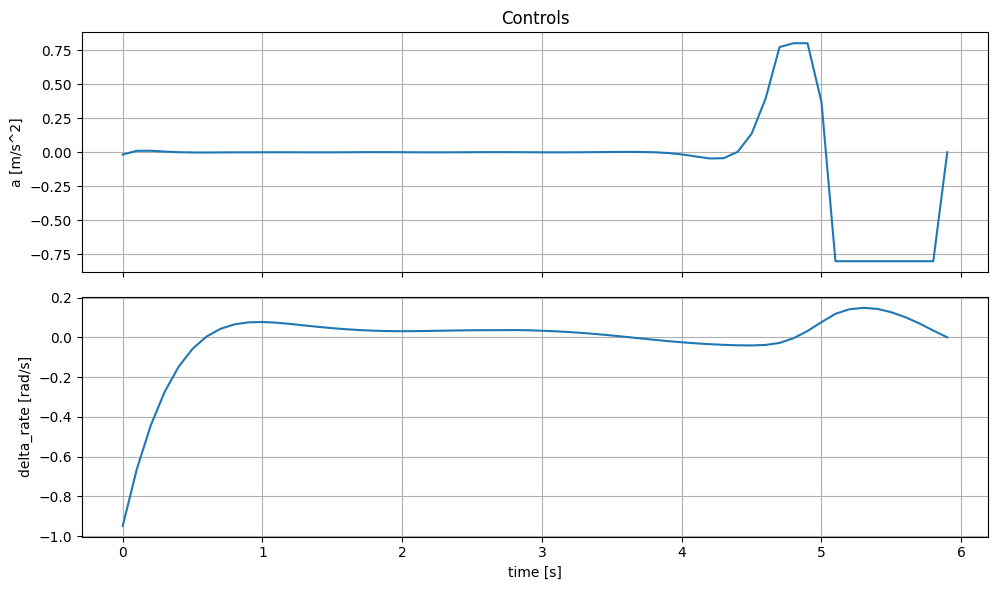

In [5]:
import numpy as np
from scipy.optimize import minimize
import os
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# =========================
# Utils
# =========================
def _wrap_to_pi(a):
    return (a + np.pi) % (2*np.pi) - np.pi

# =========================
# 1) Vehicle rollout (bicycle)
# =========================
def simulate_vehicle_bicycle(
    x0,            # [x,y,theta,v,delta]
    u_seq,         # (T-1,2) = [a, delta_rate]
    dt,
    L,    # 轴距
    delta_max,
    v_min=0.0, # 不允许倒车 负速度
):
    u_seq = np.asarray(u_seq, dtype=np.float64)  # 转换成 numpy
    Tm1 = u_seq.shape[0]
    T = Tm1 + 1

    states = np.zeros((T, 5), dtype=np.float64)
    states[0] = np.asarray(x0, dtype=np.float64)

    for k in range(Tm1):
        x, y, th, v, delta = states[k]
        a, delta_rate = u_seq[k]

        # steering integration
        delta_next = delta + dt * delta_rate
        delta_next = np.clip(delta_next, -delta_max, delta_max)

        # speed integration
        v_next = v + dt * a
        v_next = max(v_min, v_next)

        # kinematic bicycle
        th_next = _wrap_to_pi(th + dt * (v / L) * np.tan(delta))
        x_next = x + dt * v * np.cos(th)
        y_next = y + dt * v * np.sin(th)

        states[k+1] = [x_next, y_next, th_next, v_next, delta_next]

    return states

# =========================
# 2) Baseline reference (the "goal-attracted" curve you like)
# =========================
def make_baseline_reference_bicycle(
    start_xy, theta0, goal_xy,
    T, dt, L, delta_max, delta_rate_max,
    v_ref,
    turn_scale=3.0,
    k_theta=3.0,
):
    x, y = float(start_xy[0]), float(start_xy[1])
    theta = float(theta0)
    delta = 0.0

    dir_init = np.array([np.cos(theta0), np.sin(theta0)], dtype=np.float64)
    ref_xy = np.zeros((T, 2), dtype=np.float64)
    ref_xy[0] = [x, y]

    for t in range(1, T):
        vec_goal = goal_xy - np.array([x, y], dtype=np.float64)
        dist = float(np.linalg.norm(vec_goal) + 1e-8)
        dir_goal = vec_goal / dist

        w = np.exp(-t / (T / turn_scale))
        dir_mix = w * dir_init + (1.0 - w) * dir_goal
        dir_mix /= np.linalg.norm(dir_mix) + 1e-8

        theta_ref = float(np.arctan2(dir_mix[1], dir_mix[0]))

        # heading P-control -> yaw_rate_des -> delta*
        e_theta = _wrap_to_pi(theta_ref - theta)
        yaw_rate_des = k_theta * e_theta
        delta_star = np.arctan2(L * yaw_rate_des, max(v_ref, 1e-6))
        delta_star = np.clip(delta_star, -delta_max, delta_max)

        # delta rate limit
        max_delta_step = delta_rate_max * dt
        delta += np.clip(delta_star - delta, -max_delta_step, max_delta_step)
        delta = np.clip(delta, -delta_max, delta_max)

        # bicycle rollout with v_ref
        x += v_ref * np.cos(theta) * dt
        y += v_ref * np.sin(theta) * dt
        theta = _wrap_to_pi(theta + (v_ref / L) * np.tan(delta) * dt)

        ref_xy[t] = [x, y]

    return ref_xy

# =========================
# 3) Tracking optimal control cost
# =========================
def make_cost_function_tracking(
    dt, L, delta_max,
    ref_xy, goal_xy,
    tau_track=15.0,
    w_track=80.0,
    w_goal_terminal=1200.0,
    w_v_terminal=120.0,
    w_u=0.02,
    w_delta_stage=0.1,
):
    T = ref_xy.shape[0]
    ts = np.arange(T, dtype=np.float64)
    wt = np.exp(-ts / tau_track)  # early strong, later weak

    def cost(u_flat, x0, theta_goal_unused, control_steps):
        u_seq = u_flat.reshape((control_steps, 2))
        states = simulate_vehicle_bicycle(
            x0=x0, u_seq=u_seq, dt=dt, L=L, delta_max=delta_max, v_min=0.0
        )

        x = states[:, 0]
        y = states[:, 1]
        v = states[:, 3]
        delta = states[:, 4]

        # tracking (position)
        ex = x - ref_xy[:, 0]
        ey = y - ref_xy[:, 1]
        track_err2 = ex*ex + ey*ey
        J_track = w_track * np.sum(wt * track_err2)

        # terminal goal + stop
        xf, yf, _, vf, _ = states[-1]
        pos_goal = (xf - goal_xy[0])**2 + (yf - goal_xy[1])**2
        J_terminal = w_goal_terminal * pos_goal + w_v_terminal * (vf*vf)

        # control effort + steering magnitude
        J_u = w_u * np.sum(u_seq*u_seq)
        J_delta = w_delta_stage * np.sum(delta*delta)

        return J_track + J_terminal + J_u + J_delta

    return cost

# =========================
# 4) Dataset generation (tracking OC)
# =========================
def make_center_to_ring_dataset_tracking_oc(
    N=100,
    T=60,
    start=(0.0, 0.0),
    goal_center=(0.0, 0.0),
    radius=3.0,
    seed=42,
    save_filename="car_ring_track_oc_dataset.npy",
    LOAD_SAVED_DATA=False,

    # vehicle
    dt=0.1,
    L=0.8,
    delta_max=np.deg2rad(30.0),
    a_max=0.8,
    delta_rate_max=np.deg2rad(120.0),

    # initial speed range in x0 (important)
    v0_min=0.15,
    v0_max=0.6,

    # baseline ref params
    turn_scale=3.0,
    k_theta=3.0,

    # tracking cost params
    tau_track_ratio=0.8,   # tau_track = ratio*T
    w_track=160,
    w_goal_terminal=3500,
    w_v_terminal=120.0,
    w_u=0.02,
    w_delta_stage=0.1,

    # optimizer
    maxiter=600,
):
    rng = np.random.default_rng(seed)

    if LOAD_SAVED_DATA and os.path.exists(save_filename):
        print("Loading:", save_filename)
        return np.load(save_filename, allow_pickle=True).item()

    # goals on ring
    gc = np.array(goal_center, dtype=np.float64)
    phi = np.linspace(-np.pi, np.pi, N, endpoint=False).astype(np.float64)
    goals = gc + radius * np.stack([np.cos(phi), np.sin(phi)], axis=1)

    # initial headings
    thetas0 = rng.uniform(-np.pi, np.pi, size=N).astype(np.float64)

    control_steps = T - 1
    bounds = []
    for _ in range(control_steps):
        bounds.append((-a_max, a_max))
        bounds.append((-delta_rate_max, delta_rate_max))

    traj_xy = np.zeros((N, 2, T), dtype=np.float64)
    states_all = np.zeros((N, T, 5), dtype=np.float64)
    controls_all = np.zeros((N, T, 2), dtype=np.float64)
    refs_all = np.zeros((N, T, 2), dtype=np.float64)

    x0_global, y0_global = float(start[0]), float(start[1])

    print("Generating tracking optimal-control ring dataset ...")
    for i in range(N):
        goal = goals[i]
        theta0 = float(thetas0[i])

        # initial state
        v0_i = float(rng.uniform(float(v0_min), float(v0_max)))
        x0 = np.array([x0_global, y0_global, theta0, v0_i, 0.0], dtype=np.float64)

        # baseline reference speed: use the same v0_i
        v_ref = float(x0[3])

        # baseline ref trajectory (the shape you like)
        ref_xy = make_baseline_reference_bicycle(
            start_xy=np.array([x0_global, y0_global], dtype=np.float64),
            theta0=theta0,
            goal_xy=goal,
            T=T,
            dt=dt,
            L=L,
            delta_max=delta_max,
            delta_rate_max=delta_rate_max,
            v_ref=v_ref,
            turn_scale=turn_scale,
            k_theta=k_theta,
        )
        refs_all[i] = ref_xy

        # tracking cost for this trajectory
        cost_fn = make_cost_function_tracking(
            dt=dt, L=L, delta_max=delta_max,
            ref_xy=ref_xy, goal_xy=goal,
            tau_track=tau_track_ratio * T,
            w_track=w_track,
            w_goal_terminal=w_goal_terminal,
            w_v_terminal=w_v_terminal,
            w_u=w_u,
            w_delta_stage=w_delta_stage,
        )

        # initial guess
        u0 = np.zeros(control_steps * 2, dtype=np.float64)

        # optimize
        res = minimize(
            fun=cost_fn,
            x0=u0,
            args=(x0, 0.0, control_steps),  # theta_goal unused
            method="SLSQP",
            bounds=bounds,
            options={"maxiter": maxiter, "ftol": 1e-6, "disp": False},
        )

        u_opt = res.x.reshape((control_steps, 2))
        states = simulate_vehicle_bicycle(
            x0=x0, u_seq=u_opt, dt=dt, L=L, delta_max=delta_max, v_min=0.0
        )

        states_all[i] = states
        traj_xy[i, 0, :] = states[:, 0]
        traj_xy[i, 1, :] = states[:, 1]

        controls_padded = np.zeros((T, 2), dtype=np.float64)
        controls_padded[:-1] = u_opt
        controls_all[i] = controls_padded

        if (i + 1) % max(1, N // 10) == 0:
            print(f"{(i+1)/N*100:.0f}% ({i+1}/{N}) done. last success={res.success}")

    data = {
        "traj_xy": traj_xy.astype(np.float32),
        "states": states_all.astype(np.float32),
        "controls": controls_all.astype(np.float32),
        "refs_xy": refs_all.astype(np.float32),
        "goals": goals.astype(np.float32),
        "theta0": thetas0.astype(np.float32),
        "params": {
            "dt": float(dt), "L": float(L), "delta_max": float(delta_max),
            "a_max": float(a_max), "delta_rate_max": float(delta_rate_max),
            "T": int(T), "N": int(N), "radius": float(radius),
            "start": start, "goal_center": goal_center,
            "v0_min": float(v0_min),
            "v0_max": float(v0_max),
            "turn_scale": float(turn_scale), "k_theta": float(k_theta),
            "tau_track_ratio": float(tau_track_ratio),
            "w_track": float(w_track),
            "w_goal_terminal": float(w_goal_terminal),
            "w_v_terminal": float(w_v_terminal),
            "w_u": float(w_u),
            "w_delta_stage": float(w_delta_stage),
            "save_filename": save_filename,
        }
    }

    np.save(save_filename, data, allow_pickle=True)
    print("Saved:", save_filename)
    return data

# =========================
# 5) Plotting cells
# =========================
def plot_all_trajs_timecolor(
    traj_xy,
    goals,
    title,
    theta0=None,
    n_show=16,
    arrow_every=4,
    show_circle=True,
    align_start_to_right=True,
):
    """Dataset overview plot in the style you sketched.

    Key visualization idea:
    - translate start -> origin
    - (optionally) rotate each trajectory so its initial heading points to +x (right)
      so the plot shows: "go straight right first, then turn by different angles".

    Notes:
    - This is ONLY a plotting transform. Simulation/control logic is unchanged.

    Args:
      traj_xy: (N,2,T)
      goals:   (N,2)
      theta0:  (N,) optional. If given and align_start_to_right=True, we rotate by -theta0.
      n_show:  how many trajectories to display (spread over angles)
    """
    traj_xy = np.asarray(traj_xy, dtype=np.float64)
    goals = np.asarray(goals, dtype=np.float64)

    N, _, T = traj_xy.shape

    def _rot2(a):
        ca, sa = float(np.cos(a)), float(np.sin(a))
        return np.array([[ca, -sa], [sa, ca]], dtype=np.float64)

    # choose an ordering angle (for selecting a representative subset)
    if theta0 is not None:
        base_angles = np.asarray(theta0, dtype=np.float64)
    else:
        base_angles = np.arctan2(goals[:, 1], goals[:, 0]).astype(np.float64)

    n_show = int(min(max(1, n_show), N))
    order = np.argsort(base_angles)
    pick = order[np.linspace(0, N - 1, n_show).astype(int)]

    fig, ax = plt.subplots(figsize=(7, 7))

    # dashed ring (goal radius)
    if show_circle:
        r = float(np.mean(np.linalg.norm(goals, axis=1)))
        tt = np.linspace(0.0, 2 * np.pi, 256)
        ax.plot(r * np.cos(tt), r * np.sin(tt), "k--", alpha=0.35, linewidth=1.2, label="goal ring")

    # start point is always origin after alignment
    ax.scatter([0.0], [0.0], s=90, c="red", label="start")

    cmap = plt.cm.hsv
    norm = Normalize(vmin=-np.pi, vmax=np.pi)

    # If theta0 is NOT provided, DO NOT infer per-trajectory heading from the first segment.
    # That inference tends to rotate each trajectory so its goal points to +x,
    # collapsing the whole dataset to the right (exactly the issue you saw).
    if align_start_to_right and theta0 is None:
        print("[plot_all_trajs_timecolor] WARNING: theta0 is None; alignment disabled to avoid collapsing the plot.")

    # plot trajectories (aligned frame)
    aligned_goals = []
    for k, i in enumerate(pick):
        xy = traj_xy[i].T  # (T,2)
        start = xy[0].copy()
        goal = goals[i].copy()

        # translate
        xy0 = xy - start[None, :]
        g0 = goal - start

        # rotate so initial heading is +x (only if theta0 is provided)
        if align_start_to_right and (theta0 is not None):
            a = float(theta0[i])
            R = _rot2(-a)
            xy0 = (R @ xy0.T).T
            g0 = (R @ g0.reshape(2, 1)).reshape(2)

        aligned_goals.append(g0.copy())

        # color by goal direction (after alignment)
        ang = float(np.arctan2(g0[1], g0[0]))
        c = cmap(norm(ang))

        ax.plot(xy0[:, 0], xy0[:, 1], color=c, alpha=0.9, linewidth=1.8)

        # arrow head occasionally
        if arrow_every > 0 and (k % int(arrow_every) == 0) and T >= 2:
            ax.annotate(
                "",
                xy=(float(xy0[-1, 0]), float(xy0[-1, 1])),
                xytext=(float(xy0[-2, 0]), float(xy0[-2, 1])),
                arrowprops=dict(arrowstyle="->", color=c, lw=1.2, alpha=0.9),
            )

    # show ALL goals (aligned in the same frame) for context
    aligned_goals = np.asarray(aligned_goals, dtype=np.float64)
    ax.scatter(aligned_goals[:, 0], aligned_goals[:, 1], s=30, marker="x", c="black", alpha=0.55, label="goals")

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)
    ax.grid(True, linestyle="--", alpha=0.25)

    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("goal angle (aligned frame, rad)")

    ax.legend(loc="best")
    plt.show()


def plot_one_compare(data, idx=None):
    traj_xy = data["traj_xy"]
    refs_xy = data["refs_xy"]
    goals = data["goals"]
    controls = data["controls"]
    dt = data["params"]["dt"]

    N, _, T = traj_xy.shape
    if idx is None:
        idx = np.random.randint(N)

    xy = traj_xy[idx].T    # (T,2)
    ref = refs_xy[idx]     # (T,2)
    goal = goals[idx]
    u = controls[idx]      # (T,2)

    # 1) XY compare
    plt.figure(figsize=(6,6))
    plt.plot(ref[:,0], ref[:,1], "k--", linewidth=2, label="baseline ref (heuristic)")
    plt.plot(xy[:,0], xy[:,1], "-o", markersize=3, label="optimized rollout")
    plt.scatter(xy[0,0], xy[0,1], c="green", s=80, label="start")
    plt.scatter(goal[0], goal[1], c="red", s=80, label="goal")
    plt.axis("equal")
    plt.grid(True)
    plt.title(f"Trajectory #{idx}: ref vs optimized")
    plt.legend()
    plt.show()

    # 2) distance to goal over time
    dist = np.linalg.norm(xy - goal[None,:], axis=1)
    plt.figure(figsize=(8,3))
    plt.plot(np.arange(T)*dt, dist)
    plt.grid(True)
    plt.xlabel("time [s]")
    plt.ylabel("distance to goal")
    plt.title("Distance-to-goal (should decrease and converge)")
    plt.show()

    # 3) controls
    t = np.arange(T)*dt
    fig, axs = plt.subplots(2, 1, figsize=(10,6), sharex=True)
    axs[0].plot(t, u[:,0])
    axs[0].set_ylabel("a [m/s^2]")
    axs[0].grid(True)
    axs[0].set_title("Controls")

    axs[1].plot(t, u[:,1])
    axs[1].set_ylabel("delta_rate [rad/s]")
    axs[1].set_xlabel("time [s]")
    axs[1].grid(True)
    plt.tight_layout()
    plt.show()

# =========================
# RUN (generate + plot)
# =========================
save_filename = "car_ring_track_oc_dataset_v1_v0rand.npy"   # ✅ 你要的“新文件名”就在这里改

data = make_center_to_ring_dataset_tracking_oc(
    N=100,              # 你可以改大一点
    T=60,               # 你可以改大一点
    radius=3.0,
    save_filename=save_filename,
    LOAD_SAVED_DATA=False,   # True 就直接读文件不重新生成
    v0_min=0.15,             # 初始速度范围（影响整体曲率/是否冲过头）
    v0_max=0.6,
)

# 总览图：只画优化后的轨迹
plot_all_trajs_timecolor(
    data["traj_xy"],
    data["goals"],
    theta0=data["theta0"],
    align_start_to_right=True,
    title="Tracking Optimal-Control trajectories (ref-shaped → goal)"
)

# 单条对比：会出现黑色虚线（baseline ref），这是故意的
plot_one_compare(data, idx=None)


In [6]:
# ===============================================================
# NEW CELL: Virtual obstacle canonicalization (dataset augmentation)
#
# Goal: train a model that generalizes to different obstacle placements by canonicalizing geometry.
#   - For each trajectory: sample a VIRTUAL obstacle center near the start-goal line + lateral offset
#   - Canonical frame:
#       * translate start -> origin
#       * rotate so goal lies on +x axis
#       * reflect if needed so obstacle is always on +y ("left")
#   - Apply the same transform to trajectory states + controls.
#   - New dataset: (u_seq, cond) where cond includes (goal_dist, obs_x, obs_y, ...)
#
# Notes on reflection:
#   - reflect across x-axis => y -> -y, theta -> -theta, delta -> -delta, delta_rate -> -delta_rate
#   - acceleration a unchanged
# ===============================================================

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

if "data" not in globals() or (not isinstance(data, dict)) or ("params" not in data):
    raise RuntimeError("Need `data['params']` in globals to get dt/L/etc.")

# Always use current data
states_np = np.asarray(data["states"], dtype=np.float32)
controls_np = np.asarray(data["controls"], dtype=np.float32)


def _wrap_pi(a: float) -> float:
    return float((a + np.pi) % (2 * np.pi) - np.pi)


def _rot2(a: float) -> np.ndarray:
    ca, sa = float(np.cos(a)), float(np.sin(a))
    return np.array([[ca, -sa], [sa, ca]], dtype=np.float64)


def sample_virtual_obstacle(start_xy, goal_xy, *, alpha_range=(0.25, 0.75), offset_range=(0.15, 0.55), rng=None):
    """Sample obstacle near start-goal line with lateral offset."""
    if rng is None:
        rng = np.random.default_rng()

    s = np.asarray(start_xy, dtype=np.float64).reshape(2)
    g = np.asarray(goal_xy, dtype=np.float64).reshape(2)
    d = g - s
    dn = float(np.linalg.norm(d) + 1e-12)
    u = d / dn
    n = np.array([-u[1], u[0]], dtype=np.float64)  # left normal

    alpha = float(rng.uniform(alpha_range[0], alpha_range[1]))
    off = float(rng.uniform(offset_range[0], offset_range[1]))

    c = s + alpha * d + off * n
    return c


def canonicalize_episode(states_T5, controls_T2, goal_xy, obs_xy):
    """Return canonicalized (states, controls, cond, meta).

    states_T5: (T,5) [x,y,theta,v,delta]
    controls_T2: (T,2) padded, last row 0; we use u_seq=controls[:-1]
    goal_xy: (2,)
    obs_xy: (2,)

    Outputs:
      states_can: (T,5)
      controls_can: (T,2)
      cond: (cond_dim,)  -> [goal_dist, obs_x, obs_y, v0, cos(theta0_can), sin(theta0_can), delta0_can]
      meta: dict with transform params for inverse mapping
    """

    st = np.asarray(states_T5, dtype=np.float64)
    u_pad = np.asarray(controls_T2, dtype=np.float64)
    T = st.shape[0]

    s0 = st[0]
    start_xy = s0[:2]

    g = np.asarray(goal_xy, dtype=np.float64).reshape(2)
    obs = np.asarray(obs_xy, dtype=np.float64).reshape(2)

    # translate so start at origin
    st_xy = st[:, :2] - start_xy[None, :]
    g0 = g - start_xy
    o0 = obs - start_xy

    # rotate so goal lies on +x
    phi = float(np.arctan2(g0[1], g0[0]))
    R = _rot2(-phi)
    st_xy = (R @ st_xy.T).T
    g_can = (R @ g0.reshape(2, 1)).reshape(2)
    o_can = (R @ o0.reshape(2, 1)).reshape(2)

    reflect = False
    if float(o_can[1]) < 0.0:
        reflect = True
        st_xy[:, 1] *= -1.0
        o_can[1] *= -1.0
        g_can[1] *= -1.0

    # angles
    th = np.array([_wrap_pi(float(a) - phi) for a in st[:, 2]], dtype=np.float64)
    delta = np.asarray(st[:, 4], dtype=np.float64)

    if reflect:
        th = -th
        delta = -delta
        u_pad = u_pad.copy()
        u_pad[:-1, 1] = -u_pad[:-1, 1]  # delta_rate flip

    # assemble canonical states
    st_can = st.copy()
    st_can[:, 0] = st_xy[:, 0]
    st_can[:, 1] = st_xy[:, 1]
    st_can[:, 2] = th
    st_can[:, 4] = delta

    goal_dist = float(np.linalg.norm(g0))
    v0 = float(st[0, 3])
    theta0_can = float(st_can[0, 2])
    delta0_can = float(st_can[0, 4])

    cond = np.array(
        [
            goal_dist,
            float(o_can[0]),
            float(o_can[1]),
            v0,
            float(np.cos(theta0_can)),
            float(np.sin(theta0_can)),
            delta0_can,
        ],
        dtype=np.float64,
    )

    meta = {
        "start_xy": start_xy,
        "phi": phi,
        "reflect": reflect,
        "goal_can": g_can,
        "obs_can": o_can,
    }

    return st_can, u_pad, cond, meta


def decanonicalize_xy(xy_can, meta):
    """Inverse transform from canonical frame back to world XY.

    xy_can: (...,2)
    meta: {start_xy, phi, reflect}
    """
    xy = np.asarray(xy_can, dtype=np.float64)
    xy_flat = xy.reshape(-1, 2).copy()

    if bool(meta.get("reflect", False)):
        xy_flat[:, 1] *= -1.0

    R = _rot2(float(meta["phi"]))  # inverse rotation
    xy_flat = (R @ xy_flat.T).T
    xy_flat = xy_flat + np.asarray(meta["start_xy"], dtype=np.float64).reshape(1, 2)

    return xy_flat.reshape(xy.shape)


class CanonicalVirtualObstacleControlDataset(Dataset):
    def __init__(
        self,
        states: np.ndarray,
        controls: np.ndarray,
        goals: np.ndarray,
        *,
        n_virtual: int = 1,
        alpha_range=(0.25, 0.75),
        offset_range=(0.15, 0.55),
        seed: int = 0,
        return_meta: bool = False,
    ):
        self.states = np.asarray(states, dtype=np.float64)
        self.controls = np.asarray(controls, dtype=np.float64)
        self.goals = np.asarray(goals, dtype=np.float64)
        self.n_virtual = int(n_virtual)
        self.alpha_range = alpha_range
        self.offset_range = offset_range
        self.rng = np.random.default_rng(int(seed))
        self.return_meta = bool(return_meta)

        assert self.states.ndim == 3 and self.states.shape[2] == 5
        assert self.controls.ndim == 3 and self.controls.shape[2] == 2
        assert self.goals.ndim == 2 and self.goals.shape[1] == 2

    def __len__(self):
        return int(self.states.shape[0]) * int(self.n_virtual)

    def __getitem__(self, idx):
        # map to original episode index + augmentation index
        epi = int(idx // self.n_virtual)

        st = self.states[epi]      # (T,5)
        u = self.controls[epi]     # (T,2)
        g = self.goals[epi]        # (2,)

        # sample virtual obstacle
        start_xy = st[0, :2]
        obs = sample_virtual_obstacle(
            start_xy,
            g,
            alpha_range=self.alpha_range,
            offset_range=self.offset_range,
            rng=self.rng,
        )

        st_can, u_can, cond, meta = canonicalize_episode(st, u, g, obs)

        # u_seq is first T-1 steps, channel-first for Conv1d
        u_seq = u_can[:-1].T.astype(np.float32)     # (2, T-1)
        cond = cond.astype(np.float32)              # (7,)

        if self.return_meta:
            return torch.from_numpy(u_seq), torch.from_numpy(cond), meta

        return torch.from_numpy(u_seq), torch.from_numpy(cond)


# -------------------------
# Build canonicalized dataset
# -------------------------
goals_np = np.asarray(data["goals"], dtype=np.float64)

canon_ds = CanonicalVirtualObstacleControlDataset(
    states_np,
    controls_np,
    goals_np,
    n_virtual=4,
    alpha_range=(0.25, 0.75),
    offset_range=(0.15, 0.60),
    seed=123,
    return_meta=True,
)

canon_loader = DataLoader(canon_ds, batch_size=64, shuffle=True, drop_last=True)

u_ex, cond_ex, meta_ex = canon_ds[0]
print("Canonical dataset size:", len(canon_ds))
print("u_seq shape:", tuple(u_ex.shape), "cond shape:", tuple(cond_ex.shape))
print("cond = [goal_dist, obs_x, obs_y, v0, cos(theta0), sin(theta0), delta0] ->", cond_ex.numpy())
print("meta:", meta_ex)



Canonical dataset size: 400
u_seq shape: (2, 59) cond shape: (7,)
cond = [goal_dist, obs_x, obs_y, v0, cos(theta0), sin(theta0), delta0] -> [ 3.          1.7735277   0.17421946  0.5588613   0.14995252 -0.9886932
  0.        ]
meta: {'start_xy': array([0., 0.]), 'phi': -3.141592653589793, 'reflect': False, 'goal_can': array([ 3.00000000e+00, -1.04384352e-23]), 'obs_can': array([1.77352779, 0.17421946])}


In [7]:
# ===============================================================
# NEW CELL: Train a control-UNet on canonicalized virtual-obstacle data
#
# This produces `model_u_obs` which can be used at inference by:
#   - canonicalize current (state, goal, obstacle)
#   - sample u_seq in canonical
#   - un-canonicalize u_seq (only needs reflection sign flip of delta_rate)
# ===============================================================

import torch
import torch.nn as nn

if "canon_loader" not in globals():
    raise RuntimeError("Please run the virtual-obstacle canonicalization dataset cell first (it defines canon_loader).")

# Reuse SimpleUNet1D if defined, else error
if "SimpleUNet1D" not in globals():
    raise RuntimeError("SimpleUNet1D not found. Please run the Control-UNet definition cell first.")

# -------- model --------
COND_DIM_OBS = 7
model_u_obs = SimpleUNet1D(time_emb_dim=128, hidden_dim=128, cond_dim=COND_DIM_OBS).to(device)
optimizer_u_obs = torch.optim.Adam(model_u_obs.parameters(), lr=1e-3)

# -------- FM training pieces (reuse if available) --------
if "CondOTScheduler" not in globals() or "AffinePath" not in globals():
    raise RuntimeError("Need CondOTScheduler/AffinePath. Please run the FM components cell first.")

scheduler = CondOTScheduler()
path = AffinePath(scheduler)

# Training hyperparams
EPOCHS = 8
LOG_EVERY = 20

# Infer CTRL_T from loader once to keep shapes consistent
batch_ex = next(iter(canon_loader))
# Support dataset returning (u_seq, cond) or (u_seq, cond, meta)
u_ex, cond_ex = batch_ex[0], batch_ex[1]
CTRL_T = int(u_ex.shape[-1])  # T-1

model_u_obs.train()
step = 0
for ep in range(int(EPOCHS)):
    for batch in canon_loader:
        # Support dataset returning (u_seq, cond) or (u_seq, cond, meta)
        u_seq, cond = batch[0], batch[1]
        u_seq = u_seq.to(device)   # (B,2,T-1)
        cond = cond.to(device)     # (B,7)

        B = u_seq.shape[0]
        # sample endpoints
        x0 = torch.randn_like(u_seq) * 1.0
        x1 = u_seq

        # time
        t = torch.rand(B, device=device)
        ps = path.sample(x0, x1, t)
        x_t = ps.x_t
        dx_t = ps.dx_t

        v_pred = model_u_obs(x_t, t, cond=cond)
        loss = torch.mean((v_pred - dx_t) ** 2)

        optimizer_u_obs.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_u_obs.parameters(), 1.0)
        optimizer_u_obs.step()

        if step % int(LOG_EVERY) == 0:
            print(f"[train model_u_obs] ep={ep} step={step} loss={loss.item():.6f}")
        step += 1

print("✅ Trained `model_u_obs` (canonical virtual obstacle).")



[train model_u_obs] ep=0 step=0 loss=1.448007
[train model_u_obs] ep=3 step=20 loss=0.695468
[train model_u_obs] ep=6 step=40 loss=0.616778
✅ Trained `model_u_obs` (canonical virtual obstacle).


In [8]:
# ===============================================================
# Cell 1: 基础组件 - Mish, SinusoidalPosEmb, ResBlock1D
# ===============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

from fmtorch.models.simple1d_unet import Mish, SinusoidalPosEmb, ResBlock1D, SimpleUNet1D


In [ ]:
#没有canoliaztion的训练 作为baseline

# ========== Cell 2: Dataset + Model (cond=initial_state) + DataLoader (GENERATE CONTROLS u) ==========

import numpy as np
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# -------------------------
# Load saved dataset
# -------------------------
DATA_NPY = "car_ring_track_oc_dataset_v1_v0rand.npy"

if not os.path.exists(DATA_NPY):
    raise RuntimeError(f"Cannot find {DATA_NPY}. Please check your working directory.")

data = np.load(DATA_NPY, allow_pickle=True).item()

states_np   = np.asarray(data["states"], dtype=np.float32)    # (N, T, 5) [x,y,theta,v,delta]
controls_np = np.asarray(data["controls"], dtype=np.float32)  # (N, T, 2) padded, last row is 0
dt_data = float(data["params"]["dt"])
N, T, D = states_np.shape

print("Loaded dataset from", DATA_NPY)
print("states_np.shape   =", states_np.shape)
print("controls_np.shape =", controls_np.shape)
print("dt_data           =", dt_data)
print("T (states length) =", T, "=> control horizon =", T-1)

CTRL_T = T - 1   # 控制序列长度
print("CTRL_T =", CTRL_T)

# -------------------------
# Dataset: output (u_seq, cond_state)
# u_seq:  (2, CTRL_T) = [a, delta_rate]
# cond:   (cond_dim,) = initial state features
# -------------------------
class ControlSeqCondDataset(Dataset):
    def __init__(self, states: np.ndarray, controls: np.ndarray, cond_dim: int = 5):
        """
        states:   (N, T, 5)
        controls: (N, T, 2)  padded last one
        cond_dim: use first cond_dim dims of initial state as condition
                  cond_dim=5 -> [x0,y0,theta0,v0,delta0]
                  cond_dim=4 -> [x0,y0,theta0,v0]  (like your advisor)
        """
        assert states.ndim == 3 and states.shape[2] == 5
        assert controls.ndim == 3 and controls.shape[2] == 2
        assert states.shape[0] == controls.shape[0]
        assert states.shape[1] == controls.shape[1]
        self.states = states.astype(np.float32)
        self.controls = controls.astype(np.float32)
        self.cond_dim = int(cond_dim)

    def __len__(self):
        return self.states.shape[0]

    def __getitem__(self, idx):
        s = self.states[idx]        # (T,5)
        u = self.controls[idx]      # (T,2) padded

        # valid controls are first T-1 steps
        u_seq = u[:-1].T            # (2, T-1)  channel-first for Conv1d

        # condition = initial state (first cond_dim dims)
        s0 = s[0]                   # (5,)
        cond = s0[:self.cond_dim]   # (cond_dim,)

        return torch.from_numpy(u_seq), torch.from_numpy(cond)

cond_dim = 5  # 改成 4 就是导师那种 cond=[x,y,theta,v]
dataset_u = ControlSeqCondDataset(states_np, controls_np, cond_dim=cond_dim)
dataloader_u = DataLoader(dataset_u, batch_size=64, shuffle=True, drop_last=True)

print("Dataset size:", len(dataset_u))
u_ex, cond_ex = dataset_u[0]
print("Sample shapes: u_seq =", u_ex.shape, "cond =", cond_ex.shape)  # u_seq=(2,CTRL_T)


# -------------------------
# Model: SimpleUNet1D for control sequence
# input x: (B,2,CTRL_T) control sequence "x_t"
# output:  (B,2,CTRL_T) predicted velocity field v(x_t,t,cond)
# -------------------------
# SimpleUNet1D moved to fmtorch.models.unet (imported above)


# -------------------------
# Instantiate model & optimizer
# -------------------------
model_u = SimpleUNet1D(
    time_emb_dim=128,
    hidden_dim=128,
    cond_dim=cond_dim,   # 5 or 4
).to(device)

optimizer_u = torch.optim.Adam(model_u.parameters(), lr=1e-3)

print("✅ Control-UNet model_u & optimizer_u ready.")


Using device: cuda
Loaded dataset from car_ring_track_oc_dataset_v1_v0rand.npy
states_np.shape   = (100, 60, 5)
controls_np.shape = (100, 60, 2)
dt_data           = 0.1
T (states length) = 60 => control horizon = 59
CTRL_T = 59
Dataset size: 100
Sample shapes: u_seq = torch.Size([2, 59]) cond = torch.Size([5])
✅ Control-UNet model_u & optimizer_u ready.


In [ ]:
#model_u baseline
# ========== Cell 3: Flow Matching training for CONTROL sequences (u_seq) ==========

import torch
from tqdm.auto import tqdm

EPOCHS = 80
model_u.train()

for epoch in range(1, EPOCHS + 1):
    running = 0.0
    nb = 0

    pbar = tqdm(dataloader_u, desc=f"Epoch {epoch:03d}/{EPOCHS}", leave=False)
    for u_batch, cond_batch in pbar:
        # u_batch:   (B,2,CTRL_T)  true controls
        # cond_batch:(B,cond_dim)  initial state condition
        y = u_batch.to(device)
        cond = cond_batch.to(device)
        B = y.shape[0]

        # 1) t ~ U[0,1]
        t = torch.rand(B, device=device)

        # 2) z ~ N(0,I) (same shape as controls)
        z = torch.randn_like(y)

        # 3) x_t = (1-t) z + t y
        t_ = t.view(B, 1, 1)
        x_t = (1.0 - t_) * z + t_ * y

        # 4) v* = y - z
        v_target = (y - z)

        # 5) v_pred = model(x_t, t, cond)
        v_pred = model_u(x_t, t, cond=cond)

        # (optional) ensure same length if UNet cropped a little
        if v_pred.shape[-1] != v_target.shape[-1]:
            Lmin = min(v_pred.shape[-1], v_target.shape[-1])
            v_pred = v_pred[..., :Lmin]
            v_target = v_target[..., :Lmin]

        loss = ((v_pred - v_target) ** 2).mean()

        optimizer_u.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_u.parameters(), 1.0)
        optimizer_u.step()

        running += loss.item()
        nb += 1
        pbar.set_postfix(loss=f"{loss.item():.5f}")

    print(f"[Epoch {epoch:03d}] FM(control) loss = {running / max(nb,1):.6f}")

print("✅ Control FM training finished.")


d:\projects\lab2025\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[Epoch 001] FM(control) loss = 1.401335


[Epoch 002] FM(control) loss = 3.370785


[Epoch 003] FM(control) loss = 1.059749


[Epoch 004] FM(control) loss = 1.331413


...

[Epoch 076] FM(control) loss = 0.417085


[Epoch 077] FM(control) loss = 0.489429


[Epoch 078] FM(control) loss = 0.471197


[Epoch 079] FM(control) loss = 0.517537


[Epoch 080] FM(control) loss = 0.464673
✅ Control FM training finished.


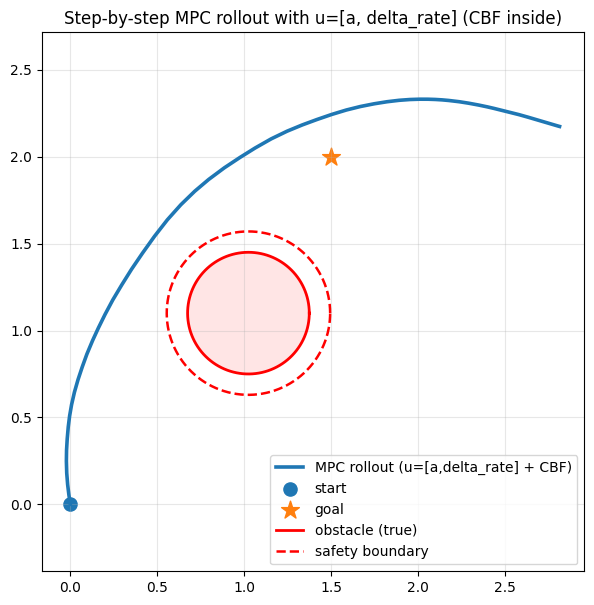

In [9]:
# ===============================================================
# NEW CELL: MPC rollout + static circular obstacles (CBF inside ODE rollout)
#   - Receding horizon: simulate H-step lookahead, execute only 1 step
#   - Obstacle avoidance: uses your existing CBF projection in world frame
#   - Works with multiple static circle obstacles
# ===============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import math

# -------------------------
# MPC rollout (bicycle) with trained control input
#   u = [a, delta_rate]
#   a: longitudinal acceleration (m/s^2)
#   delta_rate: steering rate (rad/s)
# -------------------------

def rollout_mpc(x0, U_opt, T, L, N, delta0=0.0, delta_max=None, v_min=0.0, v_max=None):
    """Rollout for kinematic bicycle with trained control input.

    x = [x, y, theta, v]  (or [x, y, theta, v, delta])
    U_opt[k] = [a, delta_rate]
    """
    x0 = np.asarray(x0, dtype=np.float64).reshape(-1)
    if x0.shape[0] >= 5:
        x = x0[:4].copy()
        delta = float(x0[4])
    else:
        x = x0[:4].copy()
        delta = float(delta0)

    traj = [np.array([x[0], x[1], x[2], x[3], delta], dtype=np.float64)]

    for k in range(int(N)):
        a, delta_rate = U_opt[k]

        delta = float(delta + float(T) * float(delta_rate))
        if delta_max is not None:
            delta = float(np.clip(delta, -float(delta_max), float(delta_max)))

        v = float(x[3] + float(T) * float(a))
        if v_max is not None:
            v = min(float(v_max), v)
        v = max(float(v_min), v)

        th = float((x[2] + float(T) * (v / float(L)) * math.tan(delta) + math.pi) % (2 * math.pi) - math.pi)
        x_next = np.array(
            [
                x[0] + float(T) * v * math.cos(th),
                x[1] + float(T) * v * math.sin(th),
                th,
                v,
            ],
            dtype=np.float64,
        )
        x = x_next
        traj.append(np.array([x[0], x[1], x[2], x[3], delta], dtype=np.float64))

    return np.asarray(traj, dtype=np.float64)

# -------------------------
# 0) Make this cell robust to execution order
#   - cbf_project_velocity_world calls `ellipse_h_grad_batch`
#   - if you haven't run the earlier definition cell, define a fallback here
# -------------------------
if "ellipse_h_grad_batch" not in globals():
    def ellipse_h_grad_batch(x_world_2N: torch.Tensor, ellipse: dict):
        """Fallback: ellipse h(x)=(a*(x-cx))^2+(b*(y-cy))^2-1 and grad in world frame.

        x_world_2N: (2,N) torch or np
        ellipse: {"center": np.array([cx,cy]), "a": a, "b": b}
        returns: h_e (N,), grad_w (N,2)
        """
        if not torch.is_tensor(x_world_2N):
            x_world_2N = torch.as_tensor(x_world_2N, dtype=torch.float32)

        center = ellipse["center"]
        if not torch.is_tensor(center):
            center = torch.as_tensor(center, dtype=x_world_2N.dtype, device=x_world_2N.device)

        if "a" in ellipse or "b" in ellipse:
            a = float(ellipse.get("a", 1.0))
            b = float(ellipse.get("b", 1.0))
        elif "radius" in ellipse:
            r = float(ellipse["radius"])
            a = 1.0 / max(r, 1e-9)
            b = a
        else:
            raise KeyError("ellipse must have keys {'center','a','b'} or {'center','radius'}")

        x_N2 = x_world_2N.transpose(0, 1)          # (N,2)
        delta = x_N2 - center.view(1, 2)           # (N,2)
        ax = float(a) * delta[:, 0]
        by = float(b) * delta[:, 1]
        h_e = ax * ax + by * by - 1.0             # (N,)
        grad_w = torch.stack([
            2.0 * (float(a) ** 2) * delta[:, 0],
            2.0 * (float(b) ** 2) * delta[:, 1],
        ], dim=1)
        return h_e, grad_w


# -------------------------
# 1) Get a single-step CBF projector (fallback if step-wrapper not defined)
# -------------------------
if "cbf_project_velocity_step" in globals():
    _cbf_step = cbf_project_velocity_step
else:
    @torch.no_grad()
    def _cbf_step(
        x_now_2: torch.Tensor,
        v_nom_2: torch.Tensor,
        ellipses,
        *,
        extra_margin: float = 0.12,
        max_corr_norm: float = 10.0,
        gamma_min: float = 6.0,
        w_p: float = 0.0,
        press_k: float = 1.0,
        press_n: float = 2.0,
    ) -> torch.Tensor:
        # Expand to (1,2,1) so we can reuse cbf_project_velocity_world
        x_traj = x_now_2.view(1, 2, 1)
        v_traj = v_nom_2.view(1, 2, 1)
        v_safe = cbf_project_velocity_world(
            x_traj,
            v_traj,
            ellipses=ellipses,
            extra_margin=float(extra_margin),
            max_corr_norm=float(max_corr_norm),
            passes=5,
            other_agent_traj=None,
            agent_safe_radius=0.5,
            gamma_min=float(gamma_min),
            w_p=float(w_p),
            press_k=float(press_k),
            press_n=float(press_n),
        )
        return v_safe.squeeze(0).squeeze(-1)  # (2,)


def _circle_list_to_ellipses(circles):
    """circles: list of dicts {center:(cx,cy), radius:R} OR tuples (cx,cy,R)."""
    ell = []
    for c in circles:
        if isinstance(c, dict):
            center = np.asarray(c["center"], dtype=np.float64).reshape(2)
            radius = float(c["radius"])
        else:
            cx, cy, r = c
            center = np.asarray([cx, cy], dtype=np.float64)
            radius = float(r)
        ell.append({"center": center, "radius": radius})
    return ell


def mpc_rollout_ode_with_cbf_circles(
    x0_state,
    goal_xy,
    *,
    circles,
    dt=0.02,
    L=0.8,
    a_max=1.0,
    delta_rate_max=np.deg2rad(120.0),
    delta_max=np.deg2rad(30.0),
    v_min=0.0,
    v_max=1.4,
    max_total_steps=400,
    goal_tol=0.15,
    # MPC lookahead
    H=12,
    K=24,
    # CBF knobs (safety boundary = R + safety_margin)
    safety_margin=0.12,
    gamma_min=6.0,
    max_corr_norm=10.0,
    device="cpu",
    # costs
    w_goal=10.0,
    w_clear=0.25,
    w_u=0.02,
):
    """Receding-horizon MPC with control u=[a, delta_rate]; CBF applied to XY velocity."""

    x0_state = np.asarray(x0_state, dtype=np.float64).reshape(-1)
    if x0_state.shape[0] >= 5:
        x, y, th, v, delta = [float(z) for z in x0_state[:5]]
    else:
        x, y, th, v = [float(z) for z in x0_state[:4]]
        delta = 0.0

    g = np.asarray(goal_xy, dtype=np.float64).reshape(2)

    # represent circles as ellipses for the existing CBF code
    ellipses_true = _circle_list_to_ellipses(circles)

    # We enforce safety by inflating via CBF's extra_margin
    extra_margin = float(safety_margin)

    dev = torch.device(device)

    xs = [np.array([x, y, th, v, delta], dtype=np.float64)]

    def clearance_penalty(xy):
        # soft penalty encourages wider clearance even if CBF keeps it safe
        eps = 1e-6
        pen = 0.0
        for e in ellipses_true:
            c = np.asarray(e["center"], dtype=np.float64).reshape(2)
            R = float(e["radius"]) + float(safety_margin)
            d2 = float(np.sum((xy - c) ** 2))
            h = d2 - R * R
            if h < 0.0:
                return 1e6  # should not happen if CBF works; keep as hard guard
            pen += 1.0 / (h + eps)
        return float(pen)

    def _step_with_cbf(state5, u):
        x, y, th, v, delta = [float(z) for z in state5]
        a, delta_rate = float(u[0]), float(u[1])

        delta = float(np.clip(delta + float(dt) * delta_rate, -float(delta_max), float(delta_max)))
        v = float(np.clip(v + float(dt) * a, float(v_min), float(v_max)))
        th = float((th + float(dt) * (v / float(L)) * math.tan(delta) + math.pi) % (2 * math.pi) - math.pi)

        v_nom_xy = np.array([v * math.cos(th), v * math.sin(th)], dtype=np.float64)
        x_now_2 = torch.tensor([x, y], dtype=torch.float32, device=dev)
        v_nom_2 = torch.tensor(v_nom_xy, dtype=torch.float32, device=dev)

        v_safe_2 = _cbf_step(
            x_now_2,
            v_nom_2,
            ellipses_true,
            extra_margin=float(extra_margin),
            max_corr_norm=float(max_corr_norm),
            gamma_min=float(gamma_min),
        )
        v_safe = v_safe_2.detach().cpu().numpy().astype(np.float64)

        x = float(x + float(dt) * v_safe[0])
        y = float(y + float(dt) * v_safe[1])
        return np.array([x, y, th, v, delta], dtype=np.float64)

    for step in range(int(max_total_steps)):
        dist = float(np.linalg.norm(np.array([x, y], dtype=np.float64) - g))
        if dist <= float(goal_tol):
            break

        best_J = float("inf")
        best_u0 = None

        for _ in range(int(K)):
            # sample a candidate control sequence
            u_seq = np.zeros((int(H), 2), dtype=np.float64)
            u_seq[:, 0] = np.random.uniform(-float(a_max), float(a_max), size=int(H))
            u_seq[:, 1] = np.random.uniform(-float(delta_rate_max), float(delta_rate_max), size=int(H))

            s = np.array([x, y, th, v, delta], dtype=np.float64)
            J = 0.0

            for k in range(int(H)):
                s = _step_with_cbf(s, u_seq[k])
                J += w_clear * clearance_penalty(s[:2])
                J += w_u * float(np.sum(u_seq[k] * u_seq[k]))

            J += w_goal * float(np.sum((s[:2] - g) ** 2))

            if J < best_J:
                best_J = J
                best_u0 = u_seq[0].copy()

        if best_u0 is None:
            best_u0 = np.array([0.0, 0.0], dtype=np.float64)

        # execute 1 step with the best u0
        s_next = _step_with_cbf(np.array([x, y, th, v, delta], dtype=np.float64), best_u0)
        x, y, th, v, delta = [float(z) for z in s_next]
        xs.append(s_next)

    return np.asarray(xs, dtype=np.float64), ellipses_true


# -------------------------
# 1) Use variables from earlier cells if present; otherwise set a small demo
# -------------------------
if "states_np" in globals():
    _s0 = np.asarray(states_np[0, 0], dtype=np.float64)
else:
    _s0 = np.array([0.0, 0.0, 0.8, 0.25, 0.0], dtype=np.float64)  # [x,y,theta,v,delta]

if "goal_xy" in globals():
    _goal = np.asarray(goal_xy, dtype=np.float64)
else:
    _goal = np.array([1.5, 2.0], dtype=np.float64)

# Example: one static circle obstacle (you can add more)
# If you already defined obstacle_center / obstacle_radius in Cell 12, reuse them.
if "obstacle_center" in globals() and "obstacle_radius" in globals():
    circles = [
        {"center": np.asarray(obstacle_center, dtype=np.float64), "radius": float(obstacle_radius)}
    ]
else:
    # place it roughly between start and goal
    mid = _s0[:2] + 0.55 * (_goal - _s0[:2])
    circles = [
        {"center": mid + np.array([0.20, 0.0], dtype=np.float64), "radius": 0.35}
    ]

# vehicle params
if "data" in globals() and isinstance(data, dict) and "params" in data:
    dt = float(data["params"].get("dt", 0.1))
    L = float(data["params"].get("L", 0.8))
    delta_max = float(data["params"].get("delta_max", np.deg2rad(30.0)))
    a_max = float(data["params"].get("a_max", 0.8))
    delta_rate_max = float(data["params"].get("delta_rate_max", np.deg2rad(120.0)))
else:
    dt, L = 0.1, 0.8
    delta_max = float(np.deg2rad(30.0))
    a_max = 0.8
    delta_rate_max = float(np.deg2rad(120.0))

# -------------------------
# 2) Run MPC rollout (u=[a, delta_rate] + CBF inside)
# -------------------------
xs_mpc, circles_true = mpc_rollout_ode_with_cbf_circles(
    _s0,
    _goal,
    circles=circles,
    dt=float(dt),
    L=float(L),
    a_max=float(a_max),
    delta_rate_max=float(delta_rate_max),
    delta_max=float(delta_max),
    v_min=0.0,
    v_max=1.4,
    max_total_steps=500,
    goal_tol=0.15,
    H=12,
    K=24,
    safety_margin=float(globals().get("safety_margin", 0.12)),
    gamma_min=6.0,
    max_corr_norm=10.0,
    device="cpu",
    w_goal=10.0,
    w_clear=0.25,
    w_u=0.02,
)

# -------------------------
# 3) Plot
# -------------------------
t = np.linspace(0.0, 2 * np.pi, 360)
plt.figure(figsize=(7, 7))
plt.plot(xs_mpc[:, 0], xs_mpc[:, 1], "-", linewidth=2.6, label="MPC rollout (u=[a,delta_rate] + CBF)")
plt.scatter([xs_mpc[0, 0]], [xs_mpc[0, 1]], s=90, label="start")
plt.scatter([_goal[0]], [_goal[1]], s=180, marker="*", label="goal")

# draw obstacles (true + safety boundary)
margin = float(globals().get("safety_margin", 0.12))
for e in circles_true:
    c = np.asarray(e["center"], dtype=np.float64).reshape(2)
    R = float(e["radius"])

    plt.plot(c[0] + R * np.cos(t), c[1] + R * np.sin(t), "r-", linewidth=2.0, label="obstacle (true)")
    plt.fill(c[0] + R * np.cos(t), c[1] + R * np.sin(t), color="red", alpha=0.10)

    R_safe = R + margin
    plt.plot(c[0] + R_safe * np.cos(t), c[1] + R_safe * np.sin(t), "r--", linewidth=1.8, label="safety boundary")

plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.title("Step-by-step MPC rollout with u=[a, delta_rate] (CBF inside)")
plt.legend()
plt.show()



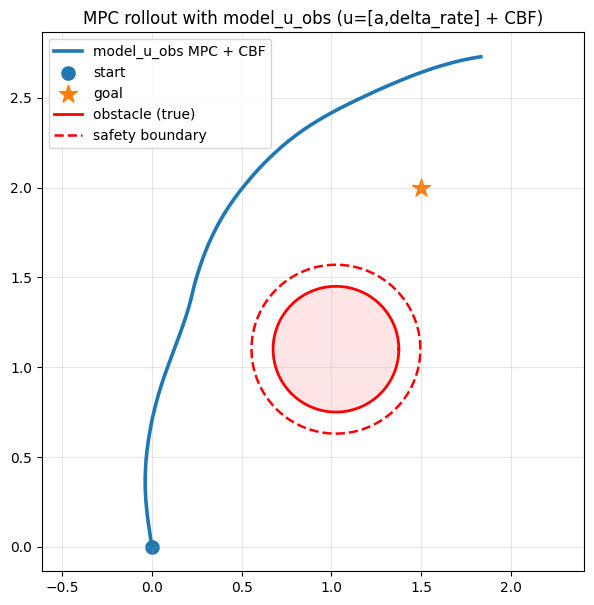

In [10]:
# ===============================================================
# NEW CELL: MPC rollout using trained `model_u_obs` (canonicalized control FM)
#   - canonicalize (state, goal, obstacle)
#   - sample u_seq with model_u_obs
#   - per-step CBF projection on u (cbf_project_control_step_bicycle)
# ===============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt

if "model_u_obs" not in globals():
    raise RuntimeError("model_u_obs not found. Please run the control-UNet training cell first.")

if "cbf_project_control_step_bicycle" not in globals():
    raise RuntimeError("cbf_project_control_step_bicycle not found. Please run the CBF control projection cell first.")


def _wrap_pi(a: float) -> float:
    return float((a + np.pi) % (2 * np.pi) - np.pi)


def _rot2(a: float) -> np.ndarray:
    ca, sa = float(np.cos(a)), float(np.sin(a))
    return np.array([[ca, -sa], [sa, ca]], dtype=np.float64)


def _step_bicycle_u_adelta_local(state5, u, dt, L, delta_max, v_min=0.0, v_max=1.4):
    x, y, th, v, delta = [float(z) for z in state5]
    a, delta_rate = float(u[0]), float(u[1])

    delta = float(np.clip(delta + float(dt) * delta_rate, -float(delta_max), float(delta_max)))
    v = float(np.clip(v + float(dt) * a, float(v_min), float(v_max)))
    th = _wrap_pi(th + float(dt) * (v / float(L)) * np.tan(delta))

    x = float(x + float(dt) * v * np.cos(th))
    y = float(y + float(dt) * v * np.sin(th))

    return np.array([x, y, th, v, delta], dtype=np.float64)


def canonicalize_runtime_obs(state5, goal_xy, obs_xy):
    """Canonicalize for model_u_obs cond = [goal_dist, obs_x, obs_y, v0, cos, sin, delta0]."""
    s = np.asarray(state5, dtype=np.float64)
    p = s[:2]
    g = np.asarray(goal_xy, dtype=np.float64).reshape(2)
    o = np.asarray(obs_xy, dtype=np.float64).reshape(2)

    g0 = g - p
    o0 = o - p

    goal_dist = float(np.linalg.norm(g0) + 1e-12)
    phi = float(np.arctan2(g0[1], g0[0]))
    R = _rot2(-phi)

    o_can = (R @ o0.reshape(2, 1)).reshape(2)

    reflect = False
    if float(o_can[1]) < 0.0:
        reflect = True
        o_can[1] *= -1.0

    theta_can = _wrap_pi(float(s[2]) - phi)
    delta_can = float(s[4])
    if reflect:
        theta_can = -theta_can
        delta_can = -delta_can

    cond = np.array(
        [
            goal_dist,
            float(o_can[0]),
            float(o_can[1]),
            float(s[3]),
            float(np.cos(theta_can)),
            float(np.sin(theta_can)),
            float(delta_can),
        ],
        dtype=np.float32,
    )

    meta = {"phi": phi, "reflect": reflect}
    return cond, meta


def uncanonicalize_u0(u0_can, reflect: bool):
    u = np.asarray(u0_can, dtype=np.float64).reshape(2).copy()
    if reflect:
        u[1] = -u[1]
    return u


def sample_u_seq_obs(model, cond, ctrl_T, *, n_steps=60, device="cpu", noise_scale=1.0):
    dev = torch.device(device)
    model.eval()
    cond_t = torch.as_tensor(cond, dtype=torch.float32, device=dev).view(1, -1)

    x = torch.randn(1, 2, int(ctrl_T), device=dev) * float(noise_scale)
    t_grid = torch.linspace(0.0, 1.0, int(n_steps) + 1, device=dev)

    with torch.no_grad():
        for i in range(int(n_steps)):
            t = t_grid[i].view(1)
            v = model(x, t, cond=cond_t)
            if v.shape[-1] != x.shape[-1]:
                Lmin = min(v.shape[-1], x.shape[-1])
                v = v[..., :Lmin]
                x = x[..., :Lmin]
            x = x + float(t_grid[i + 1] - t_grid[i]) * v

    return x[0].detach().cpu().numpy().T.astype(np.float64)  # (T,2)


def _circle_list_to_ellipses(circles):
    ell = []
    for c in circles:
        if isinstance(c, dict):
            center = np.asarray(c["center"], dtype=np.float64).reshape(2)
            radius = float(c["radius"])
        else:
            cx, cy, r = c
            center = np.asarray([cx, cy], dtype=np.float64)
            radius = float(r)
        ell.append({"center": center, "radius": radius})
    return ell


def mpc_rollout_model_u_obs_with_cbf(
    x0_state,
    goal_xy,
    *,
    circles,
    dt=0.02,
    L=0.8,
    a_max=1.0,
    delta_rate_max=np.deg2rad(120.0),
    delta_max=np.deg2rad(30.0),
    v_min=0.0,
    v_max=1.4,
    max_total_steps=400,
    goal_tol=0.15,
    # FM sampling
    ctrl_T=60,
    n_steps_sample=60,
    noise_scale=1.0,
    device="cpu",
    # CBF
    safety_margin=0.12,
    gamma_min=6.0,
    max_corr_norm=10.0,
):
    x0_state = np.asarray(x0_state, dtype=np.float64).reshape(-1)
    if x0_state.shape[0] >= 5:
        x, y, th, v, delta = [float(z) for z in x0_state[:5]]
    else:
        x, y, th, v = [float(z) for z in x0_state[:4]]
        delta = 0.0

    g = np.asarray(goal_xy, dtype=np.float64).reshape(2)
    ellipses_true = _circle_list_to_ellipses(circles)

    xs = [np.array([x, y, th, v, delta], dtype=np.float64)]

    for _ in range(int(max_total_steps)):
        dist = float(np.linalg.norm(np.array([x, y], dtype=np.float64) - g))
        if dist <= float(goal_tol):
            break

        # choose the closest obstacle for conditioning
        if len(ellipses_true) > 0:
            centers = np.stack([e["center"] for e in ellipses_true], axis=0)
            d2 = np.sum((centers - np.array([x, y], dtype=np.float64)) ** 2, axis=1)
            obs_idx = int(np.argmin(d2))
            obs_xy = centers[obs_idx]
        else:
            obs_xy = np.array([x + 1.0, y + 0.0], dtype=np.float64)

        cond, meta = canonicalize_runtime_obs([x, y, th, v, delta], g, obs_xy)
        u_seq_can = sample_u_seq_obs(
            model_u_obs,
            cond,
            ctrl_T=ctrl_T,
            n_steps=n_steps_sample,
            device=device,
            noise_scale=noise_scale,
        )
        u0_can = u_seq_can[0]
        u0_nom = uncanonicalize_u0(u0_can, reflect=bool(meta["reflect"]))

        # clamp nominal
        u0_nom[0] = float(np.clip(u0_nom[0], -float(a_max), float(a_max)))
        u0_nom[1] = float(np.clip(u0_nom[1], -float(delta_rate_max), float(delta_rate_max)))

        # CBF projection on control (per step)
        u0_safe = cbf_project_control_step_bicycle(
            np.array([x, y, th, v, delta], dtype=np.float64),
            u0_nom,
            dt=float(dt),
            L=float(L),
            delta_max=float(delta_max),
            a_max=float(a_max),
            delta_rate_max=float(delta_rate_max),
            v_min=float(v_min),
            v_max=float(v_max),
            ellipses=ellipses_true,
            extra_margin=float(safety_margin),
            max_corr_norm=float(max_corr_norm),
            gamma_min=float(gamma_min),
            device=str(device),
        )

        # step dynamics
        s_next = _step_bicycle_u_adelta_local(
            np.array([x, y, th, v, delta], dtype=np.float64),
            u0_safe,
            dt=float(dt),
            L=float(L),
            delta_max=float(delta_max),
            v_min=float(v_min),
            v_max=float(v_max),
        )
        x, y, th, v, delta = [float(z) for z in s_next]
        xs.append(s_next)

    return np.asarray(xs, dtype=np.float64), ellipses_true


# -------------------------
# Demo (uses same setup as previous MPC cell)
# -------------------------
if "_s0" in globals():
    _s0_obs = np.asarray(_s0, dtype=np.float64)
else:
    _s0_obs = np.array([0.0, 0.0, 0.8, 0.25, 0.0], dtype=np.float64)

if "_goal" in globals():
    _goal_obs = np.asarray(_goal, dtype=np.float64)
else:
    _goal_obs = np.array([1.5, 2.0], dtype=np.float64)

if "circles" in globals():
    circles_obs = circles
else:
    mid = _s0_obs[:2] + 0.55 * (_goal_obs - _s0_obs[:2])
    circles_obs = [
        {"center": mid + np.array([0.20, 0.0], dtype=np.float64), "radius": 0.35}
    ]

if "data" in globals() and isinstance(data, dict) and "params" in data:
    dt = float(data["params"].get("dt", 0.1))
    L = float(data["params"].get("L", 0.8))
    delta_max = float(data["params"].get("delta_max", np.deg2rad(30.0)))
    a_max = float(data["params"].get("a_max", 0.8))
    delta_rate_max = float(data["params"].get("delta_rate_max", np.deg2rad(120.0)))
else:
    dt, L = 0.1, 0.8
    delta_max = float(np.deg2rad(30.0))
    a_max = 0.8
    delta_rate_max = float(np.deg2rad(120.0))

if "CTRL_T" in globals():
    ctrl_T = int(CTRL_T)
else:
    ctrl_T = 60

xs_mpc_obs, circles_true_obs = mpc_rollout_model_u_obs_with_cbf(
    _s0_obs,
    _goal_obs,
    circles=circles_obs,
    dt=float(dt),
    L=float(L),
    a_max=float(a_max),
    delta_rate_max=float(delta_rate_max),
    delta_max=float(delta_max),
    v_min=0.0,
    v_max=1.4,
    max_total_steps=500,
    goal_tol=0.15,
    ctrl_T=int(ctrl_T),
    n_steps_sample=60,
    noise_scale=1.0,
    safety_margin=float(globals().get("safety_margin", 0.12)),
    gamma_min=6.0,
    max_corr_norm=10.0,
    device=str(globals().get("device", "cpu")),
)

# Plot
th = np.linspace(0.0, 2 * np.pi, 360)
plt.figure(figsize=(7, 7))
plt.plot(xs_mpc_obs[:, 0], xs_mpc_obs[:, 1], "-", linewidth=2.6, label="model_u_obs MPC + CBF")
plt.scatter([xs_mpc_obs[0, 0]], [xs_mpc_obs[0, 1]], s=90, label="start")
plt.scatter([_goal_obs[0]], [_goal_obs[1]], s=180, marker="*", label="goal")

margin = float(globals().get("safety_margin", 0.12))
for e in circles_true_obs:
    c = np.asarray(e["center"], dtype=np.float64).reshape(2)
    R = float(e["radius"])
    plt.plot(c[0] + R * np.cos(th), c[1] + R * np.sin(th), "r-", linewidth=2.0, label="obstacle (true)")
    plt.fill(c[0] + R * np.cos(th), c[1] + R * np.sin(th), color="red", alpha=0.10)
    R_safe = R + margin
    plt.plot(c[0] + R_safe * np.cos(th), c[1] + R_safe * np.sin(th), "r--", linewidth=1.8, label="safety boundary")

plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.title("MPC rollout with model_u_obs (u=[a,delta_rate] + CBF)")
plt.legend()
plt.show()



In [ ]:
# ===============================================================
# NEW CELL (updated): MPC rollout using trained `model_u_obs`
#   - canonicalize (state, goal, obstacle)
#   - sample u_seq with torchdiffeq.odeint
#   - CBF is applied INSIDE the ODE function to make the WHOLE u_seq safe
#   - outer loop executes only u0_safe (NO external CBF anymore)
# ===============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt
import math

import torchdiffeq

if "model_u_obs" not in globals():
    raise RuntimeError("model_u_obs not found. Please run the control-UNet training cell first.")

if "cbf_project_control_step_bicycle" not in globals():
    raise RuntimeError("cbf_project_control_step_bicycle not found. Please run the CBF control projection cell first.")


def _wrap_pi(a: float) -> float:
    return float((a + np.pi) % (2 * np.pi) - np.pi)


def _rot2(a: float) -> np.ndarray:
    ca, sa = float(np.cos(a)), float(np.sin(a))
    return np.array([[ca, -sa], [sa, ca]], dtype=np.float64)


def _step_bicycle_u_adelta_local(state5, u, dt, L, delta_max, v_min=0.0, v_max=1.4):
    x, y, th, v, delta = [float(z) for z in state5]
    a, delta_rate = float(u[0]), float(u[1])

    delta = float(np.clip(delta + float(dt) * delta_rate, -float(delta_max), float(delta_max)))
    v = float(np.clip(v + float(dt) * a, float(v_min), float(v_max)))
    th = _wrap_pi(th + float(dt) * (v / float(L)) * np.tan(delta))

    x = float(x + float(dt) * v * np.cos(th))
    y = float(y + float(dt) * v * np.sin(th))

    return np.array([x, y, th, v, delta], dtype=np.float64)


def canonicalize_runtime_obs(state5, goal_xy, obs_xy):
    """Canonicalize for model_u_obs cond = [goal_dist, obs_x, obs_y, v0, cos, sin, delta0]."""
    s = np.asarray(state5, dtype=np.float64)
    p = s[:2]
    g = np.asarray(goal_xy, dtype=np.float64).reshape(2)
    o = np.asarray(obs_xy, dtype=np.float64).reshape(2)

    g0 = g - p
    o0 = o - p

    goal_dist = float(np.linalg.norm(g0) + 1e-12)
    phi = float(np.arctan2(g0[1], g0[0]))
    R = _rot2(-phi)

    o_can = (R @ o0.reshape(2, 1)).reshape(2)

    reflect = False
    if float(o_can[1]) < 0.0:
        reflect = True
        o_can[1] *= -1.0

    theta_can = _wrap_pi(float(s[2]) - phi)
    delta_can = float(s[4])
    if reflect:
        theta_can = -theta_can
        delta_can = -delta_can

    cond = np.array(
        [
            goal_dist,
            float(o_can[0]),
            float(o_can[1]),
            float(s[3]),
            float(np.cos(theta_can)),
            float(np.sin(theta_can)),
            float(delta_can),
        ],
        dtype=np.float32,
    )

    meta = {"phi": phi, "reflect": reflect}
    return cond, meta


def uncanonicalize_u_seq(u_seq_can_T2, reflect: bool):
    """Apply reflection back (only affects delta_rate sign in your convention)."""
    u = np.asarray(u_seq_can_T2, dtype=np.float64).copy()
    if reflect:
        u[:, 1] *= -1.0
    return u


def _circle_list_to_ellipses(circles):
    ell = []
    for c in circles:
        if isinstance(c, dict):
            center = np.asarray(c["center"], dtype=np.float64).reshape(2)
            radius = float(c["radius"])
        else:
            cx, cy, r = c
            center = np.asarray([cx, cy], dtype=np.float64)
            radius = float(r)
        ell.append({"center": center, "radius": radius})
    return ell


# ---------------------------------------------------------------
# ODE sampling WITH CBF INSIDE ODE FUNC (control-space shielding)
# ---------------------------------------------------------------
def sample_u_seq_obs_safe_odeint(
    *,
    model,
    cond,
    ctrl_T: int,
    # ODE solve
    T_SPAN: torch.Tensor,      # e.g. torch.linspace(0,1,n_steps+1)
    solver_method: str = "euler",
    solver_tol: float = 1e-5,
    noise_scale: float = 1.0,
    device: str = "cpu",
    # CBF + dynamics params (needed for projecting candidate sequence)
    state5_world,
    ellipses_true,
    dt_world: float,
    L: float,
    delta_max: float,
    a_max: float,
    delta_rate_max: float,
    v_min: float,
    v_max: float,
    safety_margin: float,
    gamma_min: float,
    max_corr_norm: float,
):
    """
    Returns:
        u_seq_safe_T2 in CANONICAL frame (still canonical), shape (T,2)
        and also returns u_seq_safe_T2_world (after uncanonicalize) outside if needed
    """

    dev = torch.device(device)
    model.eval()

    cond_t = torch.as_tensor(cond, dtype=torch.float32, device=dev).view(1, -1)

    # ODE state is "u_seq" in shape (1,2,T)
    x0 = torch.randn(1, 2, int(ctrl_T), device=dev) * float(noise_scale)

    # We'll need a fixed ODE dt for computing v_safe = (u_safe - u)/dt_ode
    # Here assume uniform span.
    t_span = T_SPAN.to(dev)
    if t_span.numel() < 2:
        raise ValueError("T_SPAN must have at least 2 points.")
    dt_ode = float((t_span[1] - t_span[0]).item())

    state5_world = np.asarray(state5_world, dtype=np.float64).reshape(5)

    def fm_ode_func(t, x_flat):
        # reshape
        u_can = x_flat.view(1, 2, int(ctrl_T))
        t_tensor = torch.tensor([t], device=u_can.device, dtype=u_can.dtype)

        # nominal velocity field in control-seq space
        with torch.no_grad():
            v_nom = model(u_can, t_tensor, cond=cond_t)  # (1,2,T)

        # --------- CBF INSIDE ODE ----------
        # 1) take one Euler step in ODE space to get a candidate u_seq
        u_can_next = (u_can + dt_ode * v_nom).detach().cpu().numpy()[0].T.astype(np.float64)  # (T,2) canonical

        # 2) uncanonicalize to world control convention (reflect back)
        #    (reflection is handled outside; for ODE internal we need it too.
        #     We'll pass reflect via closure by embedding it into cond/meta outside.)
        # NOTE: We'll store reflect in a global closure variable by attaching to function object.
        reflect = getattr(fm_ode_func, "_reflect", False)
        u_world_candidate = uncanonicalize_u_seq(u_can_next, reflect=bool(reflect))

        # 3) clamp candidate nominal controls (keep it within bounds)
        u_world_candidate[:, 0] = np.clip(u_world_candidate[:, 0], -float(a_max), float(a_max))
        u_world_candidate[:, 1] = np.clip(u_world_candidate[:, 1], -float(delta_rate_max), float(delta_rate_max))

        # 4) Now project the WHOLE sequence step-by-step using your control CBF projector
        #    We need to simulate forward because CBF depends on predicted state at each step.
        s = state5_world.copy()
        u_world_safe = np.zeros_like(u_world_candidate)

        for k in range(int(ctrl_T)):
            u_nom_k = u_world_candidate[k].copy()

            u_safe_k = cbf_project_control_step_bicycle(
                s,                         # current predicted state
                u_nom_k,
                dt=float(dt_world),
                L=float(L),
                delta_max=float(delta_max),
                a_max=float(a_max),
                delta_rate_max=float(delta_rate_max),
                v_min=float(v_min),
                v_max=float(v_max),
                ellipses=ellipses_true,
                extra_margin=float(safety_margin),
                max_corr_norm=float(max_corr_norm),
                gamma_min=float(gamma_min),
                device=str(device),
            )
            u_world_safe[k] = np.asarray(u_safe_k, dtype=np.float64).reshape(2)

            # advance predicted state using SAFE control (dynamics-consistent)
            s = _step_bicycle_u_adelta_local(
                s, u_world_safe[k], dt=float(dt_world), L=float(L),
                delta_max=float(delta_max), v_min=float(v_min), v_max=float(v_max)
            )

        # 5) convert back to canonical controls (apply reflect again)
        #    reflect means world<->canonical flip for delta_rate sign only.
        u_can_safe = u_world_safe.copy()
        if bool(reflect):
            u_can_safe[:, 1] *= -1.0

        # 6) Convert safe sequence back to tensor state (1,2,T)
        u_can_safe_t = torch.as_tensor(u_can_safe.T, dtype=u_can.dtype, device=u_can.device).unsqueeze(0)

        # 7) Define v_safe so that Euler step lands exactly on u_can_safe_t
        v_safe = (u_can_safe_t - u_can) / max(dt_ode, 1e-9)

        return v_safe.view(-1)

    # We will attach reflect as an attribute before calling odeint
    # (clean trick to avoid adding it to odeint signature)
    # NOTE: set later by caller, per step.
    fm_ode_func._reflect = False

    with torch.no_grad():
        sol = torchdiffeq.odeint(
            fm_ode_func,
            x0.view(-1),
            t_span,
            atol=float(solver_tol),
            rtol=float(solver_tol),
            method=str(solver_method),
        )
        u_final_can = sol[-1].view(1, 2, int(ctrl_T))  # (1,2,T)

    return u_final_can[0].detach().cpu().numpy().T.astype(np.float64), fm_ode_func  # (T,2), and func handle


# ---------------------------------------------------------------
# Outer loop: NO external CBF; u0 is already safe (ODE-internal)
# ---------------------------------------------------------------
def mpc_rollout_model_u_obs_with_cbf_inside_ode(
    x0_state,
    goal_xy,
    *,
    circles,
    # world dynamics params
    dt=0.02,
    L=0.8,
    a_max=1.0,
    delta_rate_max=np.deg2rad(120.0),
    delta_max=np.deg2rad(30.0),
    v_min=0.0,
    v_max=1.4,
    max_total_steps=400,
    goal_tol=0.15,
    # FM ODE sampling params
    ctrl_T=60,
    n_steps_sample=60,
    noise_scale=1.0,
    device="cpu",
    solver_method="euler",
    solver_tol=1e-5,
    # CBF params (used INSIDE ode func)
    safety_margin=0.12,
    gamma_min=6.0,
    max_corr_norm=10.0,
):
    x0_state = np.asarray(x0_state, dtype=np.float64).reshape(-1)
    if x0_state.shape[0] >= 5:
        x, y, th, v, delta = [float(z) for z in x0_state[:5]]
    else:
        x, y, th, v = [float(z) for z in x0_state[:4]]
        delta = 0.0

    g = np.asarray(goal_xy, dtype=np.float64).reshape(2)
    ellipses_true = _circle_list_to_ellipses(circles)

    xs = [np.array([x, y, th, v, delta], dtype=np.float64)]

    # ODE time grid (0->1)
    T_SPAN = torch.linspace(0.0, 1.0, int(n_steps_sample) + 1)

    for _ in range(int(max_total_steps)):
        dist = float(np.linalg.norm(np.array([x, y], dtype=np.float64) - g))
        if dist <= float(goal_tol):
            break

        # closest obstacle for conditioning
        if len(ellipses_true) > 0:
            centers = np.stack([e["center"] for e in ellipses_true], axis=0)
            d2 = np.sum((centers - np.array([x, y], dtype=np.float64)) ** 2, axis=1)
            obs_idx = int(np.argmin(d2))
            obs_xy = centers[obs_idx]
        else:
            obs_xy = np.array([x + 1.0, y + 0.0], dtype=np.float64)

        cond, meta = canonicalize_runtime_obs([x, y, th, v, delta], g, obs_xy)

        # --- sample whole u_seq with CBF INSIDE ODE ---
        # We need to set reflect flag on the ode func (one-liner trick)
        # by retrieving the func handle from sampler.
        u_seq_can, ode_func_handle = sample_u_seq_obs_safe_odeint(
            model=model_u_obs,
            cond=cond,
            ctrl_T=int(ctrl_T),
            T_SPAN=T_SPAN,
            solver_method=solver_method,
            solver_tol=solver_tol,
            noise_scale=noise_scale,
            device=device,
            # CBF projection needs current world state + obstacles
            state5_world=np.array([x, y, th, v, delta], dtype=np.float64),
            ellipses_true=ellipses_true,
            dt_world=float(dt),
            L=float(L),
            delta_max=float(delta_max),
            a_max=float(a_max),
            delta_rate_max=float(delta_rate_max),
            v_min=float(v_min),
            v_max=float(v_max),
            safety_margin=float(safety_margin),
            gamma_min=float(gamma_min),
            max_corr_norm=float(max_corr_norm),
        )
        ode_func_handle._reflect = bool(meta["reflect"])  # ensure reflect used inside (important!)

        # Take first control (already safe in canonical), convert to world convention
        u0_can_safe = u_seq_can[0]
        u_seq_world_safe = uncanonicalize_u_seq(u_seq_can, reflect=bool(meta["reflect"]))
        u0_safe = u_seq_world_safe[0].copy()

        # clamp (should already be within bounds, but keep safe)
        u0_safe[0] = float(np.clip(u0_safe[0], -float(a_max), float(a_max)))
        u0_safe[1] = float(np.clip(u0_safe[1], -float(delta_rate_max), float(delta_rate_max)))

        # execute one step with dynamics (NO external CBF)
        s_next = _step_bicycle_u_adelta_local(
            np.array([x, y, th, v, delta], dtype=np.float64),
            u0_safe,
            dt=float(dt),
            L=float(L),
            delta_max=float(delta_max),
            v_min=float(v_min),
            v_max=float(v_max),
        )
        x, y, th, v, delta = [float(z) for z in s_next]
        xs.append(s_next)

    return np.asarray(xs, dtype=np.float64), ellipses_true


# -------------------------
# Demo (uses same setup as your previous cell)
# -------------------------
if "_s0" in globals():
    _s0_obs = np.asarray(_s0, dtype=np.float64)
else:
    _s0_obs = np.array([0.0, 0.0, 0.8, 0.25, 0.0], dtype=np.float64)

if "_goal" in globals():
    _goal_obs = np.asarray(_goal, dtype=np.float64)
else:
    _goal_obs = np.array([1.5, 2.0], dtype=np.float64)

if "circles" in globals():
    circles_obs = circles
else:
    mid = _s0_obs[:2] + 0.55 * (_goal_obs - _s0_obs[:2])
    circles_obs = [
        {"center": mid + np.array([0.20, 0.0], dtype=np.float64), "radius": 0.35}
    ]

if "data" in globals() and isinstance(data, dict) and "params" in data:
    dt = float(data["params"].get("dt", 0.1))
    L = float(data["params"].get("L", 0.8))
    delta_max = float(data["params"].get("delta_max", np.deg2rad(30.0)))
    a_max = float(data["params"].get("a_max", 0.8))
    delta_rate_max = float(data["params"].get("delta_rate_max", np.deg2rad(120.0)))
else:
    dt, L = 0.1, 0.8
    delta_max = float(np.deg2rad(30.0))
    a_max = 0.8
    delta_rate_max = float(np.deg2rad(120.0))

if "CTRL_T" in globals():
    ctrl_T = int(CTRL_T)
else:
    ctrl_T = 60

xs_mpc_obs, circles_true_obs = mpc_rollout_model_u_obs_with_cbf_inside_ode(
    _s0_obs,
    _goal_obs,
    circles=circles_obs,
    dt=float(dt),
    L=float(L),
    a_max=float(a_max),
    delta_rate_max=float(delta_rate_max),
    delta_max=float(delta_max),
    v_min=0.0,
    v_max=1.4,
    max_total_steps=500,
    goal_tol=0.15,
    ctrl_T=int(ctrl_T),
    n_steps_sample=60,
    noise_scale=1.0,
    safety_margin=float(globals().get("safety_margin", 0.12)),
    gamma_min=6.0,
    max_corr_norm=10.0,
    device=str(globals().get("device", "cpu")),
    solver_method=str(globals().get("SOLVER_METHOD", "euler")),
    solver_tol=float(globals().get("SOLVER_TOLERANCE", 1e-5)),
)

# Plot
th_grid = np.linspace(0.0, 2 * np.pi, 360)
plt.figure(figsize=(7, 7))
plt.plot(xs_mpc_obs[:, 0], xs_mpc_obs[:, 1], "-", linewidth=2.6, label="model_u_obs (CBF inside ODE)")
plt.scatter([xs_mpc_obs[0, 0]], [xs_mpc_obs[0, 1]], s=90, label="start")
plt.scatter([_goal_obs[0]], [_goal_obs[1]], s=180, marker="*", label="goal")

margin = float(globals().get("safety_margin", 0.12))
for e in circles_true_obs:
    c = np.asarray(e["center"], dtype=np.float64).reshape(2)
    R = float(e["radius"])
    plt.plot(c[0] + R * np.cos(th_grid), c[1] + R * np.sin(th_grid), "r-", linewidth=2.0, label="obstacle (true)")
    plt.fill(c[0] + R * np.cos(th_grid), c[1] + R * np.sin(th_grid), color="red", alpha=0.10)
    R_safe = R + margin
    plt.plot(c[0] + R_safe * np.cos(th_grid), c[1] + R_safe * np.sin(th_grid), "r--", linewidth=1.8, label="safety boundary")

plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.title("Rollout with model_u_obs (CBF enforced INSIDE ODE sampling)")
plt.legend()
plt.show()


In [12]:
# ===============================================================
# NEW CELL: Second-order state ODE with control-output FM (a, alpha)
#   state s = [x, y, theta, v, omega]
#   model outputs u = [a, alpha]
#   x_dot = v cos(theta), y_dot = v sin(theta), theta_dot = omega
#   v_dot = a, omega_dot = alpha
#   optional: CBF applied to (x_dot, y_dot) in world frame
# ===============================================================

import torch


def generate_state_trajectory_second_order(
    flow_model_u,
    *,
    traj_len=100,
    T_final=1.0,
    n_steps=50,
    use_cbf=False,
    ellipses=None,
    extra_margin=0.12,
    max_corr_norm=10.0,
    gamma_min=6.0,
    device="cpu",
    solver_method="dopri5",
    solver_tolerance=1e-5,
):
    """
    Generate a trajectory using a control-output FM model (project local definitions).

    flow_model_u: outputs u = [a, alpha] with shape (1,2,N)
    state: s = [x, y, theta, v, omega] with shape (1,5,N)
    """
    if use_cbf and "cbf_project_velocity_world" not in globals():
        raise RuntimeError("cbf_project_velocity_world not found. Run the CBF cell first.")

    dev = torch.device(device)
    N = int(traj_len)
    ellipses = ellipses or []

    # Ensure model input channels match 5D state
    in_ch = getattr(flow_model_u, "in_channels", None)
    if in_ch is None and hasattr(flow_model_u, "conv_in"):
        in_ch = getattr(flow_model_u.conv_in, "in_channels", None)
    if in_ch is not None and int(in_ch) != 5:
        raise RuntimeError(
            f"flow_model_u expects in_channels={in_ch}, but state ODE uses 5. "
            "Instantiate SimpleUNet1D(in_channels=5, out_channels=2) and retrain."
        )

    def fm_ode_func(t, s_flat):
        # reshape to (1,5,N)
        s = s_flat.view(1, 5, N).to(dev)
        t_tensor = torch.tensor([t], device=dev, dtype=s.dtype)

        # model predicts controls u=[a, alpha]
        with torch.no_grad():
            u_nom = flow_model_u(s, t_tensor)  # (1,2,N)

        a_nom = u_nom[:, 0:1, :]  # (1,1,N)
        alpha_nom = u_nom[:, 1:2, :]

        x = s[:, 0:1, :]
        y = s[:, 1:2, :]
        theta = s[:, 2:3, :]
        v = s[:, 3:4, :]
        omega = s[:, 4:5, :]

        x_dot = v * torch.cos(theta)
        y_dot = v * torch.sin(theta)
        theta_dot = omega
        v_dot = a_nom
        omega_dot = alpha_nom

        if use_cbf and len(ellipses) > 0:
            # project only XY velocity in world frame
            v_nom_xy = torch.cat([x_dot, y_dot], dim=1)  # (1,2,N)
            v_safe_xy = cbf_project_velocity_world(
                s[:, 0:2, :],
                v_nom_xy,
                ellipses=ellipses,
                extra_margin=float(extra_margin),
                max_corr_norm=float(max_corr_norm),
                passes=5,
                other_agent_traj=None,
                agent_safe_radius=0.5,
                gamma_min=float(gamma_min),
                w_p=0.0,
                press_k=1.0,
                press_n=2.0,
            )
            x_dot = v_safe_xy[:, 0:1, :]
            y_dot = v_safe_xy[:, 1:2, :]

        s_dot = torch.cat([x_dot, y_dot, theta_dot, v_dot, omega_dot], dim=1)
        return s_dot.view(-1)

    # Solve ODE
    with torch.no_grad():
        s0_noise = torch.randn((1, 5, N), device=dev)
        t_span = torch.linspace(0.0, float(T_final), steps=int(n_steps) + 1, device=dev)

        if "HAS_TORCHDIFFEQ" in globals() and HAS_TORCHDIFFEQ:
            solution = torchdiffeq.odeint(
                fm_ode_func,
                s0_noise.view(-1),
                t_span,
                atol=float(solver_tolerance),
                rtol=float(solver_tolerance),
                method=str(solver_method),
            )
            s_final = solution[-1].view(1, 5, N)
        else:
            # Euler fallback
            s = s0_noise.view(-1)
            dt_list = (t_span[1:] - t_span[:-1]).tolist()
            t_list = t_span[:-1].tolist()
            for t_val, dt in zip(t_list, dt_list):
                s = s + float(dt) * fm_ode_func(float(t_val), s)
            s_final = s.view(1, 5, N)

        return s_final.squeeze(0).detach().cpu().numpy().transpose(1, 0)


print("✅ Second-order state ODE trajectory generator ready")

# -------------------------
# Demo plot (uses local project definitions only)
# -------------------------
if "flow_model_u" in globals():
    model_demo = flow_model_u
elif "model_u_obs" in globals():
    model_demo = model_u_obs
else:
    model_demo = None

if model_demo is not None:
    if "CTRL_T" in globals():
        traj_len = int(CTRL_T)
    else:
        traj_len = 100

    ellipses_demo = []
    if "ellipses" in globals():
        ellipses_demo = ellipses
    elif "circles" in globals():
        ellipses_demo = _circle_list_to_ellipses(circles) if "_circle_list_to_ellipses" in globals() else []

    # Check model input channels to avoid conv1d crash
    in_ch = getattr(model_demo, "in_channels", None)
    if in_ch is None and hasattr(model_demo, "conv_in"):
        in_ch = getattr(model_demo.conv_in, "in_channels", None)

    if in_ch is not None and int(in_ch) != 5:
        print(
            f"⚠️ 当前模型 in_channels={in_ch}，而二阶 ODE 需要 5 通道输入。"
            "请用 SimpleUNet1D(in_channels=5, out_channels=2) 重新训练。"
        )
    else:
        traj_s = generate_state_trajectory_second_order(
            model_demo,
            traj_len=traj_len,
            T_final=1.0,
            n_steps=50,
            use_cbf=True,
            ellipses=ellipses_demo,
            device=str(globals().get("device", "cpu")),
        )

        # traj_s: (N,5) -> [x,y,theta,v,omega]
        plt.figure(figsize=(6, 6))
        plt.plot(traj_s[:, 0], traj_s[:, 1], "-", linewidth=2.2, label="FM ODE + CBF")
        plt.scatter([traj_s[0, 0]], [traj_s[0, 1]], s=80, label="start")
        plt.axis("equal")
        plt.grid(True, alpha=0.3)
        plt.title("Second-order FM ODE trajectory")
        plt.legend()
        plt.show()
else:
    print("⚠️ 需要先定义 flow_model_u 或 model_u_obs 才能画轨迹")


✅ Second-order state ODE trajectory generator ready
⚠️ 当前模型 in_channels=2，而二阶 ODE 需要 5 通道输入。请用 SimpleUNet1D(in_channels=5, out_channels=2) 重新训练。


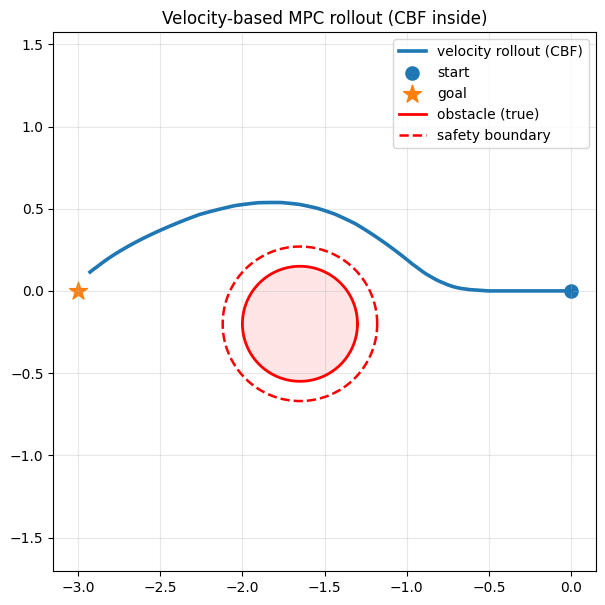

In [19]:
# ===============================================================
# NEW CELL: Keep the old velocity-based rollout (v in XY)
#   - This preserves the earlier "velocity rollout" behavior
#   - Uses CBF in world frame (same as before)
# ===============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt


def mpc_rollout_velocity_with_cbf_circles(
    x0_xy,
    goal_xy,
    *,
    circles,
    dt=0.02,
    v_max=1.4,
    max_total_steps=400,
    goal_tol=0.15,
    H=12,
    n_heading_samples=31,
    heading_span_deg=120.0,
    safety_margin=0.12,
    gamma_min=6.0,
    max_corr_norm=10.0,
    device="cpu",
    w_goal=10.0,
    w_clear=0.25,
    w_turn=0.02,
):
    """Old-style MPC in XY-velocity space; CBF applied inside rollout."""

    x = np.asarray(x0_xy, dtype=np.float64).reshape(2)
    g = np.asarray(goal_xy, dtype=np.float64).reshape(2)

    ellipses_true = _circle_list_to_ellipses(circles)
    extra_margin = float(safety_margin)
    dev = torch.device(device)

    xs = [x.copy()]
    prev_heading = None

    def clearance_penalty(xy):
        eps = 1e-6
        pen = 0.0
        for e in ellipses_true:
            c = np.asarray(e["center"], dtype=np.float64).reshape(2)
            R = float(e["radius"]) + float(safety_margin)
            d2 = float(np.sum((xy - c) ** 2))
            h = d2 - R * R
            if h < 0.0:
                return 1e6
            pen += 1.0 / (h + eps)
        return float(pen)

    for _ in range(int(max_total_steps)):
        dist = float(np.linalg.norm(x - g))
        if dist <= float(goal_tol):
            break

        d = g - x
        base_heading = float(np.arctan2(d[1], d[0]))
        span = np.deg2rad(float(heading_span_deg))
        offsets = np.linspace(-span / 2.0, span / 2.0, int(n_heading_samples), dtype=np.float64)

        best_J = float("inf")
        best_heading = base_heading

        for off in offsets:
            heading = float(base_heading + off)
            x_sim = x.copy()
            J = 0.0

            for _ in range(int(H)):
                v_nom = float(v_max) * np.array([np.cos(heading), np.sin(heading)], dtype=np.float64)
                x_now_2 = torch.tensor(x_sim, dtype=torch.float32, device=dev)
                v_nom_2 = torch.tensor(v_nom, dtype=torch.float32, device=dev)

                v_safe_2 = _cbf_step(
                    x_now_2,
                    v_nom_2,
                    ellipses_true,
                    extra_margin=float(extra_margin),
                    max_corr_norm=float(max_corr_norm),
                    gamma_min=float(gamma_min),
                )
                v_safe = v_safe_2.detach().cpu().numpy().astype(np.float64)
                x_sim = x_sim + float(dt) * v_safe
                J += w_clear * clearance_penalty(x_sim)

            J += w_goal * float(np.sum((x_sim - g) ** 2))
            if prev_heading is not None:
                dphi = float((heading - prev_heading + np.pi) % (2 * np.pi) - np.pi)
                J += w_turn * (dphi * dphi)

            if J < best_J:
                best_J = J
                best_heading = heading

        v_nom = float(v_max) * np.array([np.cos(best_heading), np.sin(best_heading)], dtype=np.float64)
        x_now_2 = torch.tensor(x, dtype=torch.float32, device=dev)
        v_nom_2 = torch.tensor(v_nom, dtype=torch.float32, device=dev)
        v_safe_2 = _cbf_step(
            x_now_2,
            v_nom_2,
            ellipses_true,
            extra_margin=float(extra_margin),
            max_corr_norm=float(max_corr_norm),
            gamma_min=float(gamma_min),
        )
        v_safe = v_safe_2.detach().cpu().numpy().astype(np.float64)

        x = x + float(dt) * v_safe
        xs.append(x.copy())
        prev_heading = best_heading

    return np.asarray(xs, dtype=np.float64), ellipses_true


# -------------------------
# Demo (velocity rollout)
# -------------------------
if "x0_xy" in globals() and "goal_xy" in globals():
    _x0 = np.asarray(x0_xy, dtype=np.float64)
    _goal = np.asarray(goal_xy, dtype=np.float64)
else:
    _x0 = np.array([0.0, 0.0], dtype=np.float64)
    _goal = np.array([1.5, 2.0], dtype=np.float64)

if "obstacle_center" in globals() and "obstacle_radius" in globals():
    circles = [{"center": np.asarray(obstacle_center, dtype=np.float64), "radius": float(obstacle_radius)}]
else:
    mid = _x0 + 0.55 * (_goal - _x0)
    circles = [{"center": mid + np.array([0.20, 0.0], dtype=np.float64), "radius": 0.35}]

xs_vel, circles_true = mpc_rollout_velocity_with_cbf_circles(
    _x0,
    _goal,
    circles=circles,
    dt=0.02,
    v_max=1.4,
    max_total_steps=500,
    goal_tol=0.15,
    H=12,
    n_heading_samples=31,
    heading_span_deg=120.0,
    safety_margin=float(globals().get("safety_margin", 0.12)),
    gamma_min=6.0,
    max_corr_norm=10.0,
    device="cpu",
    w_goal=10.0,
    w_clear=0.25,
    w_turn=0.02,
)

# Plot
th = np.linspace(0.0, 2 * np.pi, 360)
plt.figure(figsize=(7, 7))
plt.plot(xs_vel[:, 0], xs_vel[:, 1], "-", linewidth=2.6, label="velocity rollout (CBF)")
plt.scatter([xs_vel[0, 0]], [xs_vel[0, 1]], s=90, label="start")
plt.scatter([_goal[0]], [_goal[1]], s=180, marker="*", label="goal")

margin = float(globals().get("safety_margin", 0.12))
for e in circles_true:
    c = np.asarray(e["center"], dtype=np.float64).reshape(2)
    R = float(e["radius"])
    plt.plot(c[0] + R * np.cos(th), c[1] + R * np.sin(th), "r-", linewidth=2.0, label="obstacle (true)")
    plt.fill(c[0] + R * np.cos(th), c[1] + R * np.sin(th), color="red", alpha=0.10)
    R_safe = R + margin
    plt.plot(c[0] + R_safe * np.cos(th), c[1] + R_safe * np.sin(th), "r--", linewidth=1.8, label="safety boundary")

plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.title("Velocity-based MPC rollout (CBF inside)")
plt.legend()
plt.show()



[step 000] dist=2.500  bestJ=132.83  v=0.23
[step 020] dist=1.833  bestJ=26.67  v=0.88
[step 040] dist=0.276  bestJ=5.39  v=0.37


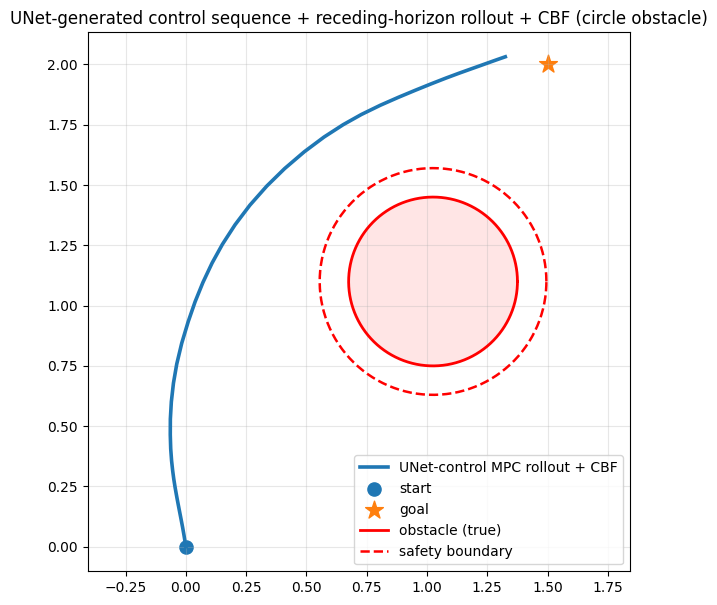

In [ ]:
# ===============================================================
# NEW CELL: Rollout using trained control-UNet `model_u` (receding-horizon) + circle obstacle
#
# - `model_u` generates a CONTROL SEQUENCE u=[a, delta_rate] over CTRL_T.
# - At each time step:
#     sample K candidate control sequences from `model_u`
#     evaluate first H steps with a simple cost + obstacle penalty
#     execute only the first control (receding horizon)
# - Safety: we still apply your CBF projection on the CENTER velocity each step.
#   (CBF is in world XY; we project v=[v*cos(theta), v*sin(theta)] and update x,y accordingly.)
# ===============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt

# -------------------------
# 0) Preconditions
# -------------------------
if "model_u" not in globals():
    raise RuntimeError("`model_u` not found. Please run the Control-UNet training cell first.")

if "CTRL_T" not in globals():
    raise RuntimeError("`CTRL_T` not found. Please run the dataset loading cell first.")

if "cbf_project_velocity_step" not in globals() and "cbf_project_velocity_world" not in globals():
    raise RuntimeError("CBF projector not found. Please run the CBF cell first.")

# fallback for ellipse_h_grad_batch if needed
if "ellipse_h_grad_batch" not in globals():
    def ellipse_h_grad_batch(x_world_2N: torch.Tensor, ellipse: dict):
        if not torch.is_tensor(x_world_2N):
            x_world_2N = torch.as_tensor(x_world_2N, dtype=torch.float32)
        center = ellipse["center"]
        if not torch.is_tensor(center):
            center = torch.as_tensor(center, dtype=x_world_2N.dtype, device=x_world_2N.device)

        if "a" in ellipse or "b" in ellipse:
            a = float(ellipse.get("a", 1.0))
            b = float(ellipse.get("b", 1.0))
        elif "radius" in ellipse:
            r = float(ellipse["radius"])
            a = 1.0 / max(r, 1e-9)
            b = a
        else:
            raise KeyError("ellipse must have keys {'center','a','b'} or {'center','radius'}")

        x_N2 = x_world_2N.transpose(0, 1)
        delta = x_N2 - center.view(1, 2)
        ax = float(a) * delta[:, 0]
        by = float(b) * delta[:, 1]
        h_e = ax * ax + by * by - 1.0
        grad_w = torch.stack([
            2.0 * (float(a) ** 2) * delta[:, 0],
            2.0 * (float(b) ** 2) * delta[:, 1],
        ], dim=1)
        return h_e, grad_w

# fallback bicycle step (if not defined)
if "_step_bicycle_simple" not in globals():
    def _wrap_to_pi(a):
        return float((a + np.pi) % (2 * np.pi) - np.pi)

    def _step_bicycle_simple(state5, u, dt, L, delta_max, v_min=0.0):
        """state=[x,y,theta,v,delta], u=[a, delta_rate]"""
        x, y, th, v, delta = [float(z) for z in state5]
        a, delta_rate = float(u[0]), float(u[1])
        delta = float(np.clip(delta + dt * delta_rate, -delta_max, delta_max))
        v = float(max(v_min, v + dt * a))
        th = _wrap_to_pi(th + dt * (v / float(L)) * np.tan(delta))
        x = float(x + dt * v * np.cos(th))
        y = float(y + dt * v * np.sin(th))
        return np.array([x, y, th, v, delta], dtype=np.float64)


def _circle_h(xy, c, R):
    d = np.asarray(xy, dtype=np.float64) - np.asarray(c, dtype=np.float64)
    return float(d @ d - R * R)


def _circle_list_to_ellipses(circles):
    ell = []
    for c in circles:
        if isinstance(c, dict):
            center = np.asarray(c["center"], dtype=np.float64).reshape(2)
            radius = float(c["radius"])
        else:
            cx, cy, r = c
            center = np.asarray([cx, cy], dtype=np.float64)
            radius = float(r)
        ell.append({"center": center, "radius": radius})
    return ell


def sample_u_seq_from_model(model_u, cond_vec, ctrl_T, *, n_steps=60, device="cpu", noise_scale=1.0):
    """Sample a whole u_seq from the trained control-UNet. Returns (ctrl_T,2)."""
    dev = torch.device(device)
    model_u.eval()

    cond = torch.as_tensor(cond_vec, dtype=torch.float32, device=dev).view(1, -1)
    x = torch.randn(1, 2, int(ctrl_T), device=dev) * float(noise_scale)
    t_grid = torch.linspace(0.0, 1.0, int(n_steps) + 1, device=dev)

    with torch.no_grad():
        for i in range(int(n_steps)):
            t = t_grid[i].view(1)
            v = model_u(x, t, cond=cond)
            if v.shape[-1] != x.shape[-1]:
                Lmin = min(v.shape[-1], x.shape[-1])
                v = v[..., :Lmin]
                x = x[..., :Lmin]
            dt_local = float(t_grid[i + 1] - t_grid[i])
            x = x + dt_local * v

    u_seq = x[0].detach().cpu().numpy().astype(np.float64)  # (2,T)
    return u_seq.T  # (T,2)


def apply_cbf_to_xy(
    xy: np.ndarray,
    v_nom_xy: np.ndarray,
    ellipses,
    *,
    extra_margin: float,
    max_corr_norm: float,
    gamma_min: float,
    device: str,
):
    """Project nominal center velocity in world frame using your CBF."""
    dev = torch.device(device)
    x_now_2 = torch.as_tensor(np.asarray(xy, dtype=np.float64), dtype=torch.float32, device=dev)
    v_nom_2 = torch.as_tensor(np.asarray(v_nom_xy, dtype=np.float64), dtype=torch.float32, device=dev)

    if "cbf_project_velocity_step" in globals():
        v_safe_2 = cbf_project_velocity_step(
            x_now_2,
            v_nom_2,
            ellipses,
            other_agent_pos_2=None,
            agent_safe_radius=0.5,
            extra_margin=float(extra_margin),
            max_corr_norm=float(max_corr_norm),
            gamma_min=float(gamma_min),
            w_p=0.0,
            press_k=1.0,
            press_n=2.0,
        )
        return v_safe_2.detach().cpu().numpy().astype(np.float64)

    # fallback: call world version
    x_traj = x_now_2.view(1, 2, 1)
    v_traj = v_nom_2.view(1, 2, 1)
    v_safe = cbf_project_velocity_world(
        x_traj,
        v_traj,
        ellipses=ellipses,
        extra_margin=float(extra_margin),
        max_corr_norm=float(max_corr_norm),
        passes=5,
        other_agent_traj=None,
        agent_safe_radius=0.5,
        gamma_min=float(gamma_min),
        w_p=0.0,
        press_k=1.0,
        press_n=2.0,
    )
    return v_safe.squeeze(0).squeeze(-1).detach().cpu().numpy().astype(np.float64)


def rollout_unet_control_mpc_circle(
    *,
    model_u,
    init_state5,
    goal_xy,
    circles,
    dt,
    L,
    delta_max,
    a_max,
    delta_rate_max,
    ctrl_T,
    # MPC
    H=12,
    K=24,
    max_steps=260,
    goal_tol=0.18,
    # sampling
    n_steps_sample=60,
    noise_scale=1.0,
    # CBF
    safety_margin=0.12,
    gamma_min=6.0,
    max_corr_norm=10.0,
    # costs
    w_goal=30.0,
    w_u=0.05,
    w_du=0.15,
    w_clear=0.30,
    device="cpu",
    debug_every=20,
):
    goal = np.asarray(goal_xy, dtype=np.float64).reshape(2)
    circles = list(circles)
    ellipses_true = _circle_list_to_ellipses(circles)

    # for clearance cost use SAFE boundary
    def clearance_cost(xy):
        eps = 1e-6
        cost = 0.0
        for e in ellipses_true:
            c = np.asarray(e["center"], dtype=np.float64).reshape(2)
            R = float(e["radius"]) + float(safety_margin)
            h = float(np.sum((xy - c) ** 2) - R * R)
            if h < 0.0:
                return 1e6
            cost += 1.0 / (h + eps)
        return float(cost)

    state = np.asarray(init_state5, dtype=np.float64).copy()
    xs = [state[:2].copy()]
    ctrls = []

    u_last = np.zeros(2, dtype=np.float64)

    for step in range(int(max_steps)):
        dist = float(np.linalg.norm(state[:2] - goal))
        if dist <= float(goal_tol):
            break

        cond_vec = state[:5].copy()

        best_J = float("inf")
        best_u0 = None

        for k in range(int(K)):
            u_seq = sample_u_seq_from_model(
                model_u,
                cond_vec,
                ctrl_T=int(ctrl_T),
                n_steps=int(n_steps_sample),
                device=str(device),
                noise_scale=float(noise_scale) * (1.0 + 0.04 * k),
            )  # (ctrl_T,2)

            # clip once
            u_seq[:, 0] = np.clip(u_seq[:, 0], -float(a_max), float(a_max))
            u_seq[:, 1] = np.clip(u_seq[:, 1], -float(delta_rate_max), float(delta_rate_max))

            # evaluate first H steps
            s = state.copy()
            J = 0.0
            prev_u = u_last

            for t in range(int(H)):
                u = u_seq[t]

                # costs on controls
                J += w_u * float(u[0] * u[0] + u[1] * u[1])
                du = u - prev_u
                J += w_du * float(du[0] * du[0] + du[1] * du[1])
                prev_u = u

                # update v/theta/delta with bicycle, but update x,y through CBF-projected center velocity
                x, y, th, v, delta = [float(z) for z in s]
                a, d_rate = float(u[0]), float(u[1])

                delta = float(np.clip(delta + dt * d_rate, -float(delta_max), float(delta_max)))
                v = float(max(0.0, v + dt * a))
                th = float((th + dt * (v / float(L)) * np.tan(delta) + np.pi) % (2 * np.pi) - np.pi)

                v_nom_xy = np.array([v * np.cos(th), v * np.sin(th)], dtype=np.float64)
                v_safe_xy = apply_cbf_to_xy(
                    np.array([x, y], dtype=np.float64),
                    v_nom_xy,
                    ellipses_true,
                    extra_margin=float(safety_margin),
                    max_corr_norm=float(max_corr_norm),
                    gamma_min=float(gamma_min),
                    device=str(device),
                )

                x = float(x + dt * v_safe_xy[0])
                y = float(y + dt * v_safe_xy[1])

                s = np.array([x, y, th, v, delta], dtype=np.float64)

                # obstacle clearance cost
                J += w_clear * clearance_cost(s[:2])

            # terminal goal cost
            J += w_goal * float(np.sum((s[:2] - goal) ** 2))

            if J < best_J:
                best_J = J
                best_u0 = u_seq[0].copy()

        if best_u0 is None:
            # fallback: small brake + no steer
            best_u0 = np.array([-0.2 * float(a_max), 0.0], dtype=np.float64)

        # execute one step with the chosen u0
        best_u0[0] = float(np.clip(best_u0[0], -float(a_max), float(a_max)))
        best_u0[1] = float(np.clip(best_u0[1], -float(delta_rate_max), float(delta_rate_max)))

        x, y, th, v, delta = [float(z) for z in state]
        a, d_rate = float(best_u0[0]), float(best_u0[1])

        delta = float(np.clip(delta + dt * d_rate, -float(delta_max), float(delta_max)))
        v = float(max(0.0, v + dt * a))
        th = float((th + dt * (v / float(L)) * np.tan(delta) + np.pi) % (2 * np.pi) - np.pi)

        v_nom_xy = np.array([v * np.cos(th), v * np.sin(th)], dtype=np.float64)
        v_safe_xy = apply_cbf_to_xy(
            np.array([x, y], dtype=np.float64),
            v_nom_xy,
            ellipses_true,
            extra_margin=float(safety_margin),
            max_corr_norm=float(max_corr_norm),
            gamma_min=float(gamma_min),
            device=str(device),
        )
        x = float(x + dt * v_safe_xy[0])
        y = float(y + dt * v_safe_xy[1])

        state = np.array([x, y, th, v, delta], dtype=np.float64)
        xs.append(state[:2].copy())
        ctrls.append(best_u0.copy())
        u_last = best_u0.copy()

        if debug_every is not None and step % int(debug_every) == 0:
            print(f"[step {step:03d}] dist={dist:.3f}  bestJ={best_J:.2f}  v={state[3]:.2f}")

    return np.asarray(xs, dtype=np.float64), np.asarray(ctrls, dtype=np.float64), ellipses_true


# -------------------------
# RUN DEMO (reuse earlier variables if present)
# -------------------------
# initial state
if "states_np" in globals():
    s0 = np.asarray(states_np[0, 0], dtype=np.float64)  # [x,y,theta,v,delta]
else:
    s0 = np.array([0.0, 0.0, 0.8, 0.25, 0.0], dtype=np.float64)

# goal
if "goal_xy" in globals():
    goal = np.asarray(goal_xy, dtype=np.float64)
else:
    goal = np.array([1.5, 2.0], dtype=np.float64)

# obstacle: reuse prior obstacle_center/radius if present
if "obstacle_center" in globals() and "obstacle_radius" in globals():
    circles = [{"center": np.asarray(obstacle_center, dtype=np.float64), "radius": float(obstacle_radius)}]
    safety_margin = float(globals().get("safety_margin", 0.12))
else:
    mid = s0[:2] + 0.55 * (goal - s0[:2])
    circles = [{"center": mid + np.array([0.20, 0.0], dtype=np.float64), "radius": 0.35}]
    safety_margin = 0.12

# vehicle params
if "data" in globals() and isinstance(data, dict) and "params" in data:
    dt = float(data["params"].get("dt", 0.1))
    L = float(data["params"].get("L", 0.8))
    delta_max = float(data["params"].get("delta_max", np.deg2rad(30.0)))
    a_max = float(data["params"].get("a_max", 0.8))
    delta_rate_max = float(data["params"].get("delta_rate_max", np.deg2rad(120.0)))
else:
    dt, L = 0.1, 0.8
    delta_max = float(np.deg2rad(30.0))
    a_max = 0.8
    delta_rate_max = float(np.deg2rad(120.0))

xs_unet, us_unet, ell = rollout_unet_control_mpc_circle(
    model_u=model_u,
    init_state5=s0,
    goal_xy=goal,
    circles=circles,
    dt=float(dt),
    L=float(L),
    delta_max=float(delta_max),
    a_max=float(a_max),
    delta_rate_max=float(delta_rate_max),
    ctrl_T=int(CTRL_T),
    H=12,
    K=24,
    max_steps=260,
    goal_tol=0.18,
    n_steps_sample=60,
    noise_scale=1.0,
    safety_margin=float(safety_margin),
    gamma_min=6.0,
    max_corr_norm=10.0,
    w_goal=30.0,
    w_u=0.05,
    w_du=0.15,
    w_clear=0.30,
    device=str(globals().get("device", "cpu")),
    debug_every=20,
)

# Plot
th = np.linspace(0, 2*np.pi, 360)
plt.figure(figsize=(7, 7))
plt.plot(xs_unet[:, 0], xs_unet[:, 1], "-", linewidth=2.6, label="UNet-control MPC rollout + CBF")
plt.scatter([xs_unet[0, 0]], [xs_unet[0, 1]], s=90, label="start")
plt.scatter([goal[0]], [goal[1]], s=180, marker="*", label="goal")

for e in ell:
    c = np.asarray(e["center"], dtype=np.float64).reshape(2)
    R = float(e["radius"])
    plt.plot(c[0] + R*np.cos(th), c[1] + R*np.sin(th), "r-", linewidth=2.0, label="obstacle (true)")
    plt.fill(c[0] + R*np.cos(th), c[1] + R*np.sin(th), color="red", alpha=0.10)
    R_safe = R + float(safety_margin)
    plt.plot(c[0] + R_safe*np.cos(th), c[1] + R_safe*np.sin(th), "r--", linewidth=1.8, label="safety boundary")

plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.title("UNet-generated control sequence + receding-horizon rollout + CBF (circle obstacle)")
plt.legend()
plt.show()



In [ ]:
# ===============================================================
#速度场/heading MPC + CBF” 的 rollout
# NEW CELL: Two-car head-on avoidance (MPC receding-horizon + CBF w/ other_agent)
#
# Framework:
#   - At each step, predict the other agent over horizon H (simple nominal-to-goal rollout).
#   - Ego MPC: search candidate headings; simulate H-step ahead.
#       * Hard constraint: for each i in 1..H, ||xA_i - xB_i|| >= d_safe
#       * Dynamics step uses CBF projection with other_agent (pressure-based stronger repulsion).
#   - Execute 1 step, repeat.
#
# Notes:
#   - MPC constraint gives anticipation; CBF inside ODE is the safety shield.
#   - For a symmetric game, you can run the same MPC for both cars (best-response). This cell
#     keeps it simple: A uses MPC; B follows nominal-to-goal (still protected by CBF).
# ===============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt

# -------------------------
# 0) Robustness: ensure ellipse_h_grad_batch exists (CBF uses it internally)
# -------------------------
if "ellipse_h_grad_batch" not in globals():
    def ellipse_h_grad_batch(x_world_2N: torch.Tensor, ellipse: dict):
        if not torch.is_tensor(x_world_2N):
            x_world_2N = torch.as_tensor(x_world_2N, dtype=torch.float32)
        center = ellipse["center"]
        if not torch.is_tensor(center):
            center = torch.as_tensor(center, dtype=x_world_2N.dtype, device=x_world_2N.device)

        if "a" in ellipse or "b" in ellipse:
            a = float(ellipse.get("a", 1.0))
            b = float(ellipse.get("b", 1.0))
        elif "radius" in ellipse:
            r = float(ellipse["radius"])
            a = 1.0 / max(r, 1e-9)
            b = a
        else:
            raise KeyError("ellipse must have keys {'center','a','b'} or {'center','radius'}")

        x_N2 = x_world_2N.transpose(0, 1)
        delta = x_N2 - center.view(1, 2)
        ax = float(a) * delta[:, 0]
        by = float(b) * delta[:, 1]
        h_e = ax * ax + by * by - 1.0
        grad_w = torch.stack([
            2.0 * (float(a) ** 2) * delta[:, 0],
            2.0 * (float(b) ** 2) * delta[:, 1],
        ], dim=1)
        return h_e, grad_w

# need CBF core
if "cbf_project_velocity_world" not in globals():
    raise RuntimeError("cbf_project_velocity_world not found. Please run the CBF/ODE cell above first.")


def _wrap_pi(a):
    return float((a + np.pi) % (2 * np.pi) - np.pi)


def _find_velocity_model_from_globals():
    for name in (
        "model_stage1",
        "stage1_model",
        "model_vel",
        "model_v",
        "velocity_model",
        "model_traj",
        "model_xy",
        "model_fm",
        "fm_model",
        "flow_model",
        "model_traj_fm",
        "model_traj_v",
    ): 
        m = globals().get(name, None)
        if m is not None:
            return m, name
    return None, None


def _get_fm_traj_len():
    if "traj_xy" in globals():
        return int(np.asarray(traj_xy).shape[2])
    if "data" in globals() and isinstance(data, dict) and "traj_xy" in data:
        return int(np.asarray(data["traj_xy"]).shape[2])
    if "states_np" in globals():
        return int(np.asarray(states_np).shape[1])
    return 60


def _clip_speed(v, v_max):
    n = float(np.linalg.norm(v))
    if n <= 1e-9:
        return v
    if n > float(v_max):
        return (float(v_max) / n) * v
    return v


def _fm_nominal_velocity(xy: np.ndarray, goal_xy: np.ndarray, *, dt: float, model, traj_len: int, device: str) -> np.ndarray:
    """Use trained FM velocity model to get a nominal velocity at the current position."""
    x = np.asarray(xy, dtype=np.float64).reshape(2)
    g = np.asarray(goal_xy, dtype=np.float64).reshape(2)

    ts = np.linspace(0.0, 1.0, int(traj_len), dtype=np.float64)
    traj = (1.0 - ts)[:, None] * x[None, :] + ts[:, None] * g[None, :]
    x_init = torch.as_tensor(traj.T[None, ...], dtype=torch.float32, device=device)

    solver = ODESolver(model=model, traj_len=int(traj_len), use_cbf=False)
    x_T = solver.sample(x_init)

    v = (x_T[0, :, 1] - x_T[0, :, 0]).detach().cpu().numpy().astype(np.float64) / float(dt)
    return v


def _cbf_step_with_other(
    x_now: np.ndarray,
    v_nom: np.ndarray,
    other_now: np.ndarray,
    *,
    dt: float,
    device: str,
    agent_safe_radius: float,
    gamma_min: float,
    w_p: float,
    press_k: float,
    press_n: float,
    max_corr_norm: float,
):
    """Single-step CBF projection using other_agent_pos_2 (no static ellipses)."""
    dev = torch.device(device)
    x_now_2 = torch.as_tensor(np.asarray(x_now, dtype=np.float64), dtype=torch.float32, device=dev)
    v_nom_2 = torch.as_tensor(np.asarray(v_nom, dtype=np.float64), dtype=torch.float32, device=dev)
    other_2 = torch.as_tensor(np.asarray(other_now, dtype=np.float64), dtype=torch.float32, device=dev)

    # If your cbf_project_velocity_step exists, use it (it supports other_agent_pos_2 + pressure params).
    if "cbf_project_velocity_step" in globals():
        v_safe_2 = cbf_project_velocity_step(
            x_now_2,
            v_nom_2,
            ellipses=[],
            other_agent_pos_2=other_2,
            agent_safe_radius=float(agent_safe_radius),
            extra_margin=0.0,
            max_corr_norm=float(max_corr_norm),
            gamma_min=float(gamma_min),
            w_p=float(w_p),
            press_k=float(press_k),
            press_n=float(press_n),
        )
        return v_safe_2.detach().cpu().numpy().astype(np.float64)

    # Fallback: call cbf_project_velocity_world directly (shape (1,2,1))
    x_traj = x_now_2.view(1, 2, 1)
    v_traj = v_nom_2.view(1, 2, 1)
    other_traj = other_2.view(1, 2, 1)
    v_safe = cbf_project_velocity_world(
        x_traj,
        v_traj,
        ellipses=[],
        extra_margin=0.0,
        max_corr_norm=float(max_corr_norm),
        passes=5,
        other_agent_traj=other_traj,
        agent_safe_radius=float(agent_safe_radius),
        gamma_min=float(gamma_min),
        w_p=float(w_p),
        press_k=float(press_k),
        press_n=float(press_n),
    )
    return v_safe.squeeze(0).squeeze(-1).detach().cpu().numpy().astype(np.float64)


def _predict_other_positions(
    xB0: np.ndarray,
    gB: np.ndarray,
    *,
    xA0: np.ndarray,
    dt: float,
    H: int,
    vB_max: float,
    device: str,
    agent_safe_radius: float,
    gamma_min: float,
    w_p: float,
    press_k: float,
    press_n: float,
    max_corr_norm: float,
    model_vel,
    traj_len: int,
):
    """Predict other agent positions over horizon H (including step 0 position).

    Use trained FM velocity model for nominal motion, then apply CBF as a conservative shield.
    """
    xB = np.asarray(xB0, dtype=np.float64).reshape(2).copy()
    xsB = [xB.copy()]

    model_dev = next(model_vel.parameters()).device

    for _ in range(int(H)):
        vB_nom = _fm_nominal_velocity(xB, gB, dt=float(dt), model=model_vel, traj_len=int(traj_len), device=str(model_dev))
        vB_nom = _clip_speed(vB_nom, float(vB_max))
        vB_safe = _cbf_step_with_other(
            x_now=xB,
            v_nom=vB_nom,
            other_now=xA0,   # conservative: treat A as fixed at current position during prediction
            dt=float(dt),
            device=str(device),
            agent_safe_radius=float(agent_safe_radius),
            gamma_min=float(gamma_min),
            w_p=float(w_p),
            press_k=float(press_k),
            press_n=float(press_n),
            max_corr_norm=float(max_corr_norm),
        )
        xB = xB + float(dt) * vB_safe
        xsB.append(xB.copy())

    return np.asarray(xsB, dtype=np.float64)  # (H+1,2)


def two_car_headon_mpc_rollout(
    xA0,
    gA,
    xB0,
    gB,
    *,
    dt=0.02,
    vA_max=1.4,
    vB_max=1.4,
    max_total_steps=650,
    goal_tol=0.18,
    # MPC horizon
    H=12,
    n_heading_samples=41,
    heading_span_deg=150.0,
    # distance preference (MPC constraint)
    d_safe=1.0,
    # CBF parameters (your pressure-based stronger repulsion)
    agent_safe_radius=0.5,
    gamma_min=1.0,
    w_p=6.0,
    press_k=1.0,
    press_n=2.0,
    max_corr_norm=10.0,
    device="cpu",
    # costs
    w_goal=12.0,
    w_turn=0.12,          # ↑ stronger turning penalty -> smoother
    w_dist=80.0,          # distance soft penalty weight (anticipation)
    heading_smooth=0.35,  # low-pass on executed heading (0=no smoothing, 1=fully jump)
    # FM velocity model
    model_vel=None,
    traj_len=None,
):
    """Step-by-step MPC rollout.

    Why it can look "kinky": we pick a heading from a DISCRETE set each step.
    Fixes here:
      - soften distance constraint (penalty instead of infeasible jump)
      - stronger turn penalty + executed heading smoothing
    """

    xA = np.asarray(xA0, dtype=np.float64).reshape(2).copy()
    xB = np.asarray(xB0, dtype=np.float64).reshape(2).copy()
    gA = np.asarray(gA, dtype=np.float64).reshape(2)
    gB = np.asarray(gB, dtype=np.float64).reshape(2)

    if model_vel is None:
        model_vel, model_name = _find_velocity_model_from_globals()
        if model_vel is None:
            raise RuntimeError(
                "FM velocity model not found. Expected one of: model_stage1, stage1_model, model_vel, model_v, velocity_model, model_traj, model_xy"
            )
    if traj_len is None:
        traj_len = _get_fm_traj_len()

    model_dev = next(model_vel.parameters()).device

    xsA = [xA.copy()]
    xsB = [xB.copy()]

    prev_heading = None

    def soft_hinge(z):
        return max(0.0, float(z))

    for step in range(int(max_total_steps)):
        if float(np.linalg.norm(xA - gA)) <= float(goal_tol) and float(np.linalg.norm(xB - gB)) <= float(goal_tol):
            break

        # 1) predict B positions over horizon (simple policy)
        predB = _predict_other_positions(
            xB, gB,
            xA0=xA,
            dt=float(dt),
            H=int(H),
            vB_max=float(vB_max),
            device=str(device),
            agent_safe_radius=float(agent_safe_radius),
            gamma_min=float(gamma_min),
            w_p=float(w_p),
            press_k=float(press_k),
            press_n=float(press_n),
            max_corr_norm=float(max_corr_norm),
            model_vel=model_vel,
            traj_len=int(traj_len),
        )  # (H+1,2)

        # 2) ego MPC (A): search candidate headings; distance handled as SOFT penalty
        vA_fm = _fm_nominal_velocity(xA, gA, dt=float(dt), model=model_vel, traj_len=int(traj_len), device=str(model_dev))
        vA_speed = float(min(float(vA_max), max(1e-3, float(np.linalg.norm(vA_fm)))))
        if float(np.linalg.norm(vA_fm)) <= 1e-9:
            d = gA - xA
            base_heading = float(np.arctan2(d[1], d[0]))
        else:
            base_heading = float(np.arctan2(vA_fm[1], vA_fm[0]))

        span = np.deg2rad(float(heading_span_deg))
        offsets = np.linspace(-span / 2.0, span / 2.0, int(n_heading_samples), dtype=np.float64)

        best_J = float("inf")
        best_heading = base_heading

        for off in offsets:
            heading = float(base_heading + off)

            x_sim = xA.copy()
            J = 0.0

            # simulate H-step ahead with CBF vs predicted other
            for k in range(int(H)):
                vA_nom = float(vA_speed) * np.array([np.cos(heading), np.sin(heading)], dtype=np.float64)

                vA_safe = _cbf_step_with_other(
                    x_now=x_sim,
                    v_nom=vA_nom,
                    other_now=predB[k],
                    dt=float(dt),
                    device=str(device),
                    agent_safe_radius=float(agent_safe_radius),
                    gamma_min=float(gamma_min),
                    w_p=float(w_p),
                    press_k=float(press_k),
                    press_n=float(press_n),
                    max_corr_norm=float(max_corr_norm),
                )

                x_sim = x_sim + float(dt) * vA_safe

                # soft distance penalty at step k+1
                dist_k = float(np.linalg.norm(x_sim - predB[k + 1]))
                viol = soft_hinge(float(d_safe) - dist_k)
                J += w_dist * (viol * viol)

            # terminal goal cost
            J += w_goal * float(np.sum((x_sim - gA) ** 2))

            # smooth turning (prefer continuity)
            if prev_heading is not None:
                dphi = _wrap_pi(heading - prev_heading)
                J += w_turn * (dphi * dphi)

            if J < best_J:
                best_J = J
                best_heading = heading

        # 3) execute 1 step for both cars
        # A uses best heading, but smooth the executed heading to avoid sharp corners
        if prev_heading is None:
            exec_heading = best_heading
        else:
            a = float(np.clip(heading_smooth, 0.0, 1.0))
            dphi = _wrap_pi(best_heading - prev_heading)
            exec_heading = _wrap_pi(prev_heading + a * dphi)

        vA_nom = float(vA_speed) * np.array([np.cos(exec_heading), np.sin(exec_heading)], dtype=np.float64)
        vA_safe = _cbf_step_with_other(
            x_now=xA,
            v_nom=vA_nom,
            other_now=xB,
            dt=float(dt),
            device=str(device),
            agent_safe_radius=float(agent_safe_radius),
            gamma_min=float(gamma_min),
            w_p=float(w_p),
            press_k=float(press_k),
            press_n=float(press_n),
            max_corr_norm=float(max_corr_norm),
        )

        # B uses nominal-to-goal (still CBF-protected vs A)
        vB_nom = _fm_nominal_velocity(xB, gB, dt=float(dt), model=model_vel, traj_len=int(traj_len), device=str(model_dev))
        vB_nom = _clip_speed(vB_nom, float(vB_max))
        vB_safe = _cbf_step_with_other(
            x_now=xB,
            v_nom=vB_nom,
            other_now=xA,
            dt=float(dt),
            device=str(device),
            agent_safe_radius=float(agent_safe_radius),
            gamma_min=float(gamma_min),
            w_p=float(w_p),
            press_k=float(press_k),
            press_n=float(press_n),
            max_corr_norm=float(max_corr_norm),
        )

        xA = xA + float(dt) * vA_safe
        xB = xB + float(dt) * vB_safe

        xsA.append(xA.copy())
        xsB.append(xB.copy())
        prev_heading = exec_heading

        if float(np.linalg.norm(xA - gA)) <= float(goal_tol) and float(np.linalg.norm(xB - gB)) <= float(goal_tol):
            break

    return np.asarray(xsA, dtype=np.float64), np.asarray(xsB, dtype=np.float64)


# -------------------------
# 1) Scenario: head-on (swap goals)
# -------------------------
# Reuse x0/goal from your previous cell if present.
if "x0_xy" in globals() and "goal_xy" in globals():
    xA0 = np.asarray(x0_xy, dtype=np.float64)
    gA = np.asarray(goal_xy, dtype=np.float64)

    # Put the other car near the goal and make it head back to the start (swap-goal head-on)
    xB0 = gA.copy()
    gB = xA0.copy()
else:
    # fallback demo
    xA0 = np.array([-1.5, 0.0], dtype=np.float64)
    gA = np.array([+1.5, 0.0], dtype=np.float64)
    xB0 = np.array([+1.5, 0.0], dtype=np.float64)
    gB = np.array([-1.5, 0.0], dtype=np.float64)

# Slight lateral offset to make it visually clearer (optional)
# If you want the *start points* to be "crossed" (交叉一下), flip the offsets.
CROSS_STARTS = True
LATERAL_OFFSET = 0.25

if CROSS_STARTS:
    # A starts lower lane, B starts upper lane (crossed vs previous setting)
    xA0 = xA0 + np.array([0.0, -LATERAL_OFFSET], dtype=np.float64)
    xB0 = xB0 + np.array([0.0, +LATERAL_OFFSET], dtype=np.float64)
else:
    xA0 = xA0 + np.array([0.0, +LATERAL_OFFSET], dtype=np.float64)
    xB0 = xB0 + np.array([0.0, -LATERAL_OFFSET], dtype=np.float64)

# -------------------------
# 2) Run
# -------------------------
model_vel, model_vel_name = _find_velocity_model_from_globals()
if model_vel is None:
    raise RuntimeError(
        "No FM velocity model found. Set `model_vel = <your trained velocity model>` before running this cell."
    )
traj_len = _get_fm_traj_len()

xsA, xsB = two_car_headon_mpc_rollout(
    xA0, gA, xB0, gB,
    dt=0.02,
    vA_max=1.4,
    vB_max=1.4,
    max_total_steps=800,
    goal_tol=0.18,
    H=12,
    n_heading_samples=41,
    heading_span_deg=150.0,
    d_safe=1.0,
    agent_safe_radius=0.55,
    gamma_min=1.0,
    w_p=6.0,        # pressure strength (closer => stronger repulsion)
    press_k=1.0,
    press_n=2.0,
    max_corr_norm=10.0,
    device="cpu",
    w_goal=12.0,
    w_turn=0.03,
    model_vel=model_vel,
    traj_len=int(traj_len),
)

# -------------------------
# 3) Plot
# -------------------------
plt.figure(figsize=(7, 7))
plt.plot(xsA[:, 0], xsA[:, 1], "-", linewidth=2.4, label="ego A (MPC+CBF)")
plt.plot(xsB[:, 0], xsB[:, 1], "-", linewidth=2.4, label="other B (nominal+CBF)")
plt.scatter([xsA[0, 0]], [xsA[0, 1]], s=90, label="A start")
plt.scatter([gA[0]], [gA[1]], s=180, marker="*", label="A goal")
plt.scatter([xsB[0, 0]], [xsB[0, 1]], s=90, label="B start")
plt.scatter([gB[0]], [gB[1]], s=180, marker="*", label="B goal")

# visualize safety distance band (optional): circle around B start
# (We leave it off by default to avoid clutter.)

plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.title("Two-car head-on avoidance: MPC distance constraints + CBF(other_agent, pressure)")
plt.legend()
plt.show()



RuntimeError: FM velocity model not found. Expected one of: model_stage1, stage1_model, model_vel, model_v, velocity_model, model_traj, model_xy

[symmetric DMPC scenario] A: [-1. -1.] -> [1. 1.]  | B: [ 1. -1.] -> [-1.  1.]


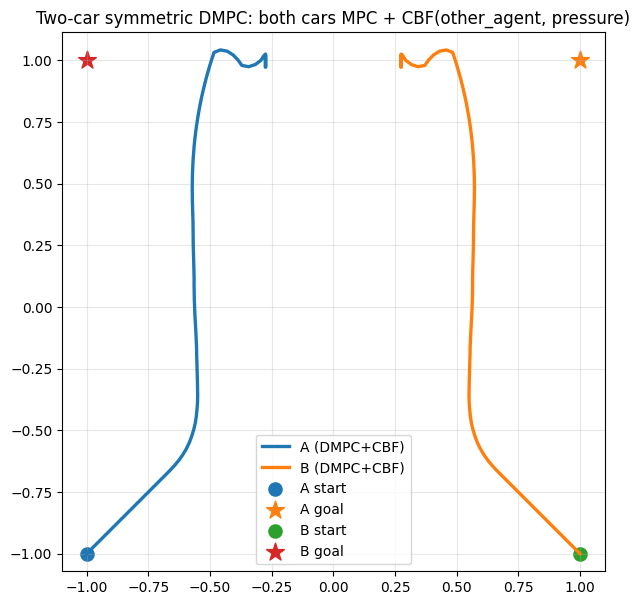

In [ ]:
# ===============================================================
# NEW CELL: Symmetric DMPC (A and B both use MPC) + CBF(other_agent, pressure)
#
# Each time step:
#   - run a small number of best-response iterations to get (heading_A, heading_B)
#   - execute ONE step for both cars (receding horizon)
# Safety is still enforced by your CBF projection inside the step.
# ===============================================================

import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# 0) Reuse helpers from previous cell; define fallbacks if missing
# -------------------------
if "_wrap_pi" not in globals():
    def _wrap_pi(a):
        return float((a + np.pi) % (2 * np.pi) - np.pi)

if "_nominal_velocity_to_goal" not in globals():
    def _nominal_velocity_to_goal(xy: np.ndarray, goal_xy: np.ndarray, v_max: float) -> np.ndarray:
        d = np.asarray(goal_xy, dtype=np.float64).reshape(2) - np.asarray(xy, dtype=np.float64).reshape(2)
        n = float(np.linalg.norm(d) + 1e-12)
        return float(v_max) * (d / n)

if "_cbf_step_with_other" not in globals():
    raise RuntimeError("Please run the previous two-car MPC cell first (it defines `_cbf_step_with_other`).")


def _simulate_heading_rollout_with_other_pred(
    x0: np.ndarray,
    goal: np.ndarray,
    other_pred: np.ndarray,
    *,
    heading: float,
    dt: float,
    H: int,
    v_max: float,
    device: str,
    # CBF
    agent_safe_radius: float,
    gamma_min: float,
    w_p: float,
    press_k: float,
    press_n: float,
    max_corr_norm: float,
    # MPC penalties
    d_safe: float,
    w_goal: float,
    w_turn: float,
    w_dist: float,
    prev_heading: float = None,
):
    """Simulate H steps with fixed heading, CBF against other_pred[k]. Return (J, xH)."""
    x = np.asarray(x0, dtype=np.float64).reshape(2).copy()
    goal = np.asarray(goal, dtype=np.float64).reshape(2)

    def hinge(z):
        return max(0.0, float(z))

    J = 0.0
    for k in range(int(H)):
        v_nom = float(v_max) * np.array([np.cos(heading), np.sin(heading)], dtype=np.float64)
        v_safe = _cbf_step_with_other(
            x_now=x,
            v_nom=v_nom,
            other_now=other_pred[k],
            dt=float(dt),
            device=str(device),
            agent_safe_radius=float(agent_safe_radius),
            gamma_min=float(gamma_min),
            w_p=float(w_p),
            press_k=float(press_k),
            press_n=float(press_n),
            max_corr_norm=float(max_corr_norm),
        )
        x = x + float(dt) * v_safe

        dist_k = float(np.linalg.norm(x - other_pred[k + 1]))
        viol = hinge(float(d_safe) - dist_k)
        J += float(w_dist) * (viol * viol)

    # terminal goal cost
    J += float(w_goal) * float(np.sum((x - goal) ** 2))

    # turning continuity
    if prev_heading is not None:
        dphi = _wrap_pi(float(heading) - float(prev_heading))
        J += float(w_turn) * (dphi * dphi)

    return float(J), x


def _predict_self_over_horizon(
    x0: np.ndarray,
    goal: np.ndarray,
    *,
    heading: float,
    dt: float,
    H: int,
    v_max: float,
    device: str,
    # CBF
    other_current: np.ndarray,
    agent_safe_radius: float,
    gamma_min: float,
    w_p: float,
    press_k: float,
    press_n: float,
    max_corr_norm: float,
):
    """Generate a conservative prediction of this agent for (H+1,2).

    We keep `other_current` fixed during prediction (conservative shield), and still run CBF.
    """
    x = np.asarray(x0, dtype=np.float64).reshape(2).copy()
    goal = np.asarray(goal, dtype=np.float64).reshape(2)

    xs = [x.copy()]
    for _ in range(int(H)):
        v_nom = float(v_max) * np.array([np.cos(heading), np.sin(heading)], dtype=np.float64)
        v_safe = _cbf_step_with_other(
            x_now=x,
            v_nom=v_nom,
            other_now=other_current,
            dt=float(dt),
            device=str(device),
            agent_safe_radius=float(agent_safe_radius),
            gamma_min=float(gamma_min),
            w_p=float(w_p),
            press_k=float(press_k),
            press_n=float(press_n),
            max_corr_norm=float(max_corr_norm),
        )
        x = x + float(dt) * v_safe
        xs.append(x.copy())

    return np.asarray(xs, dtype=np.float64)


def two_car_symmetric_dmpc_rollout(
    xA0,
    gA,
    xB0,
    gB,
    *,
    dt=0.02,
    vA_max=1.4,
    vB_max=1.4,
    max_total_steps=900,
    goal_tol=0.18,
    # MPC horizon
    H=12,
    n_heading_samples=61,
    heading_span_deg=160.0,
    # distance preference
    d_safe=1.0,
    # CBF parameters
    agent_safe_radius=0.55,
    gamma_min=1.0,
    w_p=6.0,
    press_k=1.0,
    press_n=2.0,
    max_corr_norm=10.0,
    device="cpu",
    # MPC penalties
    w_goal=12.0,
    w_turn=0.12,
    w_dist=80.0,
    heading_smooth=0.35,
    # DMPC coupling iterations
    n_best_response_iters=2,
):
    xA = np.asarray(xA0, dtype=np.float64).reshape(2).copy()
    xB = np.asarray(xB0, dtype=np.float64).reshape(2).copy()
    gA = np.asarray(gA, dtype=np.float64).reshape(2)
    gB = np.asarray(gB, dtype=np.float64).reshape(2)

    xsA = [xA.copy()]
    xsB = [xB.copy()]

    prev_hA = None
    prev_hB = None

    span = np.deg2rad(float(heading_span_deg))

    for _step in range(int(max_total_steps)):
        if float(np.linalg.norm(xA - gA)) <= float(goal_tol) and float(np.linalg.norm(xB - gB)) <= float(goal_tol):
            break

        # Initialize headings toward goals
        hA = float(np.arctan2((gA - xA)[1], (gA - xA)[0]))
        hB = float(np.arctan2((gB - xB)[1], (gB - xB)[0]))

        # Best-response iterations (cheap coupling)
        for _ in range(int(max(1, n_best_response_iters))):
            # Predict other trajectories over horizon
            predA = _predict_self_over_horizon(
                xA, gA,
                heading=hA,
                dt=float(dt),
                H=int(H),
                v_max=float(vA_max),
                device=str(device),
                other_current=xB,
                agent_safe_radius=float(agent_safe_radius),
                gamma_min=float(gamma_min),
                w_p=float(w_p),
                press_k=float(press_k),
                press_n=float(press_n),
                max_corr_norm=float(max_corr_norm),
            )
            predB = _predict_self_over_horizon(
                xB, gB,
                heading=hB,
                dt=float(dt),
                H=int(H),
                v_max=float(vB_max),
                device=str(device),
                other_current=xA,
                agent_safe_radius=float(agent_safe_radius),
                gamma_min=float(gamma_min),
                w_p=float(w_p),
                press_k=float(press_k),
                press_n=float(press_n),
                max_corr_norm=float(max_corr_norm),
            )

            # Solve A heading vs predicted B
            baseA = float(np.arctan2((gA - xA)[1], (gA - xA)[0]))
            offsA = np.linspace(-span / 2.0, span / 2.0, int(n_heading_samples), dtype=np.float64)
            bestJA = float("inf")
            bestHA = baseA
            for off in offsA:
                cand = float(baseA + off)
                JA, _ = _simulate_heading_rollout_with_other_pred(
                    xA,
                    gA,
                    predB,
                    heading=cand,
                    dt=float(dt),
                    H=int(H),
                    v_max=float(vA_max),
                    device=str(device),
                    agent_safe_radius=float(agent_safe_radius),
                    gamma_min=float(gamma_min),
                    w_p=float(w_p),
                    press_k=float(press_k),
                    press_n=float(press_n),
                    max_corr_norm=float(max_corr_norm),
                    d_safe=float(d_safe),
                    w_goal=float(w_goal),
                    w_turn=float(w_turn),
                    w_dist=float(w_dist),
                    prev_heading=prev_hA,
                )
                if JA < bestJA:
                    bestJA = JA
                    bestHA = cand
            hA = bestHA

            # Solve B heading vs predicted A
            baseB = float(np.arctan2((gB - xB)[1], (gB - xB)[0]))
            offsB = np.linspace(-span / 2.0, span / 2.0, int(n_heading_samples), dtype=np.float64)
            bestJB = float("inf")
            bestHB = baseB
            for off in offsB:
                cand = float(baseB + off)
                JB, _ = _simulate_heading_rollout_with_other_pred(
                    xB,
                    gB,
                    predA,
                    heading=cand,
                    dt=float(dt),
                    H=int(H),
                    v_max=float(vB_max),
                    device=str(device),
                    agent_safe_radius=float(agent_safe_radius),
                    gamma_min=float(gamma_min),
                    w_p=float(w_p),
                    press_k=float(press_k),
                    press_n=float(press_n),
                    max_corr_norm=float(max_corr_norm),
                    d_safe=float(d_safe),
                    w_goal=float(w_goal),
                    w_turn=float(w_turn),
                    w_dist=float(w_dist),
                    prev_heading=prev_hB,
                )
                if JB < bestJB:
                    bestJB = JB
                    bestHB = cand
            hB = bestHB

        # Execute ONE step with heading smoothing
        if prev_hA is None:
            exec_hA = hA
        else:
            a = float(np.clip(heading_smooth, 0.0, 1.0))
            exec_hA = _wrap_pi(prev_hA + a * _wrap_pi(hA - prev_hA))

        if prev_hB is None:
            exec_hB = hB
        else:
            a = float(np.clip(heading_smooth, 0.0, 1.0))
            exec_hB = _wrap_pi(prev_hB + a * _wrap_pi(hB - prev_hB))

        vA_nom = float(vA_max) * np.array([np.cos(exec_hA), np.sin(exec_hA)], dtype=np.float64)
        vB_nom = float(vB_max) * np.array([np.cos(exec_hB), np.sin(exec_hB)], dtype=np.float64)

        vA_safe = _cbf_step_with_other(
            x_now=xA,
            v_nom=vA_nom,
            other_now=xB,
            dt=float(dt),
            device=str(device),
            agent_safe_radius=float(agent_safe_radius),
            gamma_min=float(gamma_min),
            w_p=float(w_p),
            press_k=float(press_k),
            press_n=float(press_n),
            max_corr_norm=float(max_corr_norm),
        )
        vB_safe = _cbf_step_with_other(
            x_now=xB,
            v_nom=vB_nom,
            other_now=xA,
            dt=float(dt),
            device=str(device),
            agent_safe_radius=float(agent_safe_radius),
            gamma_min=float(gamma_min),
            w_p=float(w_p),
            press_k=float(press_k),
            press_n=float(press_n),
            max_corr_norm=float(max_corr_norm),
        )

        xA = xA + float(dt) * vA_safe
        xB = xB + float(dt) * vB_safe

        xsA.append(xA.copy())
        xsB.append(xB.copy())

        prev_hA = exec_hA
        prev_hB = exec_hB

    return np.asarray(xsA, dtype=np.float64), np.asarray(xsB, dtype=np.float64)


# -------------------------
# Scenario (same as user-specified)
# -------------------------
xA0 = np.array([-1.0, -1.0], dtype=np.float64)
gA  = np.array([+1.0, +1.0], dtype=np.float64)
xB0 = np.array([+1.0, -1.0], dtype=np.float64)
gB  = np.array([-1.0, +1.0], dtype=np.float64)

print("[symmetric DMPC scenario] A:", xA0, "->", gA, " | B:", xB0, "->", gB)

xsA_sym, xsB_sym = two_car_symmetric_dmpc_rollout(
    xA0, gA, xB0, gB,
    dt=0.02,
    vA_max=1.4,
    vB_max=1.4,
    max_total_steps=1200,
    goal_tol=0.18,
    H=12,
    n_heading_samples=61,
    heading_span_deg=160.0,
    d_safe=1.0,
    agent_safe_radius=0.55,
    gamma_min=1.0,
    w_p=6.0,
    press_k=1.0,
    press_n=2.0,
    max_corr_norm=10.0,
    device="cpu",
    w_goal=12.0,
    w_turn=0.12,
    w_dist=80.0,
    heading_smooth=0.35,
    n_best_response_iters=2,
)

plt.figure(figsize=(7, 7))
plt.plot(xsA_sym[:, 0], xsA_sym[:, 1], "-", linewidth=2.4, label="A (DMPC+CBF)")
plt.plot(xsB_sym[:, 0], xsB_sym[:, 1], "-", linewidth=2.4, label="B (DMPC+CBF)")
plt.scatter([xsA_sym[0, 0]], [xsA_sym[0, 1]], s=90, label="A start")
plt.scatter([gA[0]], [gA[1]], s=180, marker="*", label="A goal")
plt.scatter([xsB_sym[0, 0]], [xsB_sym[0, 1]], s=90, label="B start")
plt.scatter([gB[0]], [gB[1]], s=180, marker="*", label="B goal")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.title("Two-car symmetric DMPC: both cars MPC + CBF(other_agent, pressure)")
plt.legend()
plt.show()



[step 0000] dAB=1.960  sA=1.00 sB=1.00  |dA|=2.800 |dB|=2.800
[step 0050] dAB=1.112  sA=1.00 sB=1.00  |dA|=1.691 |dB|=1.759
[step 0100] dAB=1.062  sA=1.00 sB=1.00  |dA|=1.114 |dB|=1.274


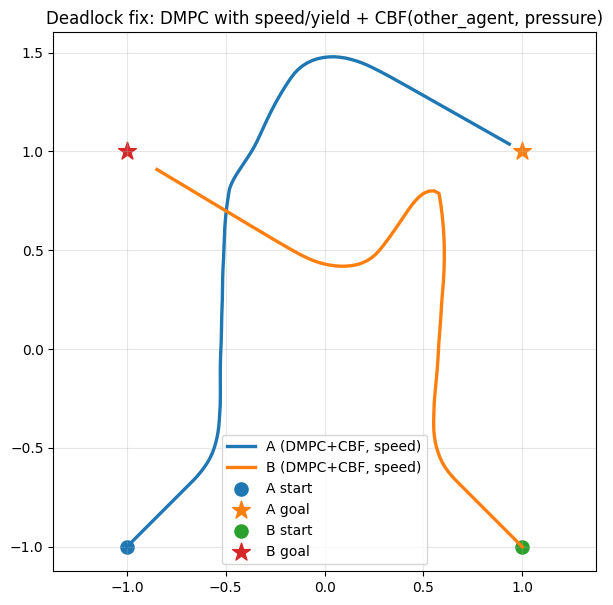

In [22]:
# ===============================================================
# NEW CELL: Fix deadlock (交汇不了/到不了终点)
#   - Add SPEED as a decision variable (yield / wait)
#   - Add a tiny asymmetry (priority) to break perfect symmetry
#   - Keep CBF(other_agent, pressure) for execution safety
# ===============================================================

import numpy as np
import matplotlib.pyplot as plt

# Requires helpers from previous DMPC cells
if "_wrap_pi" not in globals() or "_cbf_step_with_other" not in globals():
    raise RuntimeError("Please run the previous two-car MPC/DMPC cells first.")


def two_car_symmetric_dmpc_with_speed(
    xA0,
    gA,
    xB0,
    gB,
    *,
    dt=0.02,
    vA_max=1.4,
    vB_max=1.4,
    max_total_steps=700,
    goal_tol=0.18,
    H=10,
    heading_span_deg=140.0,
    heading_samples=25,
    speed_scales=(0.0, 0.4, 0.7, 1.0),
    d_safe=1.0,
    # CBF params
    agent_safe_radius=0.55,
    gamma_min=1.0,
    w_p=6.0,
    press_k=1.0,
    press_n=2.0,
    max_corr_norm=10.0,
    device="cpu",
    # costs
    w_goal=18.0,
    w_turn=0.10,
    w_dist_A=70.0,
    w_dist_B=110.0,   # B yields more (break symmetry)
    w_speed=0.6,      # penalize slow motion, but allow it
    heading_smooth=0.35,
    n_best_response_iters=1,
    fast_eval=True,
):
    """Symmetric DMPC that can YIELD (speed_scale=0) to avoid deadlock.

    Why deadlock happened before:
      - both agents had the same cost/constraints (perfect symmetry)
      - only heading was controllable (no slowing/yield)

    Fix:
      - include speed choices in MPC
      - slightly different distance weight (priority) to break symmetry
    """

    xA = np.asarray(xA0, dtype=np.float64).reshape(2).copy()
    xB = np.asarray(xB0, dtype=np.float64).reshape(2).copy()
    gA = np.asarray(gA, dtype=np.float64).reshape(2)
    gB = np.asarray(gB, dtype=np.float64).reshape(2)

    xsA = [xA.copy()]
    xsB = [xB.copy()]

    prev_hA = None
    prev_hB = None
    prev_sA = 1.0
    prev_sB = 1.0

    span = np.deg2rad(float(heading_span_deg))

    def hinge(z):
        return max(0.0, float(z))

    def predict_straight(x0, h, s, v_max, H):
        x = np.asarray(x0, dtype=np.float64).reshape(2).copy()
        traj = [x.copy()]
        v = float(v_max) * float(s)
        vvec = v * np.array([np.cos(h), np.sin(h)], dtype=np.float64)
        for _ in range(int(H)):
            x = x + float(dt) * vvec
            traj.append(x.copy())
        return np.asarray(traj, dtype=np.float64)

    def score_agent(x0, g, other_pred, *, h, s, v_max, w_dist, prev_h):
        x = np.asarray(x0, dtype=np.float64).reshape(2).copy()
        J = 0.0
        for k in range(int(H)):
            v = float(v_max) * float(s)
            v_nom = v * np.array([np.cos(h), np.sin(h)], dtype=np.float64)

            if fast_eval:
                x = x + float(dt) * v_nom
            else:
                v_safe = _cbf_step_with_other(
                    x_now=x,
                    v_nom=v_nom,
                    other_now=other_pred[k],
                    dt=float(dt),
                    device=str(device),
                    agent_safe_radius=float(agent_safe_radius),
                    gamma_min=float(gamma_min),
                    w_p=float(w_p),
                    press_k=float(press_k),
                    press_n=float(press_n),
                    max_corr_norm=float(max_corr_norm),
                )
                x = x + float(dt) * v_safe

            dist_k = float(np.linalg.norm(x - other_pred[k + 1]))
            viol = hinge(float(d_safe) - dist_k)
            J += float(w_dist) * (viol * viol)

        # terminal goal cost (stronger to avoid "stay on the side")
        J += float(w_goal) * float(np.sum((x - g) ** 2))

        # turning continuity
        if prev_h is not None:
            dphi = _wrap_pi(float(h) - float(prev_h))
            J += float(w_turn) * (dphi * dphi)

        # discourage always-yielding
        J += float(w_speed) * float((1.0 - float(s)) ** 2)

        return float(J)

    for step in range(int(max_total_steps)):
        if float(np.linalg.norm(xA - gA)) <= float(goal_tol) and float(np.linalg.norm(xB - gB)) <= float(goal_tol):
            break

        # initialize headings
        hA = float(np.arctan2((gA - xA)[1], (gA - xA)[0]))
        hB = float(np.arctan2((gB - xB)[1], (gB - xB)[0]))
        sA = float(prev_sA)
        sB = float(prev_sB)

        for _ in range(int(max(1, n_best_response_iters))):
            # Predict other straight (fast) using current (h,s)
            predA = predict_straight(xA, hA, sA, vA_max, H)
            predB = predict_straight(xB, hB, sB, vB_max, H)

            # Solve A best response
            baseA = float(np.arctan2((gA - xA)[1], (gA - xA)[0]))
            offsA = np.linspace(-span/2.0, span/2.0, int(heading_samples), dtype=np.float64)
            bestJA, bestHA, bestSA = float("inf"), baseA, 1.0
            for off in offsA:
                cand_h = float(baseA + off)
                for cand_s in speed_scales:
                    JA = score_agent(xA, gA, predB, h=cand_h, s=float(cand_s), v_max=vA_max, w_dist=w_dist_A, prev_h=prev_hA)
                    if JA < bestJA:
                        bestJA, bestHA, bestSA = JA, cand_h, float(cand_s)
            hA, sA = bestHA, bestSA

            # Solve B best response
            baseB = float(np.arctan2((gB - xB)[1], (gB - xB)[0]))
            offsB = np.linspace(-span/2.0, span/2.0, int(heading_samples), dtype=np.float64)
            bestJB, bestHB, bestSB = float("inf"), baseB, 1.0
            for off in offsB:
                cand_h = float(baseB + off)
                for cand_s in speed_scales:
                    JB = score_agent(xB, gB, predA, h=cand_h, s=float(cand_s), v_max=vB_max, w_dist=w_dist_B, prev_h=prev_hB)
                    if JB < bestJB:
                        bestJB, bestHB, bestSB = JB, cand_h, float(cand_s)
            hB, sB = bestHB, bestSB

        # execute one step with smoothing
        if prev_hA is None:
            exec_hA = hA
        else:
            a = float(np.clip(heading_smooth, 0.0, 1.0))
            exec_hA = _wrap_pi(prev_hA + a * _wrap_pi(hA - prev_hA))

        if prev_hB is None:
            exec_hB = hB
        else:
            a = float(np.clip(heading_smooth, 0.0, 1.0))
            exec_hB = _wrap_pi(prev_hB + a * _wrap_pi(hB - prev_hB))

        exec_sA = float(sA)
        exec_sB = float(sB)

        vA_nom = float(vA_max) * exec_sA * np.array([np.cos(exec_hA), np.sin(exec_hA)], dtype=np.float64)
        vB_nom = float(vB_max) * exec_sB * np.array([np.cos(exec_hB), np.sin(exec_hB)], dtype=np.float64)

        vA_safe = _cbf_step_with_other(
            x_now=xA,
            v_nom=vA_nom,
            other_now=xB,
            dt=float(dt),
            device=str(device),
            agent_safe_radius=float(agent_safe_radius),
            gamma_min=float(gamma_min),
            w_p=float(w_p),
            press_k=float(press_k),
            press_n=float(press_n),
            max_corr_norm=float(max_corr_norm),
        )
        vB_safe = _cbf_step_with_other(
            x_now=xB,
            v_nom=vB_nom,
            other_now=xA,
            dt=float(dt),
            device=str(device),
            agent_safe_radius=float(agent_safe_radius),
            gamma_min=float(gamma_min),
            w_p=float(w_p),
            press_k=float(press_k),
            press_n=float(press_n),
            max_corr_norm=float(max_corr_norm),
        )

        xA = xA + float(dt) * vA_safe
        xB = xB + float(dt) * vB_safe
        xsA.append(xA.copy())
        xsB.append(xB.copy())

        prev_hA, prev_hB = exec_hA, exec_hB
        prev_sA, prev_sB = exec_sA, exec_sB

        if step % 50 == 0:
            dAB = float(np.linalg.norm(xA - xB))
            print(f"[step {step:04d}] dAB={dAB:.3f}  sA={exec_sA:.2f} sB={exec_sB:.2f}  |dA|={np.linalg.norm(xA-gA):.3f} |dB|={np.linalg.norm(xB-gB):.3f}")

    return np.asarray(xsA, dtype=np.float64), np.asarray(xsB, dtype=np.float64)


# -------------------------
# Scenario
# -------------------------
xA0 = np.array([-1.0, -1.0], dtype=np.float64)
gA  = np.array([+1.0, +1.0], dtype=np.float64)
xB0 = np.array([+1.0, -1.0], dtype=np.float64)
gB  = np.array([-1.0, +1.0], dtype=np.float64)

xsA_fix, xsB_fix = two_car_symmetric_dmpc_with_speed(
    xA0, gA, xB0, gB,
    dt=0.02,
    vA_max=1.4,
    vB_max=1.4,
    max_total_steps=900,
    H=10,
    heading_samples=25,
    speed_scales=(0.0, 0.4, 0.7, 1.0),
    d_safe=1.0,
    w_goal=18.0,
    w_turn=0.10,
    w_dist_A=70.0,
    w_dist_B=110.0,
    w_speed=0.6,
    heading_smooth=0.35,
    n_best_response_iters=1,
    fast_eval=True,
)

plt.figure(figsize=(7, 7))
plt.plot(xsA_fix[:, 0], xsA_fix[:, 1], "-", linewidth=2.4, label="A (DMPC+CBF, speed)")
plt.plot(xsB_fix[:, 0], xsB_fix[:, 1], "-", linewidth=2.4, label="B (DMPC+CBF, speed)")
plt.scatter([xsA_fix[0, 0]], [xsA_fix[0, 1]], s=90, label="A start")
plt.scatter([gA[0]], [gA[1]], s=180, marker="*", label="A goal")
plt.scatter([xsB_fix[0, 0]], [xsB_fix[0, 1]], s=90, label="B start")
plt.scatter([gB[0]], [gB[1]], s=180, marker="*", label="B goal")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.title("Deadlock fix: DMPC with speed/yield + CBF(other_agent, pressure)")
plt.legend()
plt.show()



[step 0000] overlap=False  sA=1.00 sB=1.00  |dA|=2.800 |dB|=2.800
[step 0060] overlap=False  sA=1.00 sB=1.00  |dA|=1.579 |dB|=1.670
[step 0120] overlap=False  sA=1.00 sB=1.00  |dA|=0.568 |dB|=0.729


NameError: name 'car_L' is not defined

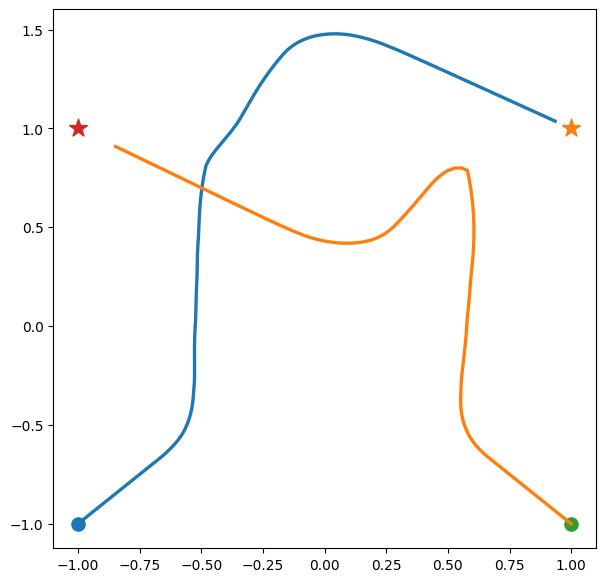

In [ ]:
# ===============================================================
# NEW CELL: Rectangle car footprint (oriented boxes) + DMPC + CBF
#
# - Treat each car as an oriented rectangle (center=(x,y), heading=theta).
# - In the MPC horizon, enforce rectangle-rectangle non-overlap via SAT (hard reject / huge penalty).
# - Execution step still uses your CBF(other_agent, pressure) on centers (fast safety shield).
#
# This is a practical RT-MPC trick for "tight spaces":
#   planning uses a stronger geometric collision model; execution uses a fast safety filter.
# ===============================================================

import numpy as np
import matplotlib.pyplot as plt

if "_wrap_pi" not in globals() or "_cbf_step_with_other" not in globals():
    raise RuntimeError("Please run the previous two-car MPC/DMPC cells first.")


def rect_corners(center_xy, theta, length, width):
    """Return 4 corners (4,2) of an oriented rectangle."""
    c = np.asarray(center_xy, dtype=np.float64).reshape(2)
    th = float(theta)

    hl = 0.5 * float(length)
    hw = 0.5 * float(width)

    # local corners (front/back, left/right)
    local = np.array([
        [+hl, +hw],
        [+hl, -hw],
        [-hl, -hw],
        [-hl, +hw],
    ], dtype=np.float64)

    ct, st = np.cos(th), np.sin(th)
    R = np.array([[ct, -st], [st, ct]], dtype=np.float64)
    world = local @ R.T + c[None, :]
    return world


def _proj_interval(poly_xy, axis):
    """Project polygon vertices onto axis, return (min,max)."""
    p = poly_xy @ axis
    return float(p.min()), float(p.max())


def sat_rect_overlap(c1, th1, L1, W1, c2, th2, L2, W2, margin=0.0):
    """Separating Axis Theorem for two oriented rectangles.

    Returns True if rectangles overlap (with optional inflation margin).
    We implement margin by inflating both rectangles' half-extents.
    """
    L1m, W1m = float(L1) + 2.0 * float(margin), float(W1) + 2.0 * float(margin)
    L2m, W2m = float(L2) + 2.0 * float(margin), float(W2) + 2.0 * float(margin)

    r1 = rect_corners(c1, th1, L1m, W1m)
    r2 = rect_corners(c2, th2, L2m, W2m)

    # axes = normals of edges (2 unique per rectangle)
    def axes_from_rect(r):
        e0 = r[1] - r[0]
        e1 = r[3] - r[0]
        # normals (no need to normalize perfectly, but helps numerics)
        a0 = np.array([ -e0[1], e0[0] ], dtype=np.float64)
        a1 = np.array([ -e1[1], e1[0] ], dtype=np.float64)
        # normalize
        a0 = a0 / (np.linalg.norm(a0) + 1e-12)
        a1 = a1 / (np.linalg.norm(a1) + 1e-12)
        return [a0, a1]

    axes = axes_from_rect(r1) + axes_from_rect(r2)

    for ax in axes:
        a_min, a_max = _proj_interval(r1, ax)
        b_min, b_max = _proj_interval(r2, ax)
        # gap => separated => no overlap
        if a_max < b_min or b_max < a_min:
            return False
    return True


def dmpc_rect_two_car_with_speed(
    xA0, gA,
    xB0, gB,
    *,
    dt=0.02,
    vA_max=1.4,
    vB_max=1.4,
    max_total_steps=800,
    goal_tol=0.18,
    H=10,
    heading_span_deg=140.0,
    heading_samples=25,
    speed_scales=(0.0, 0.4, 0.7, 1.0),
    # rectangle geometry
    car_L=0.60,
    car_W=0.32,
    rect_margin=0.05,   # inflate rectangles for safety
    # distance preference (center)
    d_safe=1.0,
    # CBF params
    agent_safe_radius=0.55,
    gamma_min=1.0,
    w_p=6.0,
    press_k=1.0,
    press_n=2.0,
    max_corr_norm=10.0,
    device="cpu",
    # costs
    w_goal=18.0,
    w_turn=0.10,
    w_dist_A=70.0,
    w_dist_B=110.0,
    w_speed=0.6,
    w_rect=1e6,         # huge penalty for any overlap in horizon
    heading_smooth=0.35,
    n_best_response_iters=1,
    fast_eval=True,
):
    """Two-car DMPC with rectangle footprint collision checking.

    State here is (x,y,theta). We approximate theta as the commanded heading.
    """
    xA = np.asarray(xA0, dtype=np.float64).reshape(2).copy()
    xB = np.asarray(xB0, dtype=np.float64).reshape(2).copy()
    gA = np.asarray(gA, dtype=np.float64).reshape(2)
    gB = np.asarray(gB, dtype=np.float64).reshape(2)

    xsA = [xA.copy()]
    xsB = [xB.copy()]
    thA_hist = []
    thB_hist = []

    prev_hA = None
    prev_hB = None
    prev_sA = 1.0
    prev_sB = 1.0

    span = np.deg2rad(float(heading_span_deg))

    def hinge(z):
        return max(0.0, float(z))

    def predict_straight(center0, h, s, v_max):
        c = np.asarray(center0, dtype=np.float64).reshape(2).copy()
        traj = [c.copy()]
        v = float(v_max) * float(s)
        vvec = v * np.array([np.cos(h), np.sin(h)], dtype=np.float64)
        for _ in range(int(H)):
            c = c + float(dt) * vvec
            traj.append(c.copy())
        return np.asarray(traj, dtype=np.float64)  # (H+1,2)

    def score_agent(center0, goal, other_traj, *, h, s, v_max, w_dist, prev_h, other_heading):
        c = np.asarray(center0, dtype=np.float64).reshape(2).copy()
        J = 0.0

        for k in range(int(H)):
            v = float(v_max) * float(s)
            v_nom = v * np.array([np.cos(h), np.sin(h)], dtype=np.float64)

            # fast_eval: straight kinematics
            c = c + float(dt) * v_nom

            # 1) rectangle overlap check at step k+1
            #    ego heading = h, other heading = other_heading
            if sat_rect_overlap(
                c1=c, th1=h, L1=car_L, W1=car_W,
                c2=other_traj[k + 1], th2=other_heading, L2=car_L, W2=car_W,
                margin=float(rect_margin),
            ):
                J += float(w_rect)

            # 2) center distance soft constraint
            dist_k = float(np.linalg.norm(c - other_traj[k + 1]))
            viol = hinge(float(d_safe) - dist_k)
            J += float(w_dist) * (viol * viol)

        # goal cost
        J += float(w_goal) * float(np.sum((c - goal) ** 2))

        if prev_h is not None:
            dphi = _wrap_pi(float(h) - float(prev_h))
            J += float(w_turn) * (dphi * dphi)

        J += float(w_speed) * float((1.0 - float(s)) ** 2)

        return float(J)

    for step in range(int(max_total_steps)):
        if float(np.linalg.norm(xA - gA)) <= float(goal_tol) and float(np.linalg.norm(xB - gB)) <= float(goal_tol):
            break

        # init
        hA = float(np.arctan2((gA - xA)[1], (gA - xA)[0]))
        hB = float(np.arctan2((gB - xB)[1], (gB - xB)[0]))
        sA = float(prev_sA)
        sB = float(prev_sB)

        for _ in range(int(max(1, n_best_response_iters))):
            predA = predict_straight(xA, hA, sA, vA_max)
            predB = predict_straight(xB, hB, sB, vB_max)

            # A best response (assume other heading = hB during horizon)
            baseA = float(np.arctan2((gA - xA)[1], (gA - xA)[0]))
            offsA = np.linspace(-span/2.0, span/2.0, int(heading_samples), dtype=np.float64)
            bestJA, bestHA, bestSA = float("inf"), baseA, 1.0
            for off in offsA:
                cand_h = float(baseA + off)
                for cand_s in speed_scales:
                    JA = score_agent(
                        xA, gA, predB,
                        h=cand_h, s=float(cand_s), v_max=vA_max,
                        w_dist=w_dist_A, prev_h=prev_hA,
                        other_heading=hB,
                    )
                    if JA < bestJA:
                        bestJA, bestHA, bestSA = JA, cand_h, float(cand_s)
            hA, sA = bestHA, bestSA

            # B best response (assume other heading = hA during horizon)
            baseB = float(np.arctan2((gB - xB)[1], (gB - xB)[0]))
            offsB = np.linspace(-span/2.0, span/2.0, int(heading_samples), dtype=np.float64)
            bestJB, bestHB, bestSB = float("inf"), baseB, 1.0
            for off in offsB:
                cand_h = float(baseB + off)
                for cand_s in speed_scales:
                    JB = score_agent(
                        xB, gB, predA,
                        h=cand_h, s=float(cand_s), v_max=vB_max,
                        w_dist=w_dist_B, prev_h=prev_hB,
                        other_heading=hA,
                    )
                    if JB < bestJB:
                        bestJB, bestHB, bestSB = JB, cand_h, float(cand_s)
            hB, sB = bestHB, bestSB

        # execute one step with heading smoothing
        if prev_hA is None:
            exec_hA = hA
        else:
            a = float(np.clip(heading_smooth, 0.0, 1.0))
            exec_hA = _wrap_pi(prev_hA + a * _wrap_pi(hA - prev_hA))

        if prev_hB is None:
            exec_hB = hB
        else:
            a = float(np.clip(heading_smooth, 0.0, 1.0))
            exec_hB = _wrap_pi(prev_hB + a * _wrap_pi(hB - prev_hB))

        exec_sA = float(sA)
        exec_sB = float(sB)

        vA_nom = float(vA_max) * exec_sA * np.array([np.cos(exec_hA), np.sin(exec_hA)], dtype=np.float64)
        vB_nom = float(vB_max) * exec_sB * np.array([np.cos(exec_hB), np.sin(exec_hB)], dtype=np.float64)

        # CBF safety on centers
        vA_safe = _cbf_step_with_other(
            x_now=xA,
            v_nom=vA_nom,
            other_now=xB,
            dt=float(dt),
            device=str(device),
            agent_safe_radius=float(agent_safe_radius),
            gamma_min=float(gamma_min),
            w_p=float(w_p),
            press_k=float(press_k),
            press_n=float(press_n),
            max_corr_norm=float(max_corr_norm),
        )
        vB_safe = _cbf_step_with_other(
            x_now=xB,
            v_nom=vB_nom,
            other_now=xA,
            dt=float(dt),
            device=str(device),
            agent_safe_radius=float(agent_safe_radius),
            gamma_min=float(gamma_min),
            w_p=float(w_p),
            press_k=float(press_k),
            press_n=float(press_n),
            max_corr_norm=float(max_corr_norm),
        )

        xA = xA + float(dt) * vA_safe
        xB = xB + float(dt) * vB_safe

        xsA.append(xA.copy())
        xsB.append(xB.copy())
        thA_hist.append(exec_hA)
        thB_hist.append(exec_hB)

        prev_hA, prev_hB = exec_hA, exec_hB
        prev_sA, prev_sB = exec_sA, exec_sB

        if step % 60 == 0:
            overlap_now = sat_rect_overlap(xA, exec_hA, car_L, car_W, xB, exec_hB, car_L, car_W, margin=rect_margin)
            print(f"[step {step:04d}] overlap={overlap_now}  sA={exec_sA:.2f} sB={exec_sB:.2f}  |dA|={np.linalg.norm(xA-gA):.3f} |dB|={np.linalg.norm(xB-gB):.3f}")

    # include headings so rectangle visualization can be exact
    thA = np.asarray(thA_hist, dtype=np.float64)
    thB = np.asarray(thB_hist, dtype=np.float64)
    return np.asarray(xsA, dtype=np.float64), np.asarray(xsB, dtype=np.float64), thA, thB


# -------------------------
# Scenario
# -------------------------
xA0 = np.array([-1.0, -1.0], dtype=np.float64)
gA  = np.array([+1.0, +1.0], dtype=np.float64)
xB0 = np.array([+1.0, -1.0], dtype=np.float64)
gB  = np.array([-1.0, +1.0], dtype=np.float64)

xsA_rect, xsB_rect, thA_rect, thB_rect = dmpc_rect_two_car_with_speed(
    xA0, gA, xB0, gB,
    dt=0.02,
    vA_max=1.4,
    vB_max=1.4,
    H=10,
    heading_samples=25,
    speed_scales=(0.0, 0.4, 0.7, 1.0),
    car_L=0.60,
    car_W=0.32,
    rect_margin=0.06,
    d_safe=1.0,
    w_goal=18.0,
    w_dist_A=70.0,
    w_dist_B=110.0,
    w_rect=1e6,
    heading_smooth=0.35,
    fast_eval=True,
)

# plot centers + draw rectangle footprints
from matplotlib.patches import Polygon

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(xsA_rect[:, 0], xsA_rect[:, 1], "-", linewidth=2.4, label="A center")
ax.plot(xsB_rect[:, 0], xsB_rect[:, 1], "-", linewidth=2.4, label="B center")
ax.scatter([xsA_rect[0, 0]], [xsA_rect[0, 1]], s=90, label="A start")
ax.scatter([gA[0]], [gA[1]], s=180, marker="*", label="A goal")
ax.scatter([xsB_rect[0, 0]], [xsB_rect[0, 1]], s=90, label="B start")
ax.scatter([gB[0]], [gB[1]], s=180, marker="*", label="B goal")


def _draw_rect(ax, center, theta, L, W, *, edgecolor, facecolor, alpha=0.12, lw=1.5):
    corners = rect_corners(center, theta, L, W)  # (4,2)
    poly = Polygon(corners, closed=True, edgecolor=edgecolor, facecolor=facecolor, alpha=alpha, lw=lw)
    ax.add_patch(poly)

# If you want denser rectangles, decrease this number
DRAW_EVERY = 60
idxs = list(range(0, len(xsA_rect), int(DRAW_EVERY)))
if (len(xsA_rect) - 1) not in idxs:
    idxs.append(len(xsA_rect) - 1)

# thA_rect/thB_rect are recorded for executed steps 0..T-2 (because they are applied each step)
# Align them to center arrays length by clamping index.
for i in idxs:
    ia = min(int(i), len(thA_rect) - 1)
    ib = min(int(i), len(thB_rect) - 1)
    _draw_rect(ax, xsA_rect[i], thA_rect[ia], car_L, car_W, edgecolor="C0", facecolor="C0", alpha=0.10, lw=1.3)
    _draw_rect(ax, xsB_rect[i], thB_rect[ib], car_L, car_W, edgecolor="C1", facecolor="C1", alpha=0.10, lw=1.3)

ax.axis("equal")
ax.grid(True, alpha=0.3)
ax.set_title("Rectangle cars (SAT) + DMPC(speed/yield) + CBF(center)\n(rectangles shown every %d steps)" % int(DRAW_EVERY))
ax.legend()
plt.show()



[step 000] dist=2.500 v=0.313 rej=00/30 fb=N u=[+0.631,-1.529]
[step 001] dist=2.483 v=0.378 rej=00/30 fb=N u=[+0.654,-1.806]
[step 002] dist=2.461 v=0.449 rej=00/30 fb=N u=[+0.702,-1.484]
[step 003] dist=2.435 v=0.505 rej=00/30 fb=N u=[+0.562,-0.530]
[step 004] dist=2.404 v=0.561 rej=00/30 fb=N u=[+0.560,+0.314]
[step 010] dist=2.110 v=0.935 rej=00/30 fb=N u=[+0.628,-0.268]
[step 020] dist=1.138 v=0.942 rej=00/30 fb=N u=[-0.788,+0.345]
[step 030] dist=0.446 v=0.351 rej=00/30 fb=N u=[-0.469,-0.009]
[step 040] dist=0.159 v=0.250 rej=00/30 fb=N u=[-0.036,+0.143]
Done. steps=41, fallback_count=0, total_reject=0


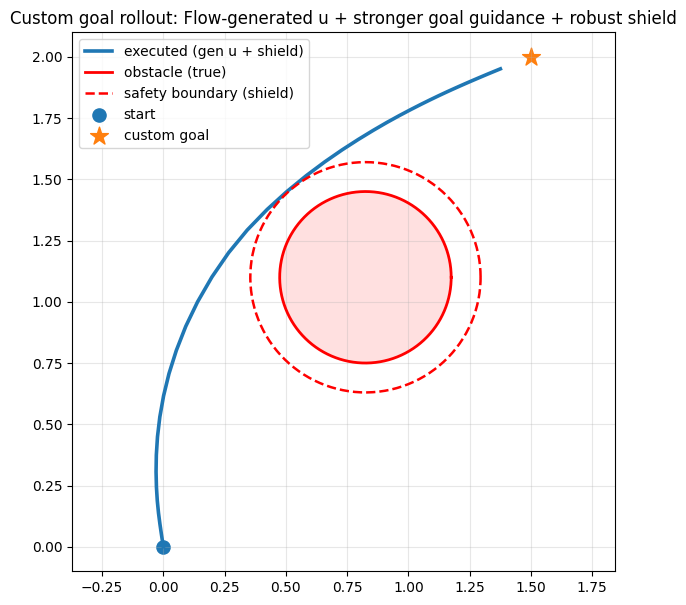

In [ ]:
# ===============================================================
# Cell (fixed): Custom goal + receding-horizon u sampling + shield + bicycle rollout
#   - model_u generates u_seq ~ p(u_seq | cond)
#   - execute only u0 each step
#   - external goal guidance
#   - obstacle safety: resample u0 until safe; fallback = "keep moving + turn away"
# ===============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt


def circle_h(xy, c, R):
    d = np.asarray(xy, dtype=np.float64) - np.asarray(c, dtype=np.float64)
    return float(d @ d - R * R)


@torch.no_grad()
# 用你训练好的 flow matching UNet，
# 从噪声中“生成一整段控制序列 但在 receding-horizon 控制里 只执行第一个控制 u0


def sample_u0_from_model(model_u, cond_vec, ctrl_T, n_steps=40, device="cpu", noise_scale=1.0):
    """Sample a whole u_seq, return first control u0=[a,delta_rate]."""
    dev = torch.device(device)
    cond = torch.as_tensor(cond_vec, dtype=torch.float32, device=dev).view(1, -1)

    x = torch.randn(1, 2, int(ctrl_T), device=dev) * float(noise_scale)
    t_grid = torch.linspace(0.0, 1.0, int(n_steps) + 1, device=dev)

    for i in range(int(n_steps)):
        t = t_grid[i].view(1)
        v = model_u(x, t, cond=cond)

        # align length if cropped
        if v.shape[-1] != x.shape[-1]:
            Lmin = min(v.shape[-1], x.shape[-1])
            v = v[..., :Lmin]
            x = x[..., :Lmin]

        dt_local = float(t_grid[i+1] - t_grid[i])
        x = x + dt_local * v

    u_seq = x[0].detach().cpu().numpy().astype(np.float64)  # (2, ctrl_T)
    u0 = u_seq[:, 0].copy()
    return u0


def rollout_custom_goal_with_shield(
    *,
    model_u,
    init_state5,           # [x,y,theta,v,delta]
    goal_xy,               # custom goal
    obstacle_center,       # circle center
    obstacle_radius,       # true obstacle R
    safety_margin=0.12,    # safety inflation
    ctrl_T=59,
    dt=0.1,
    L=0.8,
    delta_max=np.deg2rad(30.0),
    a_max=0.8,
    delta_rate_max=np.deg2rad(120.0),
    max_steps=160,
    goal_tol=0.15,
    # sampling
    n_steps_sample=50,
    resample_tries=25,
    noise_scale=1.0,
    # goal guidance
    k_goal_steer=2.2,
    k_goal_speed=0.8,
    # stability
    v_floor=0.25,          # ✅ 防止速度塌陷（关键）
    # blend
    mix_guidance=0.85,     # ✅ guidance 权重大（关键）
    device="cpu",
    debug_every=10,
):
    goal_xy = np.asarray(goal_xy, dtype=np.float64).reshape(2)
    c = np.asarray(obstacle_center, dtype=np.float64).reshape(2)
    R_safe = float(obstacle_radius) + float(safety_margin)

    state = np.asarray(init_state5, dtype=np.float64).copy()
    # ✅ 确保初始速度不为 0，否则一开始就容易卡
    state[3] = max(float(state[3]), float(v_floor))

    xs = [state[:2].copy()]
    fallback_count = 0
    total_reject = 0

    for step in range(int(max_steps)):
        dist = float(np.linalg.norm(state[:2] - goal_xy))
        if dist <= float(goal_tol):
            break

        cond_vec = state[:5].copy()

        # -------- goal guidance (external) --------
        vec = goal_xy - state[:2]
        th_goal = float(np.arctan2(vec[1], vec[0]))
        e_th = float((th_goal - state[2] + np.pi) % (2*np.pi) - np.pi)

        v_eff = max(float(v_floor), float(state[3]))
        omega_des = float(k_goal_steer) * e_th
        delta_des = float(np.arctan2(omega_des * float(L), v_eff))
        delta_des = float(np.clip(delta_des, -float(delta_max), float(delta_max)))

        delta_rate_g = (delta_des - float(state[4])) / float(dt)
        delta_rate_g = float(np.clip(delta_rate_g, -float(delta_rate_max), float(delta_rate_max)))

        v_des = float(np.clip(float(k_goal_speed) * dist, float(v_floor), 1.2))
        a_g = (v_des - float(state[3])) / float(dt)
        a_g = float(np.clip(a_g, -float(a_max), float(a_max)))

        u_guidance = np.array([a_g, delta_rate_g], dtype=np.float64)

        # -------- rejection shield w/ adaptive noise --------
        u_safe = None
        local_reject = 0

        for j in range(int(resample_tries)):
            # ✅ 越失败，噪声越大（更容易跳出坏模式）
            ns = float(noise_scale) * (1.0 + 0.08 * j)

            u0 = sample_u0_from_model(
                model_u, cond_vec, ctrl_T=ctrl_T,
                n_steps=n_steps_sample, device=device, noise_scale=ns
            )

            # clip model output
            u0[0] = float(np.clip(u0[0], -a_max, a_max))
            u0[1] = float(np.clip(u0[1], -delta_rate_max, delta_rate_max))

            # ✅ 更强 guidance 混合（核心改动）
            mix = float(np.clip(mix_guidance, 0.0, 1.0))
            u0 = (1.0 - mix) * u0 + mix * u_guidance

            u0_clip = np.array([
                float(np.clip(u0[0], -a_max, a_max)),
                float(np.clip(u0[1], -delta_rate_max, delta_rate_max)),
            ], dtype=np.float64)

            nxt = _step_bicycle_simple(state, u0_clip, dt=float(dt), L=float(L), delta_max=float(delta_max))

            if circle_h(nxt[:2], c, R_safe) >= 0.0:
                u_safe = u0_clip
                break
            else:
                local_reject += 1

        total_reject += local_reject

        if u_safe is None:
            # ✅ fallback 不要“刹死”，否则 v 会掉到 0 然后再也动不了
            # 策略：轻刹/保持 + 朝 goal 转向（甚至稍微偏转绕开）
            fallback_count += 1

            a_fb = float(np.clip(-0.2 * a_max, -a_max, a_max))  # 轻刹
            # turn harder towards goal when stuck
            delta_rate_fb = float(np.clip(1.0 * delta_rate_g, -delta_rate_max, delta_rate_max))

            u_safe = np.array([a_fb, delta_rate_fb], dtype=np.float64)

        # execute
        state = _step_bicycle_simple(state, u_safe, dt=float(dt), L=float(L), delta_max=float(delta_max))

        # ✅ 再次防止速度塌陷
        state[3] = max(float(state[3]), float(v_floor))

        xs.append(state[:2].copy())

        if (debug_every is not None) and (step % int(debug_every) == 0 or step < 5):
            print(f"[step {step:03d}] dist={dist:.3f} v={state[3]:.3f} "
                  f"rej={local_reject:02d}/{resample_tries} fb={'Y' if local_reject==resample_tries else 'N'} "
                  f"u=[{u_safe[0]:+.3f},{u_safe[1]:+.3f}]")

    print(f"Done. steps={len(xs)-1}, fallback_count={fallback_count}, total_reject={total_reject}")
    return np.asarray(xs, dtype=np.float64), R_safe


# ------------------ RUN DEMO ------------------
idx = 0
s0 = states_np[idx, 0].astype(np.float64)   # [x,y,theta,v,delta]

goal_xy = np.array([1.5, 2.0], dtype=np.float64)

# obstacle between start and goal
start_xy = s0[:2]
mid = start_xy + 0.55 * (goal_xy - start_xy)
obstacle_center = (float(mid[0]), float(mid[1]))

R_obs = 0.35
margin = 0.12

xs, R_safe = rollout_custom_goal_with_shield(
    model_u=model_u,
    init_state5=s0,
    goal_xy=goal_xy,
    obstacle_center=obstacle_center,
    obstacle_radius=R_obs,
    safety_margin=margin,
    ctrl_T=CTRL_T,
    dt=float(data["params"]["dt"]),
    L=float(data["params"]["L"]),
    delta_max=float(data["params"]["delta_max"]),
    a_max=float(data["params"]["a_max"]),
    delta_rate_max=float(data["params"]["delta_rate_max"]),
    max_steps=220,
    goal_tol=0.15,
    n_steps_sample=60,
    resample_tries=30,
    noise_scale=1.0,
    mix_guidance=0.85,   # ✅ 强 guidance
    v_floor=0.25,        # ✅ 防止卡死
    device=device,
    debug_every=10,
)

# plot
t = np.linspace(0, 2*np.pi, 360)
plt.figure(figsize=(7,7))
plt.plot(xs[:,0], xs[:,1], "-", linewidth=2.6, label="executed (gen u + shield)")

c = np.asarray(obstacle_center, dtype=np.float64)
plt.plot(c[0] + R_obs*np.cos(t), c[1] + R_obs*np.sin(t), "r-", linewidth=2.0, label="obstacle (true)")
plt.fill(c[0] + R_obs*np.cos(t), c[1] + R_obs*np.sin(t), color="red", alpha=0.12)
plt.plot(c[0] + R_safe*np.cos(t), c[1] + R_safe*np.sin(t), "r--", linewidth=1.8, label="safety boundary (shield)")

plt.scatter([xs[0,0]], [xs[0,1]], s=90, label="start")
plt.scatter([goal_xy[0]], [goal_xy[1]], s=180, marker="*", label="custom goal")

plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.title("Custom goal rollout: Flow-generated u + stronger goal guidance + robust shield")
plt.legend()
plt.show()


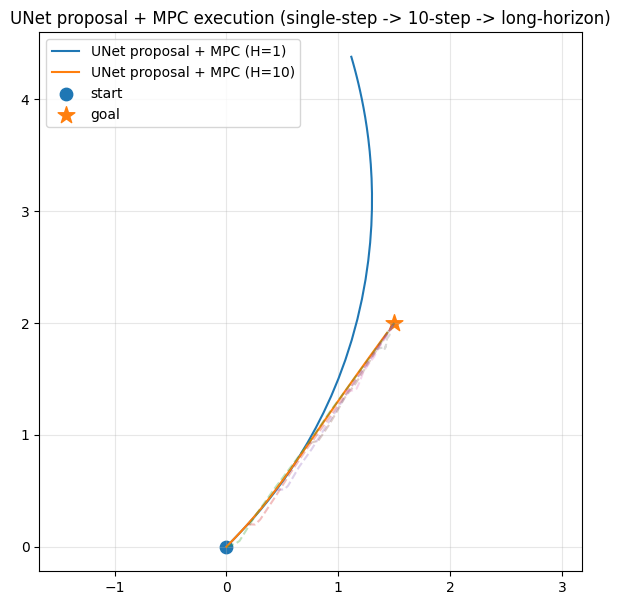

In [ ]:
# =========================
# UNet proposal policy + MPC execution (single-step -> 10-step -> long-horizon)
#
# Idea (as your advisor suggested):
#   - Use the trained UNet (stage-1) to PROPOSE a short reference (H steps) from current state.
#   - Use MPC to EXECUTE one feasible/smooth step toward that proposal (and still respect goal).
#   - Repeat (receding horizon) to get long-horizon rollout.
#
# This cell only adds new code. It does NOT change your training dataset.
# =========================

import numpy as np
import inspect
import torch
import torch.nn as nn

#UNet 生成的轨迹长度可能是 UNET_T（比如 50/100），但你每一步只想用 H+1（比如 2 或 11） 个点作为短期参考
#把一条二维轨迹（折线）按“时间比例”重新采样成指定长度
def _resample_polyline_xy(xy_T2: np.ndarray, out_len: int) -> np.ndarray:
    """Resample a (T,2) polyline to length out_len using linear interpolation in normalized time."""
    xy_T2 = np.asarray(xy_T2, dtype=np.float64)
    T = xy_T2.shape[0]
    if T == out_len:
        return xy_T2
    t_in = np.linspace(0.0, 1.0, T)
    t_out = np.linspace(0.0, 1.0, out_len)
    x_out = np.interp(t_out, t_in, xy_T2[:, 0])
    y_out = np.interp(t_out, t_in, xy_T2[:, 1])
    return np.stack([x_out, y_out], axis=1)


#把一条参考轨迹的后半段“逐渐拉向 goal”，并强制最后一个点等于 goal
def blend_to_goal_simple(ref_xy: np.ndarray, goal_xy: np.ndarray, start_frac: float = 0.3, strength: float = 0.95) -> np.ndarray:
    """Blend a reference path toward a goal (softly) from some fraction onward."""
    ref = np.asarray(ref_xy, dtype=np.float64) #原始参考轨迹
    goal = np.asarray(goal_xy, dtype=np.float64).reshape(2) #目标点

    T = ref.shape[0]
    k0 = int(np.clip(start_frac, 0.0, 1.0) * (T - 1))  #计算起始索引从k0开始 做凸组合的线性插值

    out = ref.copy()
    for k in range(k0, T):
        alpha = strength * float(k - k0) / max(1, (T - 1 - k0))
        alpha = float(np.clip(alpha, 0.0, strength))
        out[k] = (1.0 - alpha) * out[k] + alpha * goal

    # force last point closer to goal
    out[-1] = goal
    return out

#生成短期参考轨迹
def unet_propose_ref_single_or_k_step(
    state4_or_5: np.ndarray, #当前车辆状态
    goal_xy: np.ndarray, #保证末端朝goal收敛
    *,
    H: int = 1,
    device: str = None,
    n_ode_steps: int = 30,
    blend_strength: float = 0.95,
    blend_start_frac: float = 0.2,
) -> np.ndarray:
    """Use the trained UNet to propose a short reference of length (H+1) in WORLD frame.

    Requirements in globals:
      - model: trained UNet-like model
      - sample_traj_from_theta(theta, ...) returning traj as (2,T)

    The UNet in this notebook is angle-conditioned by (cosθ, sinθ). We use current theta.
    """
    def _find_stage1_unet_from_globals():
        # common names first
        for name in (
            "model",
            "model_stage1",
            "stage1_model",
            "unet",
            "unet_model",
            "net",
        ):
            v = globals().get(name, None)
            if isinstance(v, nn.Module):
                return v

        # then search any nn.Module whose class name hints it's a UNet
        for k, v in globals().items():
            if isinstance(v, nn.Module):
                cname = v.__class__.__name__.lower()
                if "simpleunet1d" in cname or ("unet" in cname and "encoder" not in cname):
                    return v

        raise RuntimeError(
            "Stage-1 UNet model not found in globals. "
            "Please run the SimpleUNet1D training cell (the one that creates the model instance)."
        )
    #欧拉采样 一步步把Flow matching网络训练得到的速度一步一步推理得到现有的轨迹
    def _sample_traj_from_theta_fallback(model_stage1, theta, T_traj, n_steps, device):
        """Fallback Euler sampler for the stage-1 flow model. Returns (2,T)."""
        model_stage1.eval()
        dev = torch.device(device)
        cond = torch.tensor([[np.cos(theta), np.sin(theta)]], dtype=torch.float32, device=dev)
        x = torch.randn(1, 2, int(T_traj), device=dev) * 0.1
        t_vals = torch.linspace(0.0, 1.0, int(n_steps) + 1, device=dev)

        for i in range(int(n_steps)):
            t = t_vals[i].view(1)
            try:
                v = model_stage1(x, t, cond=cond)
            except TypeError:
                v = model_stage1(x, t, cond)
            dt_local = float(t_vals[i + 1] - t_vals[i])
            x = x + dt_local * v #主要的欧拉推理部分

        traj = x[0].detach().cpu().numpy()  # (2,T)
        return traj

    model_stage1 = _find_stage1_unet_from_globals()
    sampler = globals().get("sample_traj_from_theta", None)

    s = np.asarray(state4_or_5, dtype=np.float64)
    x, y, theta = float(s[0]), float(s[1]), float(s[2])

    # choose a sampling length: use UNET_T if exists, else fallback to something safe
    T_traj = int(globals().get("UNET_T", max(50, H + 1)))

    # device fallback
    if device is None:
        device = globals().get("device", "cpu")

    # sample proposal trajectory
    if sampler is None:
        traj_2T = _sample_traj_from_theta_fallback(
            model_stage1,
            theta=float(theta),
            T_traj=T_traj,
            n_steps=int(n_ode_steps),
            device=str(device),
        )
    else:
        # support both sampler(model=..., ...) and sampler(model, ...)
        try:
            traj_2T = sampler(
                model=model_stage1,
                theta=float(theta),
                T_traj=T_traj,
                n_steps=int(n_ode_steps),
                device=str(device),
            )
        except TypeError:
            traj_2T = sampler(
                model_stage1,
                theta=float(theta),
                T_traj=T_traj,
                n_steps=int(n_ode_steps),
                device=str(device),
            )
    # (2,T)

    ref = np.asarray(traj_2T, dtype=np.float64).T  # (T,2)

    # translate to current position (treat UNet output as in world frame with origin at 0)
    ref = ref - ref[0:1] + np.array([x, y], dtype=np.float64)

    # blend to goal and resample to H+1
    ref = blend_to_goal_simple(ref, goal_xy, start_frac=float(blend_start_frac), strength=float(blend_strength))
    ref_h = _resample_polyline_xy(ref, out_len=int(H) + 1)
    return ref_h #MPC 每一步要跟踪的短期参考轨迹


# Export a stable alias to this UNet-based proposer (so later overrides can call it safely).
unet_propose_ref_unet_impl = unet_propose_ref_single_or_k_step



def mpc_one_step_track_ref(
    state5: np.ndarray,
    ref_xy: np.ndarray,
    goal_xy: np.ndarray,
    *,
    dt: float,
    L: float,
    delta_max: float,
    a_max: float,
    delta_rate_max: float,
    horizon: int,
    u_last_applied: np.ndarray | None = None,
) -> tuple[np.ndarray, np.ndarray]: 
    """Solve ONE MPC step to track ref_xy (len = horizon+1) and return (next_state5, u0)."""
    # IMPORTANT:
    # - Use ref length as the true MPC horizon (lets H=1 still pass a longer straight-line ref).
    # - Pass u_last_applied so the Δu penalty is relative to the *real* previous control.
    horizon_eff = int(np.asarray(ref_xy).shape[0] - 1) #Unet的步数H-1

    # Call MPC with backward-compat: older kernels may have an older mpc_track_ref_to_goal signature.
    sig = inspect.signature(mpc_track_ref_to_goal) 

    kwargs = dict(
        x0_state5=np.asarray(state5, dtype=np.float64),
        ref_xy=np.asarray(ref_xy, dtype=np.float64),
        goal_xy=np.asarray(goal_xy, dtype=np.float64),
        dt=float(dt),
        L=float(L),
        delta_max=float(delta_max),
        a_max=float(a_max),
        delta_rate_max=float(delta_rate_max),
        horizon=horizon_eff,
        max_steps=1,
        goal_tol=0.15,
        stop_at_goal=False,
        # weights
        w_track=120.0,
        w_goal_stage=60.0,
        w_goal_terminal=4000.0,
        w_goal_barrier=20000.0,
        w_u=0.05,
        w_delta=0.15,
        w_du=0.5,
        tau_track=float(max(1.0, horizon_eff)),
        warm_start=True,
    )

    if "u_last_applied_init" in sig.parameters:
        kwargs["u_last_applied_init"] = (
            np.zeros(2, dtype=np.float64)
            if u_last_applied is None
            else np.asarray(u_last_applied, dtype=np.float64)
        )

    states_mpc, ctrls_mpc = mpc_track_ref_to_goal(**kwargs)

    next_state = np.asarray(states_mpc[-1], dtype=np.float64)
    u0 = np.asarray(ctrls_mpc[0], dtype=np.float64) if ctrls_mpc.shape[0] > 0 else np.zeros(2, dtype=np.float64)
    return next_state, u0


def rollout_unet_proposal_mpc(
    x0_state5: np.ndarray,
    goal_xy: np.ndarray,
    *,
    H: int = 10,
    max_total_steps: int = 200,
    goal_tol: float = 0.15,
    dt: float = 0.05,
    L: float = 2.5,
    delta_max: float = np.deg2rad(30.0),
    a_max: float = 3.0,
    delta_rate_max: float = np.deg2rad(120.0),
    n_ode_steps: int = 30,
    device: str = None,
) -> tuple[np.ndarray, np.ndarray, list[np.ndarray]]:
    """Long-horizon rollout:

    - Proposal: UNet generates a short ref of length H+1 each step.
    - Execution: MPC solves one-step control to track that ref.

    Returns: (states, controls, refs_list)
    """
    state = np.asarray(x0_state5, dtype=np.float64).copy()
    goal = np.asarray(goal_xy, dtype=np.float64).reshape(2)

    states = [state.copy()]
    ctrls = []
    refs_list = []

    u_last = np.zeros(2, dtype=np.float64)

    for _ in range(int(max_total_steps)):
        if float(np.linalg.norm(state[:2] - goal)) <= float(goal_tol):
            break

        # 1) UNet proposal (H-step)
        ref_h = unet_propose_ref_single_or_k_step(
            state,
            goal,
            H=int(H),
            device=device,
            n_ode_steps=int(n_ode_steps),
            blend_strength=0.95,
            blend_start_frac=0.2,
        )
        refs_list.append(ref_h)

        # 2) MPC execution (one step)
        next_state, u0 = mpc_one_step_track_ref(
            state,
            ref_h,
            goal,
            dt=dt,
            L=L,
            delta_max=delta_max,
            a_max=a_max,
            delta_rate_max=delta_rate_max,
            horizon=int(H),
            u_last_applied=u_last,
        )

        state = next_state
        states.append(state.copy())
        ctrls.append(u0.copy())
        u_last = np.asarray(u0, dtype=np.float64)

    return np.asarray(states, dtype=np.float64), np.asarray(ctrls, dtype=np.float64), refs_list


# -------------------------
# Demo: single-step (H=1) vs 10-step (H=10) proposal+MPC
# -------------------------
# NOTE: This demo assumes you've already trained the UNet and created `mpc_track_ref_to_goal` (cell 13).

# Example start/goal (adjust as needed)
goal_xy = np.array([1.5, 2.0], dtype=np.float64)
state0 = np.array([0.0, 0.0, 0.8, 1.0, 0.0], dtype=np.float64)  # [x,y,theta,v,delta]

states_H1, _, _ = rollout_unet_proposal_mpc(state0, goal_xy, H=1, max_total_steps=80, dt=0.05, L=2.5, a_max=3.0)
states_H10, _, refs10 = rollout_unet_proposal_mpc(state0, goal_xy, H=10, max_total_steps=120, dt=0.05, L=2.5, a_max=3.0)

plt.figure(figsize=(7, 7))
plt.plot(states_H1[:, 0], states_H1[:, 1], "-", label="UNet proposal + MPC (H=1)")
plt.plot(states_H10[:, 0], states_H10[:, 1], "-", label="UNet proposal + MPC (H=10)")

# plot a few proposed refs for H=10
for r in refs10[::max(1, len(refs10)//5)]:
    plt.plot(r[:, 0], r[:, 1], "--", alpha=0.3)

plt.scatter([state0[0]], [state0[1]], s=80, label="start")
plt.scatter([goal_xy[0]], [goal_xy[1]], s=160, marker="*", label="goal")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.title("UNet proposal + MPC execution (single-step -> 10-step -> long-horizon)")
plt.legend()
plt.show()



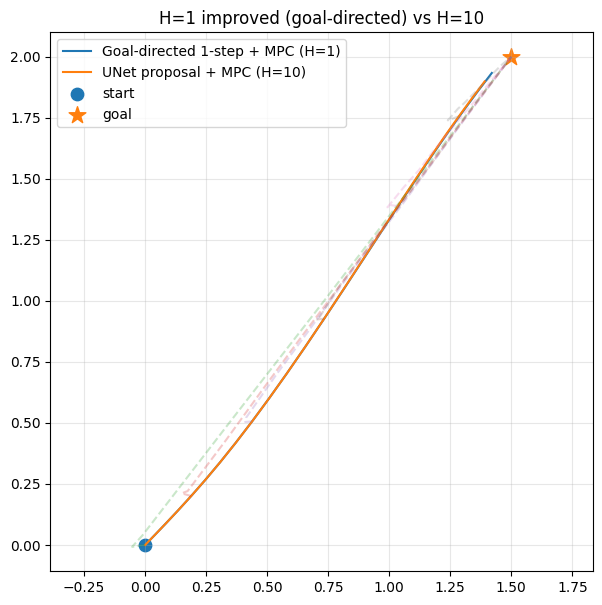

In [33]:
# =========================
# Make H=1 (single-step) proposal more goal-directed
#
# For H=1, using a stochastic UNet sample can cause drift/odd turns.
# Here we override only the H=1 proposal to be a simple goal-directed one-step reference.
# H>1 keeps using the original UNet proposal.
# =========================

import numpy as np

# keep a stable UNet-based proposer (exported by the UNet+MPC cell)
_unet_propose_ref_unet = globals().get("unet_propose_ref_unet_impl", None)
if _unet_propose_ref_unet is None:
    raise RuntimeError(
        "`unet_propose_ref_unet_impl` not found. Please re-run the UNet proposal + MPC cell first."
    )


def unet_propose_ref_single_or_k_step(
    state4_or_5: np.ndarray,
    goal_xy: np.ndarray,
    *,
    H: int = 1,
    device: str = None,
    n_ode_steps: int = 30,
    blend_strength: float = 0.95,
    blend_start_frac: float = 0.2,
    # new knobs for H=1
    step_len: float = 0.35,
) -> np.ndarray:
    """Goal-biased override for H=1; fallback to UNet proposal for H>1."""
    if int(H) == 1:
        # Give MPC a short straight-line reference of length (H_exec+1)
        # so execution is not purely myopic.
        H_exec = 10
        s = np.asarray(state4_or_5, dtype=np.float64)
        x, y = float(s[0]), float(s[1])
        g = np.asarray(goal_xy, dtype=np.float64).reshape(2)
        d = g - np.array([x, y], dtype=np.float64)
        dist = float(np.linalg.norm(d) + 1e-8)
        direction = d / dist

        p0 = np.array([x, y], dtype=np.float64)
        pts = [p0]
        for k in range(1, H_exec + 1):
            step = float(min(step_len * k, dist))
            pts.append(p0 + step * direction)
        return np.stack(pts, axis=0)  # (H_exec+1,2)

    return _unet_propose_ref_unet(
        state4_or_5,
        goal_xy,
        H=int(H),
        device=device,
        n_ode_steps=int(n_ode_steps),
        blend_strength=float(blend_strength),
        blend_start_frac=float(blend_start_frac),
    )


# -------------------------
# Quick re-run demo
# -------------------------
goal_xy = np.array([1.5, 2.0], dtype=np.float64)
state0 = np.array([0.0, 0.0, 0.8, 1.0, 0.0], dtype=np.float64)

states_H1_goal, _, _ = rollout_unet_proposal_mpc(state0, goal_xy, H=1, max_total_steps=80, dt=0.05, L=2.5, a_max=3.0)
states_H10, _, refs10 = rollout_unet_proposal_mpc(state0, goal_xy, H=10, max_total_steps=120, dt=0.05, L=2.5, a_max=3.0)

plt.figure(figsize=(7, 7))
plt.plot(states_H1_goal[:, 0], states_H1_goal[:, 1], "-", label="Goal-directed 1-step + MPC (H=1)")
plt.plot(states_H10[:, 0], states_H10[:, 1], "-", label="UNet proposal + MPC (H=10)")
for r in refs10[::max(1, len(refs10)//5)]:
    plt.plot(r[:, 0], r[:, 1], "--", alpha=0.25)
plt.scatter([state0[0]], [state0[1]], s=80, label="start")
plt.scatter([goal_xy[0]], [goal_xy[1]], s=160, marker="*", label="goal")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.title("H=1 improved (goal-directed) vs H=10")
plt.legend()
plt.show()


In [ ]:
# ===============================================================
# CBF 投影（世界坐标）：整条轨迹版本 + 单步 wrapper
# ===============================================================

@torch.no_grad()
def cbf_project_velocity_world(
    x_1x2N: torch.Tensor,
    v_nom_1x2N: torch.Tensor,
    ellipses,
    extra_margin: float = 0.5,
    max_corr_norm: float = 2.0,
    passes: int = 5,
    # ★ 两车互相避障相关
    other_agent_traj: torch.Tensor = None,   # 允许形状 (1,2,N) 或 (2,N)
    agent_safe_radius: float = 0.5,
    # ★ 压强 + α(h) 参数
    gamma_min: float = 1.0,
    w_p: float = 5.0,
    press_k: float = 1.0,
    press_n: float = 2.0,
):
    """
    CBF 投影（世界坐标，整条轨迹版本）：
      - 对静态椭圆障碍 + 另一辆车，都加 CBF 约束
      - α(h) = γ(x) * h，其中 γ(x) = γ_min + w_p * P(x)，压强 P(x)=k/d^n

    输入:
      - x_1x2N:      (1,2,N) 当前整条轨迹（A 车位置）
      - v_nom_1x2N:  (1,2,N) 名义速度场（FM 输出）
      - ellipses:    障碍物列表（可以为 [] 或 None）
      - other_agent_traj:
            - (1,2,N) 或 (2,N)，另一辆车的整条轨迹（B 车）
    输出:
      - v_safe_1x2N: (1,2,N) 投影后的安全速度
    """
    has_ellipses = (ellipses is not None) and (len(ellipses) > 0)
    has_other = other_agent_traj is not None

    # 如果既没有障碍又没有对车，那就不用 CBF
    if (not has_ellipses) and (not has_other):
        return v_nom_1x2N

    # 允许 x_1x2N 传入 (2,N)，统一成 (1,2,N)
    if x_1x2N.dim() == 2:
        x_1x2N = x_1x2N.unsqueeze(0)
    B, D, N = x_1x2N.shape
    assert D == 2, "x_1x2N 的 shape 必须是 (B,2,N) 或 (2,N)"

    # v_nom 同样统一维度
    if v_nom_1x2N.dim() == 2:
        v_nom_1x2N = v_nom_1x2N.unsqueeze(0)

    # 为了简单，我们目前只支持 B=1 的单条轨迹
    assert B == 1, "当前实现假定 batch=1（单条轨迹），如果需要批量可再扩展"

    x_world_2N = x_1x2N.squeeze(0)  # (2,N)
    v_now = v_nom_1x2N.squeeze(0)   # (2,N)

    # ============================================================
    # 1) 计算两车之间的压强 P(x)
    # ============================================================
    if has_other:
        # 支持 (1,2,N) 或 (2,N)
        if other_agent_traj.dim() == 3:
            x_other_2N = other_agent_traj.squeeze(0)  # (2,N)
        elif other_agent_traj.dim() == 2:
            x_other_2N = other_agent_traj             # (2,N)
        else:
            raise ValueError("other_agent_traj 形状必须是 (1,2,N) 或 (2,N)")

        # delta_agent: (N,2) = x_A - x_B
        delta_agent = x_world_2N.transpose(0, 1) - x_other_2N.transpose(0, 1)  # (N,2)
        dist = torch.norm(delta_agent, dim=1).clamp_min(1e-3)                  # (N,)
        P = press_k / dist.pow(press_n)                                        # (N,)
    else:
        delta_agent = None
        dist = None
        P = torch.zeros(N, device=x_world_2N.device)

    # γ(x) = γ_min + w_p * P
    gamma_x = gamma_min + w_p * P  # (N,)

    # ============================================================
    # 2) CBF 投影主循环（多次迭代 refine）
    # ============================================================
    for _ in range(max(1, passes)):
        all_s = []
        all_a = []

        v_T = v_now.transpose(0, 1)  # (N,2)

        # ---------- (a) 静态椭圆障碍 CBF ----------
        if has_ellipses:
            for e in ellipses:
                # 你之前定义好的函数：ellipse_h_grad_batch(x, e)
                # 返回:
                #   h_e:   (N,)
                #   grad_w:(N,2)
                h_e, grad_w = ellipse_h_grad_batch(x_world_2N, e)
                h_eff = h_e - float(extra_margin)          # 安全 margin

                # α(h) = γ(x) * h
                alpha_h = gamma_x * h_eff                  # (N,)

                # CBF: ∇h·v + α(h) ≥ 0
                s_e = (grad_w * v_T).sum(dim=1) + alpha_h  # (N,)

                all_s.append(s_e)
                all_a.append(grad_w)

        # ---------- (b) 两车之间的 CBF ----------
        if has_other:
            # 注意：delta_agent 和 dist 在上面已经算过
            # h_agent(x) = ||x - x_other||^2 - R_safe^2
            h_agent = dist**2 - agent_safe_radius**2      # (N,)
            grad_agent = 2.0 * delta_agent                # (N,2)

            alpha_h_agent = gamma_x * h_agent             # (N,)
            s_agent = (grad_agent * v_T).sum(dim=1) + alpha_h_agent

            all_s.append(s_agent)
            all_a.append(grad_agent)

        if len(all_s) == 0:
            # 没有任何约束
            break

        S_cat = torch.stack(all_s, dim=0)          # (E,N)
        s_min, idx_min = torch.min(S_cat, dim=0)   # (N,)

        A_cat = torch.stack(all_a, dim=0)          # (E,N,2)
        a_pick = A_cat.gather(
            0,
            idx_min.view(1, -1, 1).expand(1, S_cat.size(1), 2)
        ).squeeze(0)  # (N,2)

        # ---------- 只修正违反约束的点 ----------
        mask = (s_min < 0.0)
        if mask.any():
            a_sq = (a_pick ** 2).sum(dim=1).clamp_min(1e-12)
            coef = torch.zeros_like(s_min)
            coef[mask] = -s_min[mask] / a_sq[mask]     # λ = -s / ||a||^2

            delta = (coef.view(1, -1) * a_pick.transpose(0, 1))  # (2,N)

            if max_corr_norm > 0:
                dnorm = delta.norm(dim=0).clamp_min(1e-12)
                scale = torch.clamp(max_corr_norm / dnorm, max=1.0)
                delta = delta * scale

            v_now = v_now + delta

    return v_now.unsqueeze(0)  # (1,2,N)


# ===============================================================
# 单步版本 wrapper：方便在 rollout 的 for k in range(T) 里调用
# ===============================================================

@torch.no_grad()
def cbf_project_velocity_step(
    x_now_2: torch.Tensor,          # (2,)  当前 A 车位置
    v_nom_2: torch.Tensor,          # (2,)  名义速度
    ellipses,
    other_agent_pos_2: torch.Tensor = None,  # (2,) 当前 B 车位置
    agent_safe_radius: float = 0.5,
    extra_margin: float = 0.5,
    max_corr_norm: float = 2.0,
    gamma_min: float = 1.0,
    w_p: float = 5.0,
    press_k: float = 1.0,
    press_n: float = 2.0,
):
    """
    单步 CBF 投影，专为在线仿真准备：
      输入单个时刻的 x_A, v_nom, x_B
      内部自动扩展成 (1,2,1)，调用上面的 cbf_project_velocity_world。
    """
    device = x_now_2.device
    x_traj = x_now_2.view(1, 2, 1)      # (1,2,1)
    v_traj = v_nom_2.view(1, 2, 1)      # (1,2,1)

    if other_agent_pos_2 is not None:
        other_traj = other_agent_pos_2.view(1, 2, 1)   # (1,2,1)
    else:
        other_traj = None

    v_safe_traj = cbf_project_velocity_world(
        x_traj,
        v_traj,
        ellipses,
        extra_margin=extra_margin,
        max_corr_norm=max_corr_norm,
        passes=5,
        other_agent_traj=other_traj,
        agent_safe_radius=agent_safe_radius,
        gamma_min=gamma_min,
        w_p=w_p,
        press_k=press_k,
        press_n=press_n,
    )  # (1,2,1)

    v_safe_2 = v_safe_traj.squeeze(0).squeeze(-1)  # (2,)
    return v_safe_2


In [ ]:
# ===============================================================
# NEW CELL: Virtual obstacle canonicalization (dataset augmentation)
#
# Goal: train a model that generalizes to different obstacle placements by canonicalizing geometry.
#   - For each trajectory: sample a VIRTUAL obstacle center near the start-goal line + lateral offset
#   - Canonical frame:
#       * translate start -> origin
#       * rotate so goal lies on +x axis
#       * reflect if needed so obstacle is always on +y ("left")
#   - Apply the same transform to trajectory states + controls.
#   - New dataset: (u_seq, cond) where cond includes (goal_dist, obs_x, obs_y, ...)
#
# Notes on reflection:
#   - reflect across x-axis => y -> -y, theta -> -theta, delta -> -delta, delta_rate -> -delta_rate
#   - acceleration a unchanged
# ===============================================================

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

if "data" not in globals() or (not isinstance(data, dict)) or ("params" not in data):
    raise RuntimeError("Need `data['params']` in globals to get dt/L/etc.")

# Always use current data
states_np = np.asarray(data["states"], dtype=np.float32)
controls_np = np.asarray(data["controls"], dtype=np.float32)


def _wrap_pi(a: float) -> float:
    return float((a + np.pi) % (2 * np.pi) - np.pi)


def _rot2(a: float) -> np.ndarray:
    ca, sa = float(np.cos(a)), float(np.sin(a))
    return np.array([[ca, -sa], [sa, ca]], dtype=np.float64)


def sample_virtual_obstacle(start_xy, goal_xy, *, alpha_range=(0.25, 0.75), offset_range=(0.15, 0.55), rng=None):
    """Sample obstacle near start-goal line with lateral offset."""
    if rng is None:
        rng = np.random.default_rng()

    s = np.asarray(start_xy, dtype=np.float64).reshape(2)
    g = np.asarray(goal_xy, dtype=np.float64).reshape(2)
    d = g - s
    dn = float(np.linalg.norm(d) + 1e-12)
    u = d / dn
    n = np.array([-u[1], u[0]], dtype=np.float64)  # left normal

    alpha = float(rng.uniform(alpha_range[0], alpha_range[1]))
    off = float(rng.uniform(offset_range[0], offset_range[1]))

    c = s + alpha * d + off * n
    return c


def canonicalize_episode(states_T5, controls_T2, goal_xy, obs_xy):
    """Return canonicalized (states, controls, cond, meta).

    states_T5: (T,5) [x,y,theta,v,delta]
    controls_T2: (T,2) padded, last row 0; we use u_seq=controls[:-1]
    goal_xy: (2,)
    obs_xy: (2,)

    Outputs:
      states_can: (T,5)
      controls_can: (T,2)
      cond: (cond_dim,)  -> [goal_dist, obs_x, obs_y, v0, cos(theta0_can), sin(theta0_can), delta0_can]
      meta: dict with transform params for inverse mapping
    """

    st = np.asarray(states_T5, dtype=np.float64)
    u_pad = np.asarray(controls_T2, dtype=np.float64)
    T = st.shape[0]

    s0 = st[0]
    start_xy = s0[:2]

    g = np.asarray(goal_xy, dtype=np.float64).reshape(2)
    obs = np.asarray(obs_xy, dtype=np.float64).reshape(2)

    # translate so start at origin
    st_xy = st[:, :2] - start_xy[None, :]
    g0 = g - start_xy
    o0 = obs - start_xy

    # rotate so goal lies on +x
    phi = float(np.arctan2(g0[1], g0[0]))
    R = _rot2(-phi)
    st_xy = (R @ st_xy.T).T
    g_can = (R @ g0.reshape(2, 1)).reshape(2)
    o_can = (R @ o0.reshape(2, 1)).reshape(2)

    reflect = False
    if float(o_can[1]) < 0.0:
        reflect = True
        st_xy[:, 1] *= -1.0
        o_can[1] *= -1.0
        g_can[1] *= -1.0

    # angles
    th = np.array([_wrap_pi(float(a) - phi) for a in st[:, 2]], dtype=np.float64)
    delta = np.asarray(st[:, 4], dtype=np.float64)

    if reflect:
        th = -th
        delta = -delta
        u_pad = u_pad.copy()
        u_pad[:-1, 1] = -u_pad[:-1, 1]  # delta_rate flip

    # assemble canonical states
    st_can = st.copy()
    st_can[:, 0] = st_xy[:, 0]
    st_can[:, 1] = st_xy[:, 1]
    st_can[:, 2] = th
    st_can[:, 4] = delta

    goal_dist = float(np.linalg.norm(g0))
    v0 = float(st[0, 3])
    theta0_can = float(st_can[0, 2])
    delta0_can = float(st_can[0, 4])

    cond = np.array(
        [
            goal_dist,
            float(o_can[0]),
            float(o_can[1]),
            v0,
            float(np.cos(theta0_can)),
            float(np.sin(theta0_can)),
            delta0_can,
        ],
        dtype=np.float64,
    )

    meta = {
        "start_xy": start_xy,
        "phi": phi,
        "reflect": reflect,
        "goal_can": g_can,
        "obs_can": o_can,
    }

    return st_can, u_pad, cond, meta


def decanonicalize_xy(xy_can, meta):
    """Inverse transform from canonical frame back to world XY.

    xy_can: (...,2)
    meta: {start_xy, phi, reflect}
    """
    xy = np.asarray(xy_can, dtype=np.float64)
    xy_flat = xy.reshape(-1, 2).copy()

    if bool(meta.get("reflect", False)):
        xy_flat[:, 1] *= -1.0

    R = _rot2(float(meta["phi"]))  # inverse rotation
    xy_flat = (R @ xy_flat.T).T
    xy_flat = xy_flat + np.asarray(meta["start_xy"], dtype=np.float64).reshape(1, 2)

    return xy_flat.reshape(xy.shape)


class CanonicalVirtualObstacleControlDataset(Dataset):
    def __init__(
        self,
        states: np.ndarray,
        controls: np.ndarray,
        goals: np.ndarray,
        *,
        n_virtual: int = 1,
        alpha_range=(0.25, 0.75),
        offset_range=(0.15, 0.55),
        seed: int = 0,
        return_meta: bool = False,
    ):
        self.states = np.asarray(states, dtype=np.float64)
        self.controls = np.asarray(controls, dtype=np.float64)
        self.goals = np.asarray(goals, dtype=np.float64)
        self.n_virtual = int(n_virtual)
        self.alpha_range = alpha_range
        self.offset_range = offset_range
        self.rng = np.random.default_rng(int(seed))
        self.return_meta = bool(return_meta)

        assert self.states.ndim == 3 and self.states.shape[2] == 5
        assert self.controls.ndim == 3 and self.controls.shape[2] == 2
        assert self.goals.ndim == 2 and self.goals.shape[1] == 2

    def __len__(self):
        return int(self.states.shape[0]) * int(self.n_virtual)

    def __getitem__(self, idx):
        # map to original episode index + augmentation index
        epi = int(idx // self.n_virtual)

        st = self.states[epi]      # (T,5)
        u = self.controls[epi]     # (T,2)
        g = self.goals[epi]        # (2,)

        # sample virtual obstacle
        start_xy = st[0, :2]
        obs = sample_virtual_obstacle(
            start_xy,
            g,
            alpha_range=self.alpha_range,
            offset_range=self.offset_range,
            rng=self.rng,
        )

        st_can, u_can, cond, meta = canonicalize_episode(st, u, g, obs)

        # u_seq is first T-1 steps, channel-first for Conv1d
        u_seq = u_can[:-1].T.astype(np.float32)     # (2, T-1)
        cond = cond.astype(np.float32)              # (7,)

        if self.return_meta:
            return torch.from_numpy(u_seq), torch.from_numpy(cond), meta

        return torch.from_numpy(u_seq), torch.from_numpy(cond)


# -------------------------
# Build canonicalized dataset
# -------------------------
goals_np = np.asarray(data["goals"], dtype=np.float64)

canon_ds = CanonicalVirtualObstacleControlDataset(
    states_np,
    controls_np,
    goals_np,
    n_virtual=4,
    alpha_range=(0.25, 0.75),
    offset_range=(0.15, 0.60),
    seed=123,
    return_meta=True,
)

canon_loader = DataLoader(canon_ds, batch_size=64, shuffle=True, drop_last=True)

u_ex, cond_ex, meta_ex = canon_ds[0]
print("Canonical dataset size:", len(canon_ds))
print("u_seq shape:", tuple(u_ex.shape), "cond shape:", tuple(cond_ex.shape))
print("cond = [goal_dist, obs_x, obs_y, v0, cos(theta0), sin(theta0), delta0] ->", cond_ex.numpy())
print("meta:", meta_ex)



Canonical dataset size: 400
u_seq shape: (2, 59) cond shape: (6,)
cond = [goal_dist, obs_x, obs_y, v0, theta0, delta0] -> [ 3.          1.7735277   0.17421946  0.25       -1.420276    0.        ]


In [13]:
# ===============================================================
# NEW CELL: Train a control-UNet on canonicalized virtual-obstacle data
#
# This produces `model_u_obs` which can be used at inference by:
#   - canonicalize current (state, goal, obstacle)
#   - sample u_seq in canonical
#   - un-canonicalize u_seq (only needs reflection sign flip of delta_rate)
# ===============================================================

import torch
import torch.nn as nn

if "canon_loader" not in globals():
    raise RuntimeError("Please run the virtual-obstacle canonicalization dataset cell first (it defines canon_loader).")

# Reuse SimpleUNet1D if defined, else error
if "SimpleUNet1D" not in globals():
    raise RuntimeError("SimpleUNet1D not found. Please run the Control-UNet definition cell first.")

# -------- model --------
COND_DIM_OBS = 6
model_u_obs = SimpleUNet1D(time_emb_dim=128, hidden_dim=128, cond_dim=COND_DIM_OBS).to(device)
optimizer_u_obs = torch.optim.Adam(model_u_obs.parameters(), lr=1e-3)

# -------- FM training pieces (reuse if available) --------
if "CondOTScheduler" not in globals() or "AffinePath" not in globals():
    raise RuntimeError("Need CondOTScheduler/AffinePath. Please run the FM components cell first.")

scheduler = CondOTScheduler()
path = AffinePath(scheduler)

# Training hyperparams
EPOCHS = 8
LOG_EVERY = 100

model_u_obs.train()
step = 0
for ep in range(int(EPOCHS)):
    for u_seq, cond in canon_loader:
        u_seq = u_seq.to(device)   # (B,2,T)
        cond = cond.to(device)     # (B,6)

        B = u_seq.shape[0]
        # sample endpoints
        x0 = torch.randn_like(u_seq) * 1.0
        x1 = u_seq

        # time
        t = torch.rand(B, device=device)
        ps = path.sample(x0, x1, t)
        x_t = ps.x_t
        dx_t = ps.dx_t

        v_pred = model_u_obs(x_t, t, cond=cond)
        loss = torch.mean((v_pred - dx_t) ** 2)

        optimizer_u_obs.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_u_obs.parameters(), 1.0)
        optimizer_u_obs.step()

        if step % int(LOG_EVERY) == 0:
            print(f"[train model_u_obs] ep={ep} step={step} loss={loss.item():.6f}")
        step += 1

print("✅ Trained `model_u_obs` (canonical virtual obstacle).")



[train model_u_obs] ep=0 step=0 loss=1.536121
✅ Trained `model_u_obs` (canonical virtual obstacle).


[step 000] dist=3.000 bestJ=315.37 reflect=False v=0.32
[step 020] dist=2.427 bestJ=20.13 reflect=False v=1.28


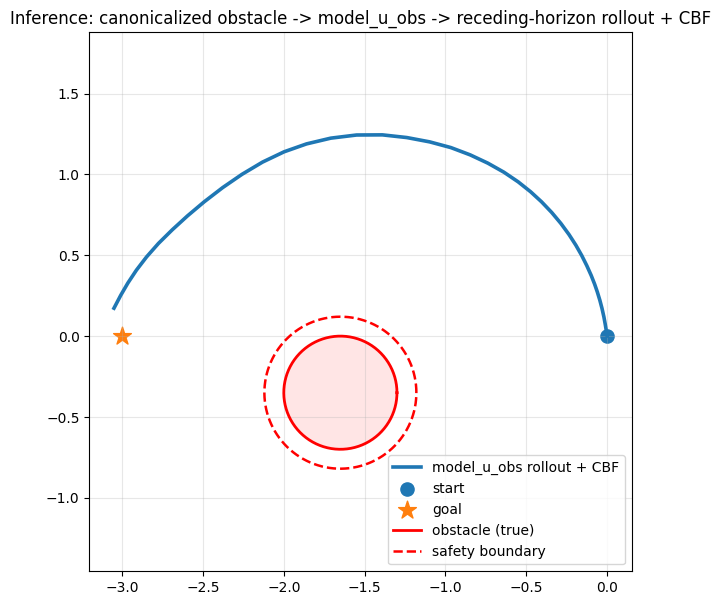

In [ ]:
# ===============================================================
# NEW CELL: Inference + rollout with canonicalized virtual-obstacle model `model_u_obs`
#
# At each step (receding horizon):
#   1) canonicalize geometry wrt current position:
#        - translate current pos -> origin
#        - rotate so goal direction is +x
#        - reflect so obstacle is on +y (left)
#   2) build cond = [goal_dist, obs_x, obs_y, v0, cos(theta0_can), sin(theta0_can), delta0_can]
#      (optionally compensate obs_y with car width change)
#   3) sample K control sequences u=[a,delta_rate] from `model_u_obs`
#   4) evaluate first H steps in CANONICAL frame with obstacle clearance cost
#   5) execute u0 in REAL frame, with CBF projection for safety
# ===============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt

if "model_u_obs" not in globals():
    raise RuntimeError("`model_u_obs` not found. Please run the canonical-obstacle training cell first.")

if "CTRL_T" not in globals():
    raise RuntimeError("`CTRL_T` not found. Please run the dataset loading cell first.")

if "cbf_project_velocity_step" not in globals() and "cbf_project_velocity_world" not in globals():
    raise RuntimeError("CBF projector not found. Please run the CBF cell first.")


def _wrap_pi(a: float) -> float:
    return float((a + np.pi) % (2 * np.pi) - np.pi)


def _rot2(a: float) -> np.ndarray:
    ca, sa = float(np.cos(a)), float(np.sin(a))
    return np.array([[ca, -sa], [sa, ca]], dtype=np.float64)


def canonicalize_step(state5, goal_xy, obs_xy, *, car_width_ref=0.32, car_width_new=0.32):
    """Canonicalize a single step around CURRENT state.

    Returns:
      - state_can5: [0,0,theta_can,v,delta_can]
      - goal_dist
      - obs_can (2,)
      - cond (6,)
      - meta (start_xy, phi, reflect)

    Width compensation (from your note):
      d'_obs = d_obs + (W_new - W_ref)/2  applied on obs_y in canonical frame.
    """
    s = np.asarray(state5, dtype=np.float64).copy()
    start_xy = s[:2].copy()
    g = np.asarray(goal_xy, dtype=np.float64).reshape(2)
    o = np.asarray(obs_xy, dtype=np.float64).reshape(2)

    g0 = g - start_xy
    o0 = o - start_xy

    goal_dist = float(np.linalg.norm(g0) + 1e-12)

    # rotate so goal on +x
    phi = float(np.arctan2(g0[1], g0[0]))
    R = _rot2(-phi)
    o_can = (R @ o0.reshape(2, 1)).reshape(2)

    reflect = False
    if float(o_can[1]) < 0.0:
        reflect = True
        o_can[1] *= -1.0

    # width compensation in canonical lateral offset (obs_y)
    comp = 0.5 * float(car_width_new - car_width_ref)
    o_can_adj = o_can.copy()
    o_can_adj[1] = float(o_can_adj[1] + comp)

    # angles
    theta_can = _wrap_pi(float(s[2]) - phi)
    delta_can = float(s[4])
    if reflect:
        theta_can = -theta_can
        delta_can = -delta_can

    state_can = np.array([0.0, 0.0, theta_can, float(s[3]), delta_can], dtype=np.float64)

    cond = np.array([
        goal_dist,
        float(o_can_adj[0]),
        float(o_can_adj[1]),
        float(s[3]),
        float(theta_can),
        float(delta_can),
    ], dtype=np.float64)

    meta = {
        "start_xy": start_xy,
        "phi": phi,
        "reflect": reflect,
        "obs_can": o_can,
        "obs_can_adj": o_can_adj,
        "goal_dist": goal_dist,
    }

    return state_can, goal_dist, o_can_adj, cond, meta


def uncanonicalize_u0(u0_can, *, reflect: bool):
    """Map control back from canonical to real.

    For rotation: a and delta_rate are vehicle-frame, invariant.
    For reflection across x-axis: delta_rate flips sign; acceleration unchanged.
    """
    u = np.asarray(u0_can, dtype=np.float64).reshape(2).copy()
    if reflect:
        u[1] = -u[1]
    return u


def sample_u_seq_from_model(model_u, cond_vec, ctrl_T, *, n_steps=60, device="cpu", noise_scale=1.0):
    dev = torch.device(device)
    model_u.eval()

    cond = torch.as_tensor(cond_vec, dtype=torch.float32, device=dev).view(1, -1)
    x = torch.randn(1, 2, int(ctrl_T), device=dev) * float(noise_scale)
    t_grid = torch.linspace(0.0, 1.0, int(n_steps) + 1, device=dev)

    with torch.no_grad():
        for i in range(int(n_steps)):
            t = t_grid[i].view(1)
            v = model_u(x, t, cond=cond)
            if v.shape[-1] != x.shape[-1]:
                Lmin = min(v.shape[-1], x.shape[-1])
                v = v[..., :Lmin]
                x = x[..., :Lmin]
            dt_local = float(t_grid[i + 1] - t_grid[i])
            x = x + dt_local * v

    u_seq = x[0].detach().cpu().numpy().astype(np.float64)  # (2,T)
    return u_seq.T  # (T,2)


def apply_cbf_to_xy(xy, v_nom_xy, ellipses, *, extra_margin, max_corr_norm, gamma_min, device):
    dev = torch.device(device)
    x_now_2 = torch.as_tensor(np.asarray(xy, dtype=np.float64), dtype=torch.float32, device=dev)
    v_nom_2 = torch.as_tensor(np.asarray(v_nom_xy, dtype=np.float64), dtype=torch.float32, device=dev)

    if "cbf_project_velocity_step" in globals():
        v_safe_2 = cbf_project_velocity_step(
            x_now_2,
            v_nom_2,
            ellipses,
            other_agent_pos_2=None,
            agent_safe_radius=0.5,
            extra_margin=float(extra_margin),
            max_corr_norm=float(max_corr_norm),
            gamma_min=float(gamma_min),
            w_p=0.0,
            press_k=1.0,
            press_n=2.0,
        )
        return v_safe_2.detach().cpu().numpy().astype(np.float64)

    x_traj = x_now_2.view(1, 2, 1)
    v_traj = v_nom_2.view(1, 2, 1)
    v_safe = cbf_project_velocity_world(
        x_traj,
        v_traj,
        ellipses=ellipses,
        extra_margin=float(extra_margin),
        max_corr_norm=float(max_corr_norm),
        passes=5,
        other_agent_traj=None,
        agent_safe_radius=0.5,
        gamma_min=float(gamma_min),
        w_p=0.0,
        press_k=1.0,
        press_n=2.0,
    )
    return v_safe.squeeze(0).squeeze(-1).detach().cpu().numpy().astype(np.float64)


def rollout_model_u_obs_with_real_obstacle(
    *,
    model_u_obs,
    init_state5,
    goal_xy,
    obstacle_center,
    obstacle_radius,
    safety_margin=0.12,
    # vehicle
    dt=0.1,
    L=0.8,
    delta_max=np.deg2rad(30.0),
    a_max=0.8,
    delta_rate_max=np.deg2rad(120.0),
    v_floor=0.25,
    # MPC
    H=12,
    K=24,
    max_steps=240,
    goal_tol=0.18,
    # sampling
    n_steps_sample=60,
    noise_scale=1.0,
    # costs
    w_goal=40.0,
    w_u=0.05,
    w_du=0.15,
    w_clear=0.40,
    # CBF
    gamma_min=6.0,
    max_corr_norm=10.0,
    device="cpu",
    # width compensation
    car_width_ref=0.32,
    car_width_new=0.32,
    debug_every=20,
):
    goal = np.asarray(goal_xy, dtype=np.float64).reshape(2)
    c_real = np.asarray(obstacle_center, dtype=np.float64).reshape(2)
    R_true = float(obstacle_radius)
    R_safe = float(obstacle_radius) + float(safety_margin)

    # Real-frame ellipse for CBF (circle)
    ell_real = [{"center": c_real.copy(), "radius": float(R_true)}]

    def clearance_cost_real(xy):
        # soft cost on safe boundary
        h = float(np.sum((xy - c_real) ** 2) - R_safe * R_safe)
        if h < 0.0:
            return 1e6
        return 1.0 / (h + 1e-6)

    state = np.asarray(init_state5, dtype=np.float64).copy()
    state[3] = max(float(state[3]), float(v_floor))

    xs = [state[:2].copy()]
    us = []

    u_last = np.zeros(2, dtype=np.float64)

    for step in range(int(max_steps)):
        dist = float(np.linalg.norm(state[:2] - goal))
        if dist <= float(goal_tol):
            break

        # canonicalize wrt current state
        state_can, goal_dist, obs_can, cond, meta = canonicalize_step(
            state,
            goal,
            c_real,
            car_width_ref=float(car_width_ref),
            car_width_new=float(car_width_new),
        )

        # canonical obstacle ellipse for evaluation
        ell_can = [{"center": np.asarray(obs_can, dtype=np.float64).reshape(2), "radius": float(R_true)}]

        def clearance_cost_can(xy_can):
            c = np.asarray(obs_can, dtype=np.float64).reshape(2)
            h = float(np.sum((xy_can - c) ** 2) - R_safe * R_safe)
            if h < 0.0:
                return 1e6
            return 1.0 / (h + 1e-6)

        best_J = float("inf")
        best_u0_can = None

        # sample candidates in canonical frame
        for k in range(int(K)):
            u_seq = sample_u_seq_from_model(
                model_u_obs,
                cond.astype(np.float32),
                ctrl_T=int(CTRL_T),
                n_steps=int(n_steps_sample),
                device=str(device),
                noise_scale=float(noise_scale) * (1.0 + 0.04 * k),
            )

            # clip
            u_seq[:, 0] = np.clip(u_seq[:, 0], -float(a_max), float(a_max))
            u_seq[:, 1] = np.clip(u_seq[:, 1], -float(delta_rate_max), float(delta_rate_max))

            s = state_can.copy()  # canonical state (x,y start at 0)
            J = 0.0
            prev_u = u_last.copy()

            for t in range(int(H)):
                u = u_seq[t]
                # control cost
                J += w_u * float(u[0] * u[0] + u[1] * u[1])
                du = u - prev_u
                J += w_du * float(du[0] * du[0] + du[1] * du[1])
                prev_u = u

                # integrate v/theta/delta (canonical)
                x, y, th, v, delta = [float(z) for z in s]
                a, d_rate = float(u[0]), float(u[1])
                delta = float(np.clip(delta + dt * d_rate, -float(delta_max), float(delta_max)))
                v = float(max(0.0, v + dt * a))
                th = _wrap_pi(th + dt * (v / float(L)) * np.tan(delta))

                v_nom_xy = np.array([v * np.cos(th), v * np.sin(th)], dtype=np.float64)
                v_safe_xy = apply_cbf_to_xy(
                    np.array([x, y], dtype=np.float64),
                    v_nom_xy,
                    ell_can,
                    extra_margin=float(safety_margin),
                    max_corr_norm=float(max_corr_norm),
                    gamma_min=float(gamma_min),
                    device=str(device),
                )

                x = float(x + dt * v_safe_xy[0])
                y = float(y + dt * v_safe_xy[1])

                s = np.array([x, y, th, v, delta], dtype=np.float64)

                J += w_clear * float(clearance_cost_can(s[:2]))

            # terminal goal in canonical is (goal_dist, 0)
            goal_can = np.array([goal_dist, 0.0], dtype=np.float64)
            J += w_goal * float(np.sum((s[:2] - goal_can) ** 2))

            if J < best_J:
                best_J = J
                best_u0_can = u_seq[0].copy()

        if best_u0_can is None:
            best_u0_can = np.array([-0.2 * float(a_max), 0.0], dtype=np.float64)

        # map control back to real (reflection only)
        u0_real = uncanonicalize_u0(best_u0_can, reflect=bool(meta["reflect"]))
        u0_real[0] = float(np.clip(u0_real[0], -float(a_max), float(a_max)))
        u0_real[1] = float(np.clip(u0_real[1], -float(delta_rate_max), float(delta_rate_max)))

        # execute one step in REAL frame with CBF
        x, y, th, v, delta = [float(z) for z in state]
        a, d_rate = float(u0_real[0]), float(u0_real[1])
        delta = float(np.clip(delta + dt * d_rate, -float(delta_max), float(delta_max)))
        v = float(max(float(v_floor), v + dt * a))
        th = _wrap_pi(th + dt * (v / float(L)) * np.tan(delta))

        v_nom_xy = np.array([v * np.cos(th), v * np.sin(th)], dtype=np.float64)
        v_safe_xy = apply_cbf_to_xy(
            np.array([x, y], dtype=np.float64),
            v_nom_xy,
            ell_real,
            extra_margin=float(safety_margin),
            max_corr_norm=float(max_corr_norm),
            gamma_min=float(gamma_min),
            device=str(device),
        )
        x = float(x + dt * v_safe_xy[0])
        y = float(y + dt * v_safe_xy[1])

        state = np.array([x, y, th, v, delta], dtype=np.float64)
        xs.append(state[:2].copy())
        us.append(u0_real.copy())
        u_last = best_u0_can.copy()  # keep last in canonical sense (works well with reflect flip)

        if debug_every is not None and step % int(debug_every) == 0:
            print(f"[step {step:03d}] dist={dist:.3f} bestJ={best_J:.2f} reflect={meta['reflect']} v={state[3]:.2f}")

    return np.asarray(xs, dtype=np.float64), np.asarray(us, dtype=np.float64), ell_real, R_safe


# -------------------------
# RUN DEMO
# -------------------------
# init state from dataset if present
if "states_np" in globals():
    s0 = np.asarray(states_np[0, 0], dtype=np.float64)
else:
    s0 = np.array([0.0, 0.0, 0.8, 0.25, 0.0], dtype=np.float64)

# goal: use dataset goal if available
if "data" in globals() and isinstance(data, dict) and ("goals" in data):
    goal = np.asarray(data["goals"][0], dtype=np.float64)
elif "goal_xy" in globals():
    goal = np.asarray(goal_xy, dtype=np.float64)
else:
    goal = np.array([3.0, 0.0], dtype=np.float64)

# obstacle: place between start-goal with lateral offset (you can set your real obstacle here)
start_xy = s0[:2]
d = goal - start_xy
u = d / (np.linalg.norm(d) + 1e-12)
n = np.array([-u[1], u[0]], dtype=np.float64)
obs_center = start_xy + 0.55 * d + 0.35 * n
R_obs = 0.35

# params from data if available
if "data" in globals() and isinstance(data, dict) and ("params" in data):
    dt = float(data["params"].get("dt", 0.1))
    L = float(data["params"].get("L", 0.8))
    delta_max = float(data["params"].get("delta_max", np.deg2rad(30.0)))
    a_max = float(data["params"].get("a_max", 0.8))
    delta_rate_max = float(data["params"].get("delta_rate_max", np.deg2rad(120.0)))
else:
    dt, L = 0.1, 0.8
    delta_max = float(np.deg2rad(30.0))
    a_max = 0.8
    delta_rate_max = float(np.deg2rad(120.0))

xs_can, us_can, ell_real, R_safe = rollout_model_u_obs_with_real_obstacle(
    model_u_obs=model_u_obs,
    init_state5=s0,
    goal_xy=goal,
    obstacle_center=obs_center,
    obstacle_radius=R_obs,
    safety_margin=float(globals().get("safety_margin", 0.12)),
    dt=float(dt),
    L=float(L),
    delta_max=float(delta_max),
    a_max=float(a_max),
    delta_rate_max=float(delta_rate_max),
    v_floor=0.25,
    H=12,
    K=24,
    max_steps=260,
    goal_tol=0.18,
    n_steps_sample=60,
    noise_scale=1.0,
    w_goal=40.0,
    w_u=0.05,
    w_du=0.15,
    w_clear=0.40,
    gamma_min=6.0,
    max_corr_norm=10.0,
    device=str(globals().get("device", "cpu")),
    car_width_ref=0.32,
    car_width_new=0.32,
    debug_every=20,
)

# Plot
th = np.linspace(0, 2 * np.pi, 360)
plt.figure(figsize=(7, 7))
plt.plot(xs_can[:, 0], xs_can[:, 1], "-", linewidth=2.6, label="model_u_obs rollout + CBF")
plt.scatter([xs_can[0, 0]], [xs_can[0, 1]], s=90, label="start")
plt.scatter([goal[0]], [goal[1]], s=180, marker="*", label="goal")

c = np.asarray(obs_center, dtype=np.float64).reshape(2)
plt.plot(c[0] + float(R_obs) * np.cos(th), c[1] + float(R_obs) * np.sin(th), "r-", linewidth=2.0, label="obstacle (true)")
plt.fill(c[0] + float(R_obs) * np.cos(th), c[1] + float(R_obs) * np.sin(th), color="red", alpha=0.10)
plt.plot(c[0] + float(R_safe) * np.cos(th), c[1] + float(R_safe) * np.sin(th), "r--", linewidth=1.8, label="safety boundary")

plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.title("Inference: canonicalized obstacle -> model_u_obs -> receding-horizon rollout + CBF")
plt.legend()
plt.show()



In [ ]:
# ===============================================================
# NEW CELL (corrected): Canonical goal-only training set (NO obstacle conditioning)
#
# Why:
#   - Your dataset is obstacle-free, so labels (u_seq) contain no obstacle info.
#   - Conditioning on obs would encourage the network to ignore obs (correct behavior),
#     but it won't learn obstacle-reactive controls.
#
# What we do:
#   - Canonicalize by GOAL direction only (translate start -> origin, rotate goal -> +x)
#   - Random reflect w.p. 0.5 to enforce left/right equivariance
#   - Train model to generate u_seq in this canonical frame.
#   - Obstacle avoidance will be handled at inference by a geometric action-mapping correction.
# ===============================================================

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

if "data" not in globals() or (not isinstance(data, dict)):
    raise RuntimeError("Need `data` in globals.")

# Always use current data
states_np = np.asarray(data["states"], dtype=np.float32)
controls_np = np.asarray(data["controls"], dtype=np.float32)
goals_np = np.asarray(data["goals"], dtype=np.float64)


def _wrap_pi(a: float) -> float:
    return float((a + np.pi) % (2 * np.pi) - np.pi)


def _rot2(a: float) -> np.ndarray:
    ca, sa = float(np.cos(a)), float(np.sin(a))
    return np.array([[ca, -sa], [sa, ca]], dtype=np.float64)


def canonicalize_goal_only(states_T5, controls_T2, goal_xy, *, do_reflect: bool):
    """Canonicalize by goal direction.

    states_T5: (T,5) [x,y,theta,v,delta]
    controls_T2: (T,2) padded, last row 0

    reflect (x-axis in canonical): y->-y, theta->-theta, delta->-delta, delta_rate->-delta_rate
    """
    st = np.asarray(states_T5, dtype=np.float64)
    u = np.asarray(controls_T2, dtype=np.float64).copy()

    start = st[0, :2].copy()
    g = np.asarray(goal_xy, dtype=np.float64).reshape(2)

    # translate
    xy = st[:, :2] - start[None, :]
    g0 = g - start

    # rotate goal to +x
    phi = float(np.arctan2(g0[1], g0[0]))
    R = _rot2(-phi)
    xy = (R @ xy.T).T

    th = np.array([_wrap_pi(float(a) - phi) for a in st[:, 2]], dtype=np.float64)
    delta = np.asarray(st[:, 4], dtype=np.float64)

    if bool(do_reflect):
        xy[:, 1] *= -1.0
        th = -th
        delta = -delta
        u[:-1, 1] = -u[:-1, 1]  # delta_rate flip

    st_can = st.copy()
    st_can[:, 0] = xy[:, 0]
    st_can[:, 1] = xy[:, 1]
    st_can[:, 2] = th
    st_can[:, 4] = delta

    goal_dist = float(np.linalg.norm(g0) + 1e-12)

    # cond without obstacle (and without goal_dist to reduce goal-distribution shift):
    #   [v0, theta0_can, delta0_can]
    # Goal direction is already canonicalized (goal on +x).
    cond = np.array([
        float(st_can[0, 3]),
        float(st_can[0, 2]),
        float(st_can[0, 4]),
    ], dtype=np.float32)

    return st_can, u, cond


class CanonicalGoalControlDataset(Dataset):
    def __init__(self, states, controls, goals, *, seed=0):
        self.states = np.asarray(states, dtype=np.float64)
        self.controls = np.asarray(controls, dtype=np.float64)
        self.goals = np.asarray(goals, dtype=np.float64)
        self.rng = np.random.default_rng(int(seed))

    def __len__(self):
        return int(self.states.shape[0])

    def __getitem__(self, idx):
        st = self.states[int(idx)]
        u = self.controls[int(idx)]
        g = self.goals[int(idx)]

        do_reflect = bool(self.rng.uniform() < 0.5)
        _, u_can, cond = canonicalize_goal_only(st, u, g, do_reflect=do_reflect)

        u_seq = u_can[:-1].T.astype(np.float32)  # (2,CTRL_T)
        return torch.from_numpy(u_seq), torch.from_numpy(cond)


goals_np = np.asarray(data["goals"], dtype=np.float64)
canon_goal_ds = CanonicalGoalControlDataset(states_np, controls_np, goals_np, seed=123)
canon_goal_loader = DataLoader(canon_goal_ds, batch_size=64, shuffle=True, drop_last=True)

u_ex, cond_ex = canon_goal_ds[0]
print("canon_goal_ds size:", len(canon_goal_ds))
print("u_seq shape:", tuple(u_ex.shape), "cond shape:", tuple(cond_ex.shape))
print("cond = [v0, theta0_can, delta0_can] ->", cond_ex.numpy())



canon_goal_ds size: 100
u_seq shape: (2, 59) cond shape: (3,)
cond = [v0, theta0_can, delta0_can] -> [ 0.25     -1.420276  0.      ]


In [17]:
# ===============================================================
# NEW CELL (corrected): Train `model_u_can` on goal-canonicalized data
# ===============================================================

import torch
import torch.nn as nn

if "canon_goal_loader" not in globals():
    raise RuntimeError("Please run the goal-only canonical dataset cell first.")

if "SimpleUNet1D" not in globals():
    raise RuntimeError("SimpleUNet1D not found. Run the model definition cell first.")

if "CondOTScheduler" not in globals() or "AffinePath" not in globals():
    raise RuntimeError("Need CondOTScheduler/AffinePath. Run the FM components cell first.")

COND_DIM_CAN = 3
model_u_can = SimpleUNet1D(time_emb_dim=128, hidden_dim=128, cond_dim=COND_DIM_CAN).to(device)
optimizer_u_can = torch.optim.Adam(model_u_can.parameters(), lr=1e-3)

scheduler = CondOTScheduler()
path = AffinePath(scheduler)

EPOCHS = 8
LOG_EVERY = 100

model_u_can.train()
step = 0
for ep in range(int(EPOCHS)):
    for u_seq, cond in canon_goal_loader:
        u_seq = u_seq.to(device)  # (B,2,T)
        cond = cond.to(device)    # (B,4)

        B = u_seq.shape[0]
        x0 = torch.randn_like(u_seq)
        x1 = u_seq

        t = torch.rand(B, device=device)
        ps = path.sample(x0, x1, t)

        v_pred = model_u_can(ps.x_t, t, cond=cond)
        loss = torch.mean((v_pred - ps.dx_t) ** 2)

        optimizer_u_can.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_u_can.parameters(), 1.0)
        optimizer_u_can.step()

        if step % int(LOG_EVERY) == 0:
            print(f"[train model_u_can] ep={ep} step={step} loss={loss.item():.6f}")
        step += 1

print("✅ Trained `model_u_can` (goal-canonical, no obstacle conditioning).")



[train model_u_can] ep=0 step=0 loss=1.343399
✅ Trained `model_u_can` (goal-canonical, no obstacle conditioning).


[step 000] dist=3.000 bestJ=353.06 reflect=False v=0.25
[step 020] dist=2.861 bestJ=272.51 reflect=False v=0.47
[step 040] dist=2.264 bestJ=74.48 reflect=False v=0.80
[step 060] dist=0.570 bestJ=4.02 reflect=False v=0.73


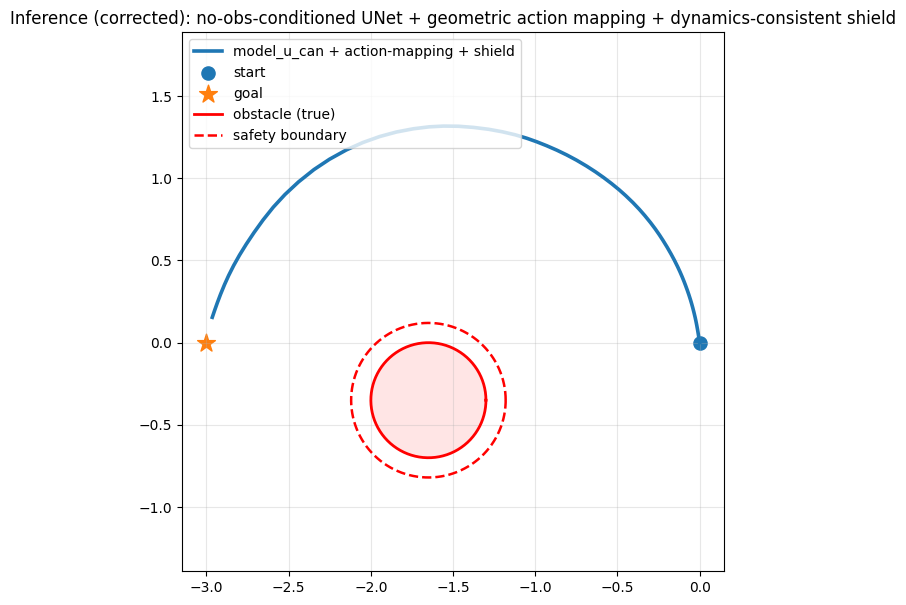

In [20]:
# ===============================================================
# NEW CELL (corrected): Inference rollout with real obstacle using
#   - model_u_can (goal-canonical, no obstacle conditioning)
#   - geometric action mapping (avoidance correction) in canonical frame
#   - dynamics-consistent rollout (pure bicycle), with shield (reject unsafe u0)
#
# This avoids the previous inconsistency of projecting world velocity with CBF
# inside a bicycle-control rollout.
# ===============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt

if "model_u_can" not in globals():
    raise RuntimeError("`model_u_can` not found. Run the training cell above first.")

if "CTRL_T" not in globals():
    raise RuntimeError("CTRL_T not found.")

# Need a bicycle step
if "_step_bicycle_simple" not in globals():
    def _wrap_pi(a: float) -> float:
        return float((a + np.pi) % (2 * np.pi) - np.pi)

    def _step_bicycle_simple(state5, u, dt, L, delta_max, v_min=0.0):
        x, y, th, v, delta = [float(z) for z in state5]
        a, delta_rate = float(u[0]), float(u[1])
        delta = float(np.clip(delta + dt * delta_rate, -delta_max, delta_max))
        v = float(max(v_min, v + dt * a))
        th = _wrap_pi(th + dt * (v / float(L)) * np.tan(delta))
        x = float(x + dt * v * np.cos(th))
        y = float(y + dt * v * np.sin(th))
        return np.array([x, y, th, v, delta], dtype=np.float64)


def _rot2(a: float) -> np.ndarray:
    ca, sa = float(np.cos(a)), float(np.sin(a))
    return np.array([[ca, -sa], [sa, ca]], dtype=np.float64)


def canonicalize_runtime(state5, goal_xy, obs_xy):
    """Translate current pos->origin, rotate goal->+x, reflect so obs is +y."""
    s = np.asarray(state5, dtype=np.float64)
    p = s[:2]
    g = np.asarray(goal_xy, dtype=np.float64).reshape(2)
    o = np.asarray(obs_xy, dtype=np.float64).reshape(2)

    g0 = g - p
    o0 = o - p

    goal_dist = float(np.linalg.norm(g0) + 1e-12)
    phi = float(np.arctan2(g0[1], g0[0]))
    R = _rot2(-phi)

    o_can = (R @ o0.reshape(2, 1)).reshape(2)

    reflect = False
    if float(o_can[1]) < 0.0:
        reflect = True
        o_can[1] *= -1.0

    theta_can = float((float(s[2]) - phi + np.pi) % (2 * np.pi) - np.pi)
    delta_can = float(s[4])
    if reflect:
        theta_can = -theta_can
        delta_can = -delta_can

    state_can = np.array([0.0, 0.0, theta_can, float(s[3]), delta_can], dtype=np.float64)

    # cond does NOT include goal_dist to reduce distribution shift when testing arbitrary goals
    cond = np.array([float(s[3]), float(theta_can), float(delta_can)], dtype=np.float32)

    meta = {"phi": phi, "reflect": reflect, "goal_dist": goal_dist, "obs_can": o_can}
    return state_can, cond, meta


def uncanonicalize_u0(u0_can, reflect: bool):
    u = np.asarray(u0_can, dtype=np.float64).reshape(2).copy()
    if reflect:
        u[1] = -u[1]
    return u


def sample_u_seq(model, cond, ctrl_T, *, n_steps=60, device="cpu", noise_scale=1.0):
    dev = torch.device(device)
    model.eval()
    cond_t = torch.as_tensor(cond, dtype=torch.float32, device=dev).view(1, -1)

    x = torch.randn(1, 2, int(ctrl_T), device=dev) * float(noise_scale)
    t_grid = torch.linspace(0.0, 1.0, int(n_steps) + 1, device=dev)

    with torch.no_grad():
        for i in range(int(n_steps)):
            t = t_grid[i].view(1)
            v = model(x, t, cond=cond_t)
            if v.shape[-1] != x.shape[-1]:
                Lmin = min(v.shape[-1], x.shape[-1])
                v = v[..., :Lmin]
                x = x[..., :Lmin]
            x = x + float(t_grid[i + 1] - t_grid[i]) * v

    return x[0].detach().cpu().numpy().T.astype(np.float64)  # (T,2)


def circle_h(xy, c, R):
    d = np.asarray(xy, dtype=np.float64) - np.asarray(c, dtype=np.float64)
    return float(d @ d - R * R)


def apply_avoidance_action_mapping(
    u_seq_can,
    obs_can,
    *,
    R_safe,
    car_width_ref=0.32,
    car_width_new=0.32,
    # smaller + more local correction (prevents huge detours)
    k_lat=0.25,
    k_brake=0.05,
    p=2.0,
    x_gate=(0.0, 2.0),
    y_gate=0.9,
    tau=4.0,
    corr_steps=10,
):
    """Geometric correction in canonical frame.

    Key change: make the correction LOCAL and PROPORTIONAL to how much we need to clear R_safe.
    This avoids the "big loop" behavior.

    - obstacle is canonicalized to +y side.
    - to pass on the right, apply negative delta_rate.
    """
    u = np.asarray(u_seq_can, dtype=np.float64).copy()
    ox, oy = float(obs_can[0]), float(obs_can[1])

    # width compensation on lateral offset
    oy = oy + 0.5 * float(car_width_new - car_width_ref)

    # only when obstacle is ahead and close to centerline
    if not (float(x_gate[0]) <= ox <= float(x_gate[1])):
        return u
    if oy > float(y_gate):
        return u

    # how much lateral clearance we are missing (in meters)
    miss = max(0.0, float(R_safe) - abs(oy))
    if miss <= 0.0:
        return u

    # scale: smaller and bounded; decreases with oy
    strength = float(k_lat) * (miss / (abs(oy) ** float(p) + 1e-6))
    brake = float(k_brake) * (miss / (abs(oy) ** float(p) + 1e-6))

    T = int(u.shape[0])
    Tcorr = int(min(max(1, int(corr_steps)), T))
    for t in range(Tcorr):
        w = float(np.exp(-float(t) / max(1.0, float(tau))))
        u[t, 1] += -w * strength
        u[t, 0] += -w * brake

    return u


def rollout_model_u_can_with_obstacle(
    *,
    model,
    init_state5,
    goal_xy,
    obs_center,
    obs_radius,
    safety_margin=0.12,
    dt=0.1,
    L=0.8,
    delta_max=np.deg2rad(30.0),
    a_max=0.8,
    delta_rate_max=np.deg2rad(120.0),
    v_floor=0.25,
    # receding horizon
    H=12,
    K=12,
    max_steps=260,
    goal_tol=0.18,
    # sampling
    n_steps_sample=40,
    noise_scale=1.0,
    # costs
    w_goal=40.0,
    w_u=0.05,
    w_du=0.15,
    w_clear=0.50,
    w_lane=0.15,   # keep y close to 0 in canonical (prevents huge detours)
    # action mapping
    car_width_ref=0.32,
    car_width_new=0.32,
    k_lat=0.25,
    k_brake=0.05,
    p=2.0,
    device="cpu",
    debug_every=20,
):
    g = np.asarray(goal_xy, dtype=np.float64).reshape(2)
    c = np.asarray(obs_center, dtype=np.float64).reshape(2)
    R_true = float(obs_radius)
    R_safe = float(obs_radius) + float(safety_margin)

    state = np.asarray(init_state5, dtype=np.float64).copy()
    state[3] = max(float(state[3]), float(v_floor))

    xs = [state[:2].copy()]
    us = []

    # Keep last-applied control in REAL frame, then map into current canonical frame
    # so smoothness penalty does not break when reflect flips.
    u_last_real = np.zeros(2, dtype=np.float64)

    for step in range(int(max_steps)):
        dist = float(np.linalg.norm(state[:2] - g))
        if dist <= float(goal_tol):
            break

        # canonicalize wrt current state
        state_can, cond, meta = canonicalize_runtime(state, g, c)
        goal_dist = float(meta["goal_dist"])
        obs_can = np.asarray(meta["obs_can"], dtype=np.float64)

        # map last control into THIS canonical frame (reflection flips delta_rate)
        u_last_can0 = u_last_real.copy()
        if bool(meta["reflect"]):
            u_last_can0[1] = -u_last_can0[1]

        bestJ = float("inf")
        best_u0_can = None

        for k in range(int(K)):
            u_seq = sample_u_seq(
                model,
                cond,
                ctrl_T=int(CTRL_T),
                n_steps=int(n_steps_sample),
                device=str(device),
                noise_scale=float(noise_scale) * (1.0 + 0.04 * k),
            )

            # apply geometric avoidance correction in canonical frame
            u_seq = apply_avoidance_action_mapping(
                u_seq,
                obs_can,
                R_safe=R_safe,
                car_width_ref=float(car_width_ref),
                car_width_new=float(car_width_new),
                k_lat=float(k_lat),
                k_brake=float(k_brake),
                p=float(p),
            )

            # clip
            u_seq[:, 0] = np.clip(u_seq[:, 0], -float(a_max), float(a_max))
            u_seq[:, 1] = np.clip(u_seq[:, 1], -float(delta_rate_max), float(delta_rate_max))

            s = state_can.copy()
            J = 0.0
            prev_u = u_last_can0.copy()

            # canonical obstacle center
            c_can = obs_can.copy()

            for t in range(int(H)):
                u = u_seq[t]
                J += w_u * float(u[0] * u[0] + u[1] * u[1])
                du = u - prev_u
                J += w_du * float(du[0] * du[0] + du[1] * du[1])
                prev_u = u

                # keep forward progress; avoid getting stuck at v=0
                s = _step_bicycle_simple(s, u, float(dt), float(L), float(delta_max), v_min=float(v_floor))

                # keep close to canonical centerline unless needed (reduces big loops)
                J += float(w_lane) * float(s[1] * s[1])

                h = circle_h(s[:2], c_can, R_safe)
                if h < 0.0:
                    J += 1e6
                    break
                J += w_clear * (1.0 / (h + 1e-6))

            # terminal goal in canonical: (goal_dist, 0)
            goal_can = np.array([goal_dist, 0.0], dtype=np.float64)
            J += w_goal * float(np.sum((s[:2] - goal_can) ** 2))

            if J < bestJ:
                bestJ = J
                best_u0_can = u_seq[0].copy()

        if best_u0_can is None:
            best_u0_can = np.array([-0.2 * float(a_max), 0.0], dtype=np.float64)

        # map u0 back to real
        u0 = uncanonicalize_u0(best_u0_can, reflect=bool(meta["reflect"]))
        u0[0] = float(np.clip(u0[0], -float(a_max), float(a_max)))
        u0[1] = float(np.clip(u0[1], -float(delta_rate_max), float(delta_rate_max)))

        # shield: if next state collides, resample a few times
        ok = False
        for j in range(10):
            nxt = _step_bicycle_simple(state, u0, float(dt), float(L), float(delta_max), v_min=float(v_floor))
            if circle_h(nxt[:2], c, R_safe) >= 0.0:
                ok = True
                state = nxt
                break

            # resample and add stronger avoidance
            u_seq2 = sample_u_seq(
                model,
                cond,
                ctrl_T=int(CTRL_T),
                n_steps=int(n_steps_sample),
                device=str(device),
                noise_scale=float(noise_scale) * (1.2 + 0.10 * j),
            )
            u_seq2 = apply_avoidance_action_mapping(
                u_seq2,
                obs_can,
                R_safe=R_safe,
                car_width_ref=float(car_width_ref),
                car_width_new=float(car_width_new),
                k_lat=float(k_lat) * (1.0 + 0.25 * j),
                k_brake=float(k_brake) * (1.0 + 0.25 * j),
                p=float(p),
            )
            u0 = uncanonicalize_u0(u_seq2[0], reflect=bool(meta["reflect"]))
            u0[0] = float(np.clip(u0[0], -float(a_max), float(a_max)))
            u0[1] = float(np.clip(u0[1], -float(delta_rate_max), float(delta_rate_max)))

        if not ok:
            # final fallback: brake + steer away from obstacle
            vec = c - state[:2]
            left = np.array([-vec[1], vec[0]], dtype=np.float64)
            sign = -1.0 if float(left[1]) > 0 else 1.0
            u0 = np.array([-0.4 * float(a_max), sign * float(delta_rate_max)], dtype=np.float64)
            state = _step_bicycle_simple(state, u0, float(dt), float(L), float(delta_max), v_min=float(v_floor))

        xs.append(state[:2].copy())
        us.append(u0.copy())
        # store last applied control in REAL frame (reflection-safe)
        u_last_real = u0.copy()

        if debug_every is not None and step % int(debug_every) == 0:
            print(f"[step {step:03d}] dist={dist:.3f} bestJ={bestJ:.2f} reflect={meta['reflect']} v={state[3]:.2f}")

    return np.asarray(xs, dtype=np.float64), np.asarray(us, dtype=np.float64), R_safe


# -------------------------
# RUN DEMO
# -------------------------
# init state
if "states_np" in globals():
    s0 = np.asarray(states_np[0, 0], dtype=np.float64)
else:
    s0 = np.array([0.0, 0.0, 0.8, 0.25, 0.0], dtype=np.float64)

# goal
if "data" in globals() and isinstance(data, dict) and ("goals" in data):
    goal = np.asarray(data["goals"][0], dtype=np.float64)
else:
    goal = np.array([3.0, 0.0], dtype=np.float64)

# obstacle (real)
start_xy = s0[:2]
d = goal - start_xy
u = d / (np.linalg.norm(d) + 1e-12)
n = np.array([-u[1], u[0]], dtype=np.float64)
obs_center = start_xy + 0.55 * d + 0.35 * n
R_obs = 0.35

# params
if "data" in globals() and isinstance(data, dict) and ("params" in data):
    dt = float(data["params"].get("dt", 0.1))
    L = float(data["params"].get("L", 0.8))
    delta_max = float(data["params"].get("delta_max", np.deg2rad(30.0)))
    a_max = float(data["params"].get("a_max", 0.8))
    delta_rate_max = float(data["params"].get("delta_rate_max", np.deg2rad(120.0)))
else:
    dt, L = 0.1, 0.8
    delta_max = float(np.deg2rad(30.0))
    a_max = 0.8
    delta_rate_max = float(np.deg2rad(120.0))

xs_fix, us_fix, R_safe = rollout_model_u_can_with_obstacle(
    model=model_u_can,
    init_state5=s0,
    goal_xy=goal,
    obs_center=obs_center,
    obs_radius=R_obs,
    safety_margin=float(globals().get("safety_margin", 0.12)),
    dt=float(dt),
    L=float(L),
    delta_max=float(delta_max),
    a_max=float(a_max),
    delta_rate_max=float(delta_rate_max),
    v_floor=0.25,
    H=12,
    K=12,
    max_steps=260,
    goal_tol=0.18,
    n_steps_sample=40,
    noise_scale=1.0,
    w_goal=40.0,
    w_u=0.05,
    w_du=0.15,
    w_clear=0.50,
    car_width_ref=0.32,
    car_width_new=0.32,
    k_lat=0.8,
    k_brake=0.15,
    p=2.0,
    device=str(globals().get("device", "cpu")),
    debug_every=20,
)

# Plot
th = np.linspace(0, 2*np.pi, 360)
plt.figure(figsize=(7, 7))
plt.plot(xs_fix[:, 0], xs_fix[:, 1], "-", linewidth=2.6, label="model_u_can + action-mapping + shield")
plt.scatter([xs_fix[0, 0]], [xs_fix[0, 1]], s=90, label="start")
plt.scatter([goal[0]], [goal[1]], s=180, marker="*", label="goal")

c = np.asarray(obs_center, dtype=np.float64)
plt.plot(c[0] + R_obs*np.cos(th), c[1] + R_obs*np.sin(th), "r-", linewidth=2.0, label="obstacle (true)")
plt.fill(c[0] + R_obs*np.cos(th), c[1] + R_obs*np.sin(th), color="red", alpha=0.10)
plt.plot(c[0] + R_safe*np.cos(th), c[1] + R_safe*np.sin(th), "r--", linewidth=1.8, label="safety boundary")

plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.title("Inference (corrected): no-obs-conditioned UNet + geometric action mapping + dynamics-consistent shield")
plt.legend()
plt.show()




[step 000] dAB=1.959  JA=229.8 JB=232.3  |dA|=2.80 |dB|=2.80
[step 020] dAB=0.684  JA=1000109.8 JB=1000121.6  |dA|=1.65 |dB|=1.75
[step 040] dAB=1.608  JA=196.0 JB=28.8  |dA|=1.99 |dB|=1.20
[step 060] dAB=1.411  JA=288.1 JB=10.3  |dA|=2.45 |dB|=0.51
[step 080] dAB=1.541  JA=396.2 JB=6.6  |dA|=2.92 |dB|=0.00
[step 100] dAB=1.872  JA=517.8 JB=23.0  |dA|=3.39 |dB|=0.50
[step 120] dAB=2.435  JA=635.5 JB=60.4  |dA|=3.81 |dB|=0.99
[step 140] dAB=3.142  JA=735.7 JB=118.2  |dA|=4.15 |dB|=1.49
[step 160] dAB=3.822  JA=803.7 JB=196.4  |dA|=4.41 |dB|=1.99
[step 180] dAB=4.408  JA=836.6 JB=282.9  |dA|=4.55 |dB|=2.46
[step 200] dAB=5.218  JA=664.7 JB=370.6  |dA|=4.48 |dB|=2.88
[step 220] dAB=5.803  JA=100.9 JB=446.3  |dA|=2.98 |dB|=3.21
[step 240] dAB=5.313  JA=10.5 JB=500.2  |dA|=0.20 |dB|=3.46


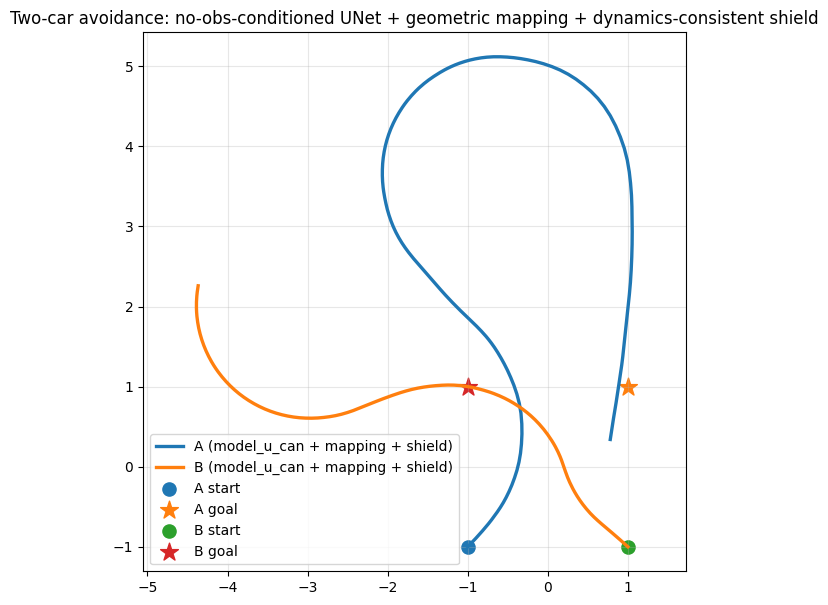

In [ ]:
# ===============================================================
# NEW CELL (corrected): Two-car avoidance with `model_u_can` + action-mapping + shield
#
# - Each car uses its own goal-canonical frame (goal -> +x).
# - The other car is treated as a moving circular obstacle (center only).
# - We apply geometric action-mapping correction in canonical frame.
# - Rollout is dynamics-consistent (pure bicycle) and uses shield (reject unsafe u0).
# - Mild priority/yield: B has stronger avoidance/brake so the symmetric case doesn't deadlock.
# ===============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt

if "model_u_can" not in globals():
    raise RuntimeError("`model_u_can` not found. Run the training cell for model_u_can first.")

if "CTRL_T" not in globals():
    raise RuntimeError("CTRL_T not found.")

# Reuse helpers from the corrected single-car cell
if "canonicalize_runtime" not in globals() or "sample_u_seq" not in globals() or "apply_avoidance_action_mapping" not in globals():
    raise RuntimeError("Please run the corrected single-car inference cell above (it defines canonicalize_runtime/sample_u_seq/apply_avoidance_action_mapping).")

if "_step_bicycle_simple" not in globals():
    raise RuntimeError("_step_bicycle_simple not found.")


def circle_h(xy, c, R):
    d = np.asarray(xy, dtype=np.float64) - np.asarray(c, dtype=np.float64)
    return float(d @ d - R * R)


def plan_one_step_against_other(
    *,
    model,
    state5,
    goal_xy,
    other_pos_xy,
    other_safe_R,
    dt,
    L,
    delta_max,
    a_max,
    delta_rate_max,
    v_floor,
    H,
    K,
    n_steps_sample,
    noise_scale,
    # costs
    w_goal,
    w_u,
    w_du,
    w_clear,
    w_lane,
    # mapping
    k_lat,
    k_brake,
    p,
    # priority
    extra_brake_close=0.0,
    device="cpu",
):
    """Return (u0_real, bestJ, meta) for this car."""
    s = np.asarray(state5, dtype=np.float64).copy()
    g = np.asarray(goal_xy, dtype=np.float64).reshape(2)
    other = np.asarray(other_pos_xy, dtype=np.float64).reshape(2)

    # canonicalize using other as 'obs' (canonicalize_runtime reflects so obs is +y)
    state_can, cond, meta = canonicalize_runtime(s, g, other)
    goal_dist = float(meta["goal_dist"])
    obs_can = np.asarray(meta["obs_can"], dtype=np.float64)

    bestJ = float("inf")
    best_u0_can = None

    # canonical goal point is (goal_dist, 0)
    goal_can = np.array([goal_dist, 0.0], dtype=np.float64)

    # initial smoothness reference (no history passed here)
    # caller should incorporate history if desired; we keep it simple.
    u_last_can0 = np.zeros(2, dtype=np.float64)

    for k in range(int(K)):
        u_seq = sample_u_seq(
            model,
            cond,
            ctrl_T=int(CTRL_T),
            n_steps=int(n_steps_sample),
            device=str(device),
            noise_scale=float(noise_scale) * (1.0 + 0.04 * k),
        )

        # action mapping against other car (treated as circular obstacle)
        u_seq = apply_avoidance_action_mapping(
            u_seq,
            obs_can,
            R_safe=float(other_safe_R),
            k_lat=float(k_lat),
            k_brake=float(k_brake),
            p=float(p),
        )

        # clip
        u_seq[:, 0] = np.clip(u_seq[:, 0], -float(a_max), float(a_max))
        u_seq[:, 1] = np.clip(u_seq[:, 1], -float(delta_rate_max), float(delta_rate_max))

        st = state_can.copy()
        J = 0.0
        prev_u = u_last_can0.copy()

        for t in range(int(H)):
            u = u_seq[t]
            J += float(w_u) * float(u[0] * u[0] + u[1] * u[1])
            du = u - prev_u
            J += float(w_du) * float(du[0] * du[0] + du[1] * du[1])
            prev_u = u

            st = _step_bicycle_simple(st, u, float(dt), float(L), float(delta_max), v_min=float(v_floor))

            # keep near centerline in canonical
            J += float(w_lane) * float(st[1] * st[1])

            h = circle_h(st[:2], obs_can, float(other_safe_R))
            if h < 0.0:
                J += 1e6
                break
            J += float(w_clear) * (1.0 / (h + 1e-6))

        J += float(w_goal) * float(np.sum((st[:2] - goal_can) ** 2))

        if J < bestJ:
            bestJ = J
            best_u0_can = u_seq[0].copy()

    if best_u0_can is None:
        best_u0_can = np.array([-0.2 * float(a_max), 0.0], dtype=np.float64)

    # map u0 back to real (reflect flips delta_rate)
    u0 = np.asarray(best_u0_can, dtype=np.float64).copy()
    if bool(meta["reflect"]):
        u0[1] = -u0[1]

    # optional extra brake when very close
    if float(np.linalg.norm(s[:2] - other)) < float(other_safe_R) * 1.15:
        u0[0] = float(u0[0] - abs(extra_brake_close) * float(a_max))

    u0[0] = float(np.clip(u0[0], -float(a_max), float(a_max)))
    u0[1] = float(np.clip(u0[1], -float(delta_rate_max), float(delta_rate_max)))

    return u0, bestJ, meta


def rollout_two_car_model_u_can(
    *,
    model,
    stateA0,
    goalA,
    stateB0,
    goalB,
    dt=0.1,
    L=0.8,
    delta_max=np.deg2rad(30.0),
    a_max=0.8,
    delta_rate_max=np.deg2rad(120.0),
    v_floor=0.25,
    # safety radius between cars
    other_safe_R=1.0,
    # MPC sampling
    H=10,
    K=10,
    n_steps_sample=40,
    noise_scale=1.0,
    # costs
    w_goal=40.0,
    w_u=0.05,
    w_du=0.15,
    w_clear=0.45,
    w_lane=0.15,
    # mapping params
    k_lat_A=0.25,
    k_brake_A=0.05,
    k_lat_B=0.35,
    k_brake_B=0.08,
    p=2.0,
    # deadlock breaker
    extra_brake_close_B=0.25,
    max_steps=260,
    goal_tol=0.20,
    device="cpu",
    debug_every=20,
):
    sA = np.asarray(stateA0, dtype=np.float64).copy()
    sB = np.asarray(stateB0, dtype=np.float64).copy()
    gA = np.asarray(goalA, dtype=np.float64).reshape(2)
    gB = np.asarray(goalB, dtype=np.float64).reshape(2)

    sA[3] = max(float(sA[3]), float(v_floor))
    sB[3] = max(float(sB[3]), float(v_floor))

    xsA = [sA[:2].copy()]
    xsB = [sB[:2].copy()]

    for step in range(int(max_steps)):
        if float(np.linalg.norm(sA[:2] - gA)) <= float(goal_tol) and float(np.linalg.norm(sB[:2] - gB)) <= float(goal_tol):
            break

        # Plan A against current B
        uA, JA, _ = plan_one_step_against_other(
            model=model,
            state5=sA,
            goal_xy=gA,
            other_pos_xy=sB[:2],
            other_safe_R=float(other_safe_R),
            dt=float(dt),
            L=float(L),
            delta_max=float(delta_max),
            a_max=float(a_max),
            delta_rate_max=float(delta_rate_max),
            v_floor=float(v_floor),
            H=int(H),
            K=int(K),
            n_steps_sample=int(n_steps_sample),
            noise_scale=float(noise_scale),
            w_goal=float(w_goal),
            w_u=float(w_u),
            w_du=float(w_du),
            w_clear=float(w_clear),
            w_lane=float(w_lane),
            k_lat=float(k_lat_A),
            k_brake=float(k_brake_A),
            p=float(p),
            extra_brake_close=0.0,
            device=str(device),
        )

        # Plan B against current A (with stronger yield)
        uB, JB, _ = plan_one_step_against_other(
            model=model,
            state5=sB,
            goal_xy=gB,
            other_pos_xy=sA[:2],
            other_safe_R=float(other_safe_R),
            dt=float(dt),
            L=float(L),
            delta_max=float(delta_max),
            a_max=float(a_max),
            delta_rate_max=float(delta_rate_max),
            v_floor=float(v_floor),
            H=int(H),
            K=int(K),
            n_steps_sample=int(n_steps_sample),
            noise_scale=float(noise_scale),
            w_goal=float(w_goal),
            w_u=float(w_u),
            w_du=float(w_du),
            w_clear=float(w_clear),
            w_lane=float(w_lane),
            k_lat=float(k_lat_B),
            k_brake=float(k_brake_B),
            p=float(p),
            extra_brake_close=float(extra_brake_close_B),
            device=str(device),
        )

        # Predict next states
        nxtA = _step_bicycle_simple(sA, uA, float(dt), float(L), float(delta_max), v_min=float(v_floor))
        nxtB = _step_bicycle_simple(sB, uB, float(dt), float(L), float(delta_max), v_min=float(v_floor))

        # Shield: if predicted collision, force B to brake harder this step
        if float(np.linalg.norm(nxtA[:2] - nxtB[:2])) < float(other_safe_R):
            uB2 = np.array([-0.6 * float(a_max), 0.0], dtype=np.float64)
            nxtB = _step_bicycle_simple(sB, uB2, float(dt), float(L), float(delta_max), v_min=float(v_floor))
            uB = uB2

        sA, sB = nxtA, nxtB
        xsA.append(sA[:2].copy())
        xsB.append(sB[:2].copy())

        if debug_every is not None and step % int(debug_every) == 0:
            dAB = float(np.linalg.norm(sA[:2] - sB[:2]))
            print(f"[step {step:03d}] dAB={dAB:.3f}  JA={JA:.1f} JB={JB:.1f}  |dA|={np.linalg.norm(sA[:2]-gA):.2f} |dB|={np.linalg.norm(sB[:2]-gB):.2f}")

    return np.asarray(xsA, dtype=np.float64), np.asarray(xsB, dtype=np.float64)


# -------------------------
# RUN DEMO (two-car crossing)
# -------------------------
# Use the same scenario you used earlier
A0 = np.array([ -1.0, -1.0, 0.8, 0.25, 0.0 ], dtype=np.float64)
GA = np.array([ +1.0, +1.0 ], dtype=np.float64)
B0 = np.array([ +1.0, -1.0, 2.4, 0.25, 0.0 ], dtype=np.float64)
GB = np.array([ -1.0, +1.0 ], dtype=np.float64)

# params from data if available
if "data" in globals() and isinstance(data, dict) and ("params" in data):
    dt = float(data["params"].get("dt", 0.1))
    L = float(data["params"].get("L", 0.8))
    delta_max = float(data["params"].get("delta_max", np.deg2rad(30.0)))
    a_max = float(data["params"].get("a_max", 0.8))
    delta_rate_max = float(data["params"].get("delta_rate_max", np.deg2rad(120.0)))
else:
    dt, L = 0.1, 0.8
    delta_max = float(np.deg2rad(30.0))
    a_max = 0.8
    delta_rate_max = float(np.deg2rad(120.0))

xsA2, xsB2 = rollout_two_car_model_u_can(
    model=model_u_can,
    stateA0=A0,
    goalA=GA,
    stateB0=B0,
    goalB=GB,
    dt=float(dt),
    L=float(L),
    delta_max=float(delta_max),
    a_max=float(a_max),
    delta_rate_max=float(delta_rate_max),
    v_floor=0.25,
    other_safe_R=1.0,
    H=10,
    K=10,
    n_steps_sample=35,
    noise_scale=1.0,
    w_goal=40.0,
    w_u=0.05,
    w_du=0.15,
    w_clear=0.45,
    w_lane=0.15,
    k_lat_A=0.25,
    k_brake_A=0.05,
    k_lat_B=0.35,
    k_brake_B=0.08,
    p=2.0,
    extra_brake_close_B=0.25,
    max_steps=260,
    goal_tol=0.20,
    device=str(globals().get("device", "cpu")),
    debug_every=20,
)

plt.figure(figsize=(7, 7))
plt.plot(xsA2[:, 0], xsA2[:, 1], "-", linewidth=2.4, label="A (model_u_can + mapping + shield)")
plt.plot(xsB2[:, 0], xsB2[:, 1], "-", linewidth=2.4, label="B (model_u_can + mapping + shield)")
plt.scatter([xsA2[0, 0]], [xsA2[0, 1]], s=90, label="A start")
plt.scatter([GA[0]], [GA[1]], s=180, marker="*", label="A goal")
plt.scatter([xsB2[0, 0]], [xsB2[0, 1]], s=90, label="B start")
plt.scatter([GB[0]], [GB[1]], s=180, marker="*", label="B goal")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.title("Two-car avoidance: no-obs-conditioned UNet + geometric mapping + dynamics-consistent shield")
plt.legend()
plt.show()

